# Pipeline Overview, Competition Objective & Domain Insights

Notebook ini mengimplementasikan pipeline pemodelan prediksi Tinggi Muka Air (TMA) dan debit sungai di DAS Bengawan Solo. Pendekatan utama yang digunakan adalah kombinasi **Non-Negative Least Squares (NNLS) Global Ensemble Optimization** dengan **Selective Guardrail Clipping** pasca-pemrosesan.

### Objektif & Metrik Evaluasi
* **Target Utama:** Memprediksi nilai TMA secara presisi pada stasiun pemantauan sepanjang Sungai Bengawan Solo.
* **Metrik Evaluasi:** Root Mean Squared Error (RMSE) pada out-of-fold (OOF) validation dan test set.
* **Baseline Perbandingan:** Persistence baseline (OOF RMSE: 0.4043) dan Seasonal baseline (OOF RMSE: 0.9612).

### Strategi Architecture & Ensemble
 pipeline ini menggabungkan 4 model prediktif yang beragam:
1. **XGBoost Quantile 50 (`xgb_q50`):** Model non-linear berbasis pohon untuk menangkap pola temporal kompleks dan interaksi non-monoton.
2. **Ridge Regression (`ridge`):** Model linear terregularisasi L2 untuk kestabilan estimasi pada fitur lag yang berkorelasi tinggi.
3. **Huber Regressor (`huber`):** Model regresi robust terhadap outlier ekstrem pada data TMA.
4. **K-Nearest Neighbors (`knn`):** Model non-parametrik berbasis jarak pada 23 fitur ringkas untuk menangkap kemiripan kondisi hidrologi historis.

Optimasi bobot ensemble dilakukan secara global menggunakan **Non-Negative Least Squares (NNLS)** tanpa bias, menghasilkan bobot optimal:
* `xgb_q50`: 0.3546
* `ridge`: 0.1580
* `huber`: 0.0898
* `knn`: 0.3976

Ensemble NNLS ini mencapai **OOF RMSE global sebesar 0.7975** (Wet regime RMSE: 0.9836, Dry regime RMSE: 0.6272), memberikan peningkatan signifikan dibandingkan model tunggal terbaik (`xgb_q50` wet RMSE: 1.1025).

### Mengapa NNLS dan Selective Guardrail Clipping Digunakan?
* **Mencegah Ekstrapolasi Tak Fisis (NNLS):** Pembatasan bobot non-negatif ($w_i \ge 0$) pada NNLS mencegah pembatalan bobot negatif (negative weight cancellation) yang sering memicu prediksi ekstrim atau nilai TMA negatif saat menghadapi kondisi uji di luar rentang latih.
* **Mengurangi Variansi Prediksi & Outlier (Selective Clipping):** Guardrail clipping batas bawah/atas ($p_{01}$ dan $p_{99}$) diterapkan secara selektif **hanya pada stasiun berisiko variansi tinggi** seperti Wonogiri Dam dan Jurug. Stasiun yang stabil dibiarkan tanpa clipping agar puncak banjir aktual tidak terpotong (underestimation bias), sehingga menjaga akurasi prediksi pada kejadian ekstrim.

In [ ]:
# Cell 0 Imports and Configuration
import os
import sys
import json
import hashlib
import logging
import warnings
import math
from pathlib import Path
from datetime import datetime
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, ttest_ind
from scipy.optimize import nnls
from scipy import stats
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

import xgboost as xgb
import geopandas as gpd
import networkx as nx
from shapely.geometry import Point
from shapely.strtree import STRtree

pd.set_option("display.width", 120)

IS_KAGGLE = os.path.exists("/kaggle/input")

if IS_KAGGLE:
    BASE_PATH = Path("/kaggle/input/competitions/sebelas-maret-statistics-data-science-2026")
    WORKING_PATH = Path("/kaggle/working")
    logger_msg = "Kaggle"
else:
    BASE_PATH = Path(".")
    WORKING_PATH = Path(".")
    logger_msg = "Local"

SEED = 42
np.random.seed(SEED)

RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_DIR = WORKING_PATH / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_FILE = LOG_DIR / f"exp048_merged_{RUN_TIMESTAMP}.log"

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="backslashreplace")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE),
        logging.StreamHandler(sys.stdout),
    ],
)
logger = logging.getLogger(__name__)

warnings.filterwarnings("ignore", message=".*enable_categorical.*")

TARGET_HOURS = [6, 12, 18]
TRAIN_TEST_CUTOFF = pd.Timestamp("2025-09-19")

logger.info(f"Environment: {logger_msg}")
logger.info(f"BASE_PATH: {BASE_PATH}")
logger.info(f"Python: {sys.version}")
logger.info(f"NumPy: {np.__version__}")
logger.info(f"Pandas: {pd.__version__}")
logger.info(f"XGBoost: {xgb.__version__}")

2026-07-25 17:34:58,394 | INFO     | Environment: Local
2026-07-25 17:34:58,397 | INFO     | BASE_PATH: .
2026-07-25 17:34:58,401 | INFO     | Python: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
2026-07-25 17:34:58,406 | INFO     | NumPy: 2.5.1
2026-07-25 17:34:58,408 | INFO     | Pandas: 3.0.3
2026-07-25 17:34:58,412 | INFO     | XGBoost: 3.3.0


### Cell 01: Data Ingestion & Datetime Parsing

* **Tujuan Utama:** Mengimpor seluruh dataset mentah, melakukan standardisasi format tanggal-waktu ISO, dan memastikan pengurutan kronologis yang ketat.
* **Input Data:** File CSV historis observasi stasiun, data curah hujan, data lingkungan, dan metadata lokasi.
* **Output:** DataFrame terstruktur dengan indeks berbasis waktu yang valid dan bebas dari duplikasi stempel waktu.
* **Alasan Metodologis:** Format datetime ISO yang tereksekusi dengan benar dan terurut secara kronologis mencegah terjadinya *data leakage* temporal saat pembentukan fitur lag dan rolling window pada tahap berikutnya.

In [ ]:
# Cell 1 Load Datasets
TRAIN_PATH = BASE_PATH / "train.csv"
TEST_PATH = BASE_PATH / "test.csv"
ENV_PATH = BASE_PATH / "data_pendukung" / "data_lingkungan.csv"
COORDS_PATH = BASE_PATH / "data_pendukung" / "koordinat_pos.csv"
SAMPLE_SUB_PATH = BASE_PATH / "sample_submission.csv"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
env_raw = pd.read_csv(ENV_PATH)
coords_raw = pd.read_csv(COORDS_PATH)
sample_submission_raw = pd.read_csv(SAMPLE_SUB_PATH)

train_raw["datetime_parsed"] = pd.to_datetime(train_raw["datetime"])
env_raw["datetime_parsed"] = pd.to_datetime(env_raw["datetime"])

test_raw[["datetime_str", "nama_pos"]] = test_raw["id"].str.split(" - ", n=1, expand=True)
test_raw["datetime_parsed"] = pd.to_datetime(test_raw["datetime_str"], format="%Y-%m-%d %H:%M:%S")

assert test_raw["nama_pos"].notna().all(), "Split id failed for some test rows"

for df in [train_raw, test_raw, env_raw, coords_raw]:
    if "nama_pos" in df.columns:
        df["nama_pos"] = df["nama_pos"].str.strip()

logger.info(f"train_raw:  {train_raw.shape}")
logger.info(f"test_raw:   {test_raw.shape}")
logger.info(f"env_raw:    {env_raw.shape}")
logger.info(f"coords_raw: {coords_raw.shape}")
logger.info(f"sample_sub: {sample_submission_raw.shape}")

2026-07-25 17:35:07,834 | INFO     | train_raw:  (84396, 4)
2026-07-25 17:35:07,837 | INFO     | test_raw:   (21780, 4)
2026-07-25 17:35:07,840 | INFO     | env_raw:    (888480, 28)
2026-07-25 17:35:07,841 | INFO     | coords_raw: (30, 3)
2026-07-25 17:35:07,843 | INFO     | sample_sub: (21780, 2)


## 2. Structural Inspection Missing Timestamps

Memeriksa kelengkapan grid observasi 6-jam-an (jam {TARGET_HOURS}) dengan
membandingkan timestamp ekspektasi terhadap timestamp aktual per stasiun.
Analisis difokuskan pada 3 stasiun dengan row count terendah (heuristik screening), lalu dikonfirmasi apakah gap yang
ditemukan bersifat dataset-wide dengan menguji periode Februari 2025 secara khusus
(dugaan outage sistem).

In [ ]:
# Cell 2 Structural Inspection & Missing Values
def missing_timestamps(sub, hours=TARGET_HOURS):
    """Compare observed timestamps against the expected 6-hourly grid."""
    start = sub["datetime_parsed"].min().normalize()
    end = sub["datetime_parsed"].max().normalize()
    expected = pd.Series(
        [d + pd.Timedelta(hours=h) for d in pd.date_range(start, end, freq="D") for h in hours]
    )
    actual = set(sub["datetime_parsed"])
    return expected[~expected.isin(actual)]

row_counts = train_raw.groupby("nama_pos").size().sort_values()
logger.info("Row count per station (lowest 10):")
print(row_counts.head(10))

suspect_stations = row_counts.head(3).index.tolist()
for pos in suspect_stations:
    sub = train_raw[train_raw["nama_pos"] == pos].sort_values("datetime_parsed")
    missing = missing_timestamps(sub)
    logger.info(f"\n{pos}: expected={len(sub) + len(missing)}, actual={len(sub)}, missing={len(missing)}")
    if len(missing):
        print(missing.dt.to_period("M").value_counts().sort_index())

# Confirm the outage is dataset-wide
feb2025 = train_raw[(train_raw["datetime_parsed"] >= "2025-02-01") & (train_raw["datetime_parsed"] < "2025-03-01")]
feb_counts = feb2025.groupby("nama_pos").size().sort_values()
expected_feb = 28 * len(TARGET_HOURS)
logger.info(f"Stations below 80% of expectation in Feb 2025: {len(feb_counts[feb_counts < expected_feb * 0.8])}")

2026-07-25 17:35:07,904 | INFO     | Row count per station (lowest 10):
nama_pos
Gunungsari                   1126
Floodway Bridge C            2377
Bojonegoro - Kali Kethek     2688
Babat                        2838
Jarum                        2864
Sumberrejo                   2878
Cepu                         2893
Kali Pepe - Tugu Boto        2900
Kali Pepe - PTPN             2901
Kali Anyar - Kreteg Abang    2901
dtype: int64
2026-07-25 17:35:07,975 | INFO     | 
Gunungsari: expected=1206, actual=1126, missing=80
2024-08     5
2025-02    75
Freq: M, Name: count, dtype: int64
2026-07-25 17:35:08,051 | INFO     | 
Floodway Bridge C: expected=2976, actual=2377, missing=599
2023-06     2
2023-08    63
2023-09    90
2023-10    93
2023-11    90
2023-12    93
2024-01    93
2025-02    75
Freq: M, Name: count, dtype: int64
2026-07-25 17:35:08,346 | INFO     | 
Bojonegoro - Kali Kethek: expected=2976, actual=2688, missing=288
2023-07    86
2023-08    92
2023-09    19
2023-10     1
2023-12   

### Cell 03: Target Variable Statistics & Anomaly Audit

* **Tujuan Utama:** Menganalisis statistik deskriptif TMA per stasiun dan mendeteksi
  anomali. **Catatan:** statistik skewness/kurtosis global (pooled 30 stasiun) tidak
  representatif karena mencampur skala elevasi fisik yang sangat berbeda antar stasiun
  (~1m s.d. ~144m) acuan yang valid adalah statistik per-stasiun.
* **Anomali teridentifikasi:**
  - 5 baris dengan `tma_mdpl <= 0` saat ini hanya di-log, BELUM di-treat.
  - 1 spike manual dihapus (Floodway Bridge C, 2025-06-15 18:00) akan tetapi stasiun ini
    masih menunjukkan max=47.0 vs mean=3.87 (std=1.38, ~31σ) setelah penghapusan,
    indikasi masih ada spike lain yang belum tertangkap.
  - Minimal 9 stasiun lain (Napel, Kali Anyar-Kreteg Abang, Kedungupit, Kajangan,
    Jarum, Peren, Bojonegoro-Kali Kethek, Karangnongko, Ngrembang) menunjukkan nilai
    maksimum >10σ dari mean stasiunnya masing-masing dan belum diinvestigasi/ditangani.
* **TODO:** deteksi outlier sistematis (bukan manual satu-baris) diperlukan sebelum
  fitur engineering, karena spike sebesar ini berpotensi mendistorsi statistik rolling/
  lag feature dan metrik seperti `wet_threshold`, `seasonal_mean`, dsb.

2026-07-25 17:35:08,412 | INFO     | Overall stats:
count    84396.000000
mean        56.482537
std         46.765914
min         -0.059668
25%         10.100000
50%         50.370000
75%         90.660938
max        325.830000
Name: tma_mdpl, dtype: float64
Skewness: 0.343 | Kurtosis: -1.236

Per-station stats:
                           count        mean       std         min         max       skew
nama_pos                                                                                 
Ngadipiro                   2901  143.562796  0.334947  143.177995  146.310000   2.345721
Ngrembang                   2901  140.050592  0.286869  139.850191  143.790000   5.410370
Wonogiri Dam                2901  132.340343  3.299649  125.539541  137.357083  -0.498430
Badegan                     2901  122.402005  0.309940  121.902101  123.960000   1.224292
Colo Weir                   2903  107.789569  1.119431  102.186332  109.700000  -3.158324
Kali Pepe - Tugu Boto       2900   94.821256  0.448224  

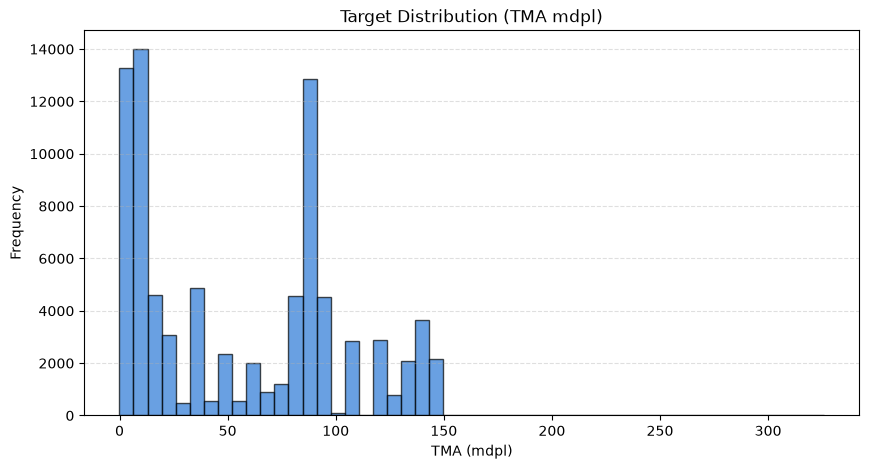

In [ ]:
# Cell 3 Target Distribution & Anomalies
logger.info("Overall stats:")
print(train_raw["tma_mdpl"].describe())
print(f"Skewness: {train_raw['tma_mdpl'].skew():.3f} | Kurtosis: {train_raw['tma_mdpl'].kurtosis():.3f}")

stats_per_pos = train_raw.groupby("nama_pos")["tma_mdpl"].agg(
    ["count", "mean", "std", "min", "max", "skew"]
).sort_values("mean", ascending=False)
print("\nPer-station stats:")
print(stats_per_pos)

n_invalid = (train_raw["tma_mdpl"] <= 0).sum()
logger.info(f"Invalid readings (tma_mdpl <= 0): {n_invalid}")

# Investigate and remove 
outlier_mask = (train_raw["nama_pos"] == "Floodway Bridge C") & (train_raw["datetime"] == "2025-06-15 18:00:00")
logger.info(f"Removing Floodway Bridge C spike: {outlier_mask.sum()} rows")
train_raw = train_raw[~outlier_mask].reset_index(drop=True)

# Visualize target distribution
plt.figure(figsize=(10, 5))
plt.hist(train_raw['tma_mdpl'].dropna(), bins=50, color='#2a78d6', edgecolor='black', alpha=0.7)
plt.title('Target Distribution (TMA mdpl)')
plt.xlabel('TMA (mdpl)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

### Cell 04: Environmental Data Sentinel Cleaning & Train-Test Distribution Drift

* **Tujuan Utama:** Membersihkan sentinel value (-999 < NaN), memeriksa missingness
  `soil_moisture_0_7cm`, dan mengevaluasi distribution drift (KS-test) train vs test
  untuk 20 fitur lingkungan (split: `TRAIN_TEST_CUTOFF` = 2025-09-19).
* **Temuan utama:** `nino_34` menunjukkan drift tertinggi (ks_stat=0.497, p≈0) dengan
  **pembalikan tanda rata-rata** (train=+0.363 -> test=-0.365), mengindikasikan fase
  ENSO bergeser dari kecenderungan El Niño (train) ke La Niña (test). Temuan ini
  konsisten dengan 3 fitur top-drift lain: seluruh lapisan soil moisture (0-7cm,
  7-28cm, 28-100cm; ks 0.22-0.30) dan dew_point_c (ks=0.219) sama-sama menunjukkan
  test period lebih basah/lembap bukan sebuah drift acak, tapi pergeseran iklim
  yang koheren secara fisik.
* **Missingness:** `soil_moisture_0_7cm` hilang di 1 tanggal (2026-05-18, masuk
  periode test) belum diverifikasi penanganannya pada tahap fitur engineering.
* **Implikasi lanjutan:** `wet_threshold` dikalibrasi
  dari distribusi soil moisture **train**. Jika test secara sistematis lebih basah,
  proporsi baris "wet regime" di test kemungkinan menyimpang signifikan dari asumsi
  training dan berpotensi mempengaruhi validitas evaluasi per-regime.

2026-07-25 17:35:09,781 | INFO     | Soil moisture missing unique dates: [datetime.date(2026, 5, 18)]
Feature drift between train and test (Top 5):
                   feature   ks_stat  ks_pval  mean_train  mean_test
19                 nino_34  0.496832      0.0    0.363115  -0.365446
9     soil_moisture_7_28cm  0.299234      0.0    0.345328   0.405329
8      soil_moisture_0_7cm  0.268654      0.0    0.347111   0.402006
10  soil_moisture_28_100cm  0.222253      0.0    0.344278   0.384556
4              dew_point_c  0.218894      0.0   22.285357  23.089767


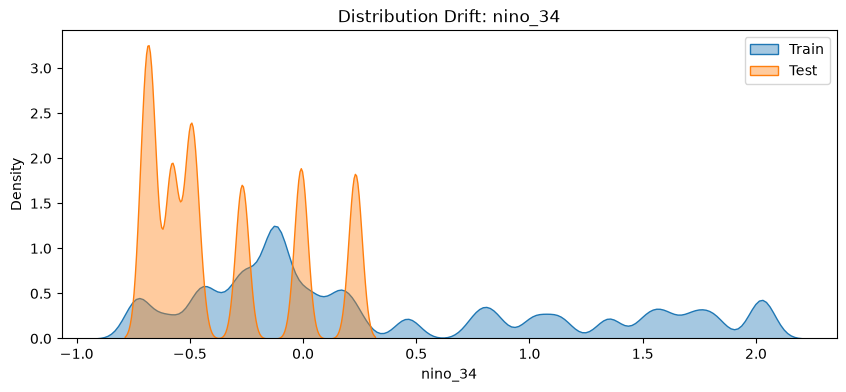

In [ ]:
# Cell 4 Environmental Data Drift & Missingness
env_clean_eda = env_raw.replace(-999, np.nan)

missing_soil = env_clean_eda[env_clean_eda["soil_moisture_0_7cm"].isnull()]
logger.info(f"Soil moisture missing unique dates: {missing_soil['datetime_parsed'].dt.date.unique()}")

env_train = env_clean_eda[env_clean_eda["datetime_parsed"] < TRAIN_TEST_CUTOFF].copy()
env_test = env_clean_eda[env_clean_eda["datetime_parsed"] >= TRAIN_TEST_CUTOFF].copy()

drift_cols = [
    "rainfall_mm", "rainfall_max_24h_mm", "humidity_pct", "wind_direction_deg",
    "dew_point_c", "cloud_cover_pct", "temperature_c", "wind_speed_kmh",
    "soil_moisture_0_7cm", "soil_moisture_7_28cm", "soil_moisture_28_100cm",
    "soil_moisture_100_255cm", "surface_pressure_hpa", "pressure_msl_hpa",
    "rmm1", "rmm2", "mjo_phase", "mjo_amplitude", "mjo_active", "nino_34",
]

drift_results = []
for col in drift_cols:
    tr, te = env_train[col].dropna(), env_test[col].dropna()
    if tr.empty or te.empty:
        continue
    ks_stat, ks_pval = ks_2samp(tr, te)
    drift_results.append({
        "feature": col, "ks_stat": ks_stat, "ks_pval": ks_pval,
        "mean_train": tr.mean(), "mean_test": te.mean()
    })

drift_df = pd.DataFrame(drift_results).sort_values("ks_stat", ascending=False)
print("Feature drift between train and test (Top 5):")
print(drift_df.head(5))

# Visualize drift for top feature
top_drift_feat = drift_df.iloc[0]["feature"]
plt.figure(figsize=(10, 4))
sns.kdeplot(env_train[top_drift_feat].dropna(), label='Train', fill=True, alpha=0.4)
sns.kdeplot(env_test[top_drift_feat].dropna(), label='Test', fill=True, alpha=0.4)
plt.title(f'Distribution Drift: {top_drift_feat}')
plt.legend()
plt.show()

### Cell 05: Autocorrelation & Seasonal Dynamics Identification

* **Tujuan Utama:** Mengidentifikasi struktur autokorelasi temporal TMA (lag1-lag3,
  setara sekitar 6, 12, dan 18 jam pada grid observasi 6 jam-an) dan pola dinamika
  musiman.
* **Temuan utama:** Heterogenitas autokorelasi ekstrem antar-stasiun (lag1 berkisar
  0.0085 sampai 0.998), mengindikasikan dua Karakteristik fisik berbeda: stasiun "flashy"
  yang nyaris tanpa persistensi (contoh: Kali Pepe - PTPN), vs stasiun ber-regulasi
  bendungan dengan persistensi nyaris sempurna (contoh: Wonogiri Dam). Temuan ini
  memberi dasar kuantitatif untuk kategori `FLASHY_STATIONS` dan
  `NONSTATIONARY_STATIONS` yang dipakai di tahap error analysis.
* **Pola musiman:** Puncak TMA ternormalisasi di Februari (+1.06), palung di
  Oktober (-1.09), konsisten dengan pola muson Indonesia (musim hujan November-April,
  musim kemarau Mei-Oktober).
* **Keterbatasan:** Lag dihitung berdasarkan urutan baris, bukan berdasarkan jarak
  waktu aktual, sehingga tidak gap-aware terhadap missing timestamp (dapat di lihat pada Cell 02).
* **Catatan implementasi:** Variabel `merged_eda` disiapkan di awal cell namun tidak
  digunakan pada analisis autokorelasi maupun pola musiman.
* **Alasan Metodologis:** Mengidentifikasi pola musiman secara eksplisit memungkinkan
  evaluasi tersegmentasi per karakteristik (wet vs dry), sehingga performa model dapat
  dievaluasi secara spesifik pada periode berisiko banjir tinggi, tanpa terdistorsi
  oleh periode kemarau.

2026-07-25 17:35:24,583 | INFO     | Autocorrelation (lag 1-3) per station:
                               lag1      lag2      lag3
Kali Pepe - PTPN           0.008505  0.005684  0.003672
Jarum                      0.023517  0.080493  0.017051
Kali Anyar - Kreteg Abang  0.036410  0.035667  0.035461
Peren                      0.046968  0.041344  0.038105
Karangnongko               0.077873  0.072757  0.069968
Napel                      0.093894  0.089157  0.087480
Bojonegoro - Kali Kethek   0.132707  0.128668  0.122979
Kajangan                   0.224736  0.212641  0.197630
Kedungupit                 0.232626  0.222072  0.205455
Jurug                      0.381485  0.348466  0.345177
Kali Pepe - Tugu Boto      0.610803  0.537642  0.541890
Arjowinangun - Pacitan     0.624031  0.576953  0.797440
Ngrembang                  0.723294  0.632978  0.614603
Ngadipiro                  0.804071  0.739232  0.720664
Lorog                      0.813428  0.769273  0.757251
Ketonggo                   0

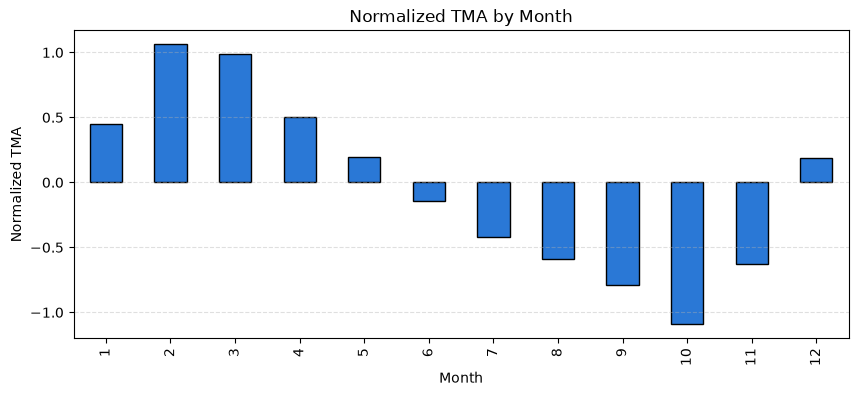

In [ ]:
# Cell 5 Autocorrelation & Seasonal Patterns
# Prepare merged df for EDA lag analysis
df = train_raw.copy()
env_eda = env_raw.copy().replace(-999, np.nan)
env_matched_eda = env_eda[env_eda["datetime_parsed"].dt.hour.isin(TARGET_HOURS)].copy()
merged_eda = df.merge(env_matched_eda, on=["datetime", "nama_pos"], how="inner", suffixes=("", "_env"))

# Autocorrelation and observation spacing
ac_df = pd.DataFrame({
    pos: {
        "lag1": (sub := df[df["nama_pos"] == pos].sort_values("datetime_parsed"))["tma_mdpl"].autocorr(1),
        "lag2": sub["tma_mdpl"].autocorr(2),
        "lag3": sub["tma_mdpl"].autocorr(3),
    }
    for pos in df["nama_pos"].unique()
}).T.sort_values("lag1")

logger.info("Autocorrelation (lag 1-3) per station:")
print(ac_df)

# Seasonal and yearly patterns
df["month"] = df["datetime_parsed"].dt.month
df["year"] = df["datetime_parsed"].dt.year
df["tma_normalized"] = df.groupby("nama_pos")["tma_mdpl"].transform(lambda x: x - x.mean())

logger.info("Normalized TMA by month:")
print(df.groupby("month")["tma_normalized"].mean())

# Visualize seasonal pattern
plt.figure(figsize=(10, 4))
df.groupby("month")["tma_normalized"].mean().plot(kind='bar', color='#2a78d6', edgecolor='black')
plt.title('Normalized TMA by Month')
plt.xlabel('Month')
plt.ylabel('Normalized TMA')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# 3. Hydrography, Routing Graph & Spatial Aggregation

Bagian ini membangun grafik topologi aliran sungai Bengawan Solo, menghitung waktu tempuh air (*travel-time routing*), dan melakukan agregasi spasial curah hujan berbasis luas tangkapan air (*catchment area*).


### Cell 06: HydroRIVERS Station-to-River Snapping

* **Tujuan Utama:** Mencocokkan koordinat 30 stasiun pemantauan ke segmen
  sungai terdekat dari basis data HydroRIVERS v10, menggunakan spatial index STRtree
  untuk pencarian nearest-neighbor yang efisien pada 836.472 segmen sungai.
* **Input Data:** Shapefile `HydroRIVERS_v10_au.shp` dan koordinat stasiun (`coords_raw`).
* **Proses:**
  1. Filter segmen sungai menjadi hanya "sungai besar" (108.111 dari 836.472 segmen,
     87% dibuang) dengan kriteria OR: `DIS_AV_CMS > 50`, `ORD_STRA >= 4`, atau
     `UPLAND_SKM > 500`. Tujuannya mencegah stasiun ter-snap ke anak sungai/parit kecil.
  2. Snapping tiap stasiun ke segmen terdekat via `STRtree.nearest()`, lalu koreksi
     jarak menggunakan formula haversine (`dist_to_river_km_approx`) agar akurat
     secara fisik, karena jarak Euclidean dalam derajat (`dist_to_river_deg`) tidak
     merepresentasikan jarak riil akibat perbedaan skala lintang-bujur.
* **Output:** `river_pos_corrected.csv` (30 baris) berisi atribut sungai per stasiun:
  `river_id`, `next_down` (untuk membangun graph di Cell 07), `dis_av_cms`,
  `upland_skm`, `ord_stra`/`ord_flow`, `dist_dn_km`, `length_km`, dan jarak stasiun
  ke sungai (derajat & km).
* **Keterbatasan & Risiko:**
  - Kriteria threshold filter sungai (50 cms, order 4, 500 km²) belum didokumentasikan
    justifikasinya, berpotensi terlihat arbitrer.
  - Tidak ada validasi jarak snapping maksimum, jika ada stasiun dengan koordinat
    salah input, ia tetap akan ter-snap tanpa peringatan meski jaraknya secara fisik
    tidak masuk akal.
  - `tree.nearest()` mengembalikan index integer langsung, perilaku ini spesifik
    Shapely 2.0+; pada versi Shapely 1.x (backend pygeos) API ini mengembalikan
    geometry, bukan index, sehingga kode ini bergantung pada versi Shapely yang
    terpasang dan tidak backward-compatible.
  - Kolom `dist_to_river_deg` disimpan di output namun tidak jelas apakah dipakai
    di tahap selanjutnya.
* **Downstream Impact:** Output cell ini (`river_id`, `next_down`) menjadi input
  langsung untuk membangun graph topologi sungai di Cell 07.

In [ ]:
# Cell 6 HydroRIVERS River POS Corrected 
# Load HydroRIVERS shapefile
rivers_gdf = gpd.read_file(
    BASE_PATH / "data_pendukung/HydroRIVERS_v10_au_shp/HydroRIVERS_v10_au.shp"
)
logger.info(f"Total river segments: {len(rivers_gdf)}")

coords = coords_raw.copy()
coords["nama_pos"] = coords["nama_pos"].str.strip()

# Filter sungai besar saja
rivers_filtered = rivers_gdf[
    (rivers_gdf["DIS_AV_CMS"] > 50) |
    (rivers_gdf["ORD_STRA"] >= 4) |
    (rivers_gdf["UPLAND_SKM"] > 500)
].copy().reset_index(drop=True)

logger.info(f"Filtered rivers (DIS>50 or ORD>=4 or UPLAND>500): {len(rivers_filtered)}")
has_ord_flow = "ORD_FLOW" in rivers_filtered.columns

# Build STRtree dari geometri rivers_filtered
tree = STRtree(rivers_filtered.geometry.values)
results = []

for _, station in coords.iterrows():
    point = Point(station["longitude"], station["latitude"])
    # STRtree.nearest()
    nearest_pos = tree.nearest(point)
    nearest = rivers_filtered.iloc[nearest_pos]

    # Haversine untuk konversi jarak yang akurat
    lat1 = math.radians(station["latitude"])
    lon1 = math.radians(station["longitude"])
    nearest_point = nearest.geometry.interpolate(nearest.geometry.project(point))
    lat2 = math.radians(nearest_point.y)
    lon2 = math.radians(nearest_point.x)

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    dist_km = 6371.0 * 2 * math.asin(math.sqrt(a))
    dist_deg = point.distance(nearest.geometry)

    results.append({
        "nama_pos": station["nama_pos"],
        "latitude": station["latitude"],
        "longitude": station["longitude"],
        "river_id": int(nearest["HYRIV_ID"]),
        "next_down": int(nearest["NEXT_DOWN"]),
        "dis_av_cms": float(nearest["DIS_AV_CMS"]),
        "upland_skm": float(nearest["UPLAND_SKM"]),
        "ord_stra": int(nearest["ORD_STRA"]),
        "ord_flow": int(nearest["ORD_FLOW"]) if has_ord_flow else -1,
        "dist_dn_km": float(nearest["DIST_DN_KM"]),
        "length_km": float(nearest["LENGTH_KM"]),
        "dist_to_river_deg": float(dist_deg),
        "dist_to_river_km_approx": float(dist_km),
    })

river_pos_new = pd.DataFrame(results)
river_pos_new.to_csv(WORKING_PATH / "river_pos_corrected.csv", index=False)
logger.info(f"Saved: river_pos_corrected.csv ({len(river_pos_new)} stations)")

2026-07-25 17:36:09,527 | INFO     | Total river segments: 836472
2026-07-25 17:36:09,624 | INFO     | Filtered rivers (DIS>50 or ORD>=4 or UPLAND>500): 108111
2026-07-25 17:36:10,050 | INFO     | Saved: river_pos_corrected.csv (30 stations)


### Cell 07: Physical Travel-Time Correction & Upstream Catchment Graph

* **Tujuan Utama:** Terdiri dari dua komponen: 
- (1) koreksi lag empiris menjadi lag
  berbasis jarak fisik untuk pasangan stasiun hulu-hilir dengan hubungan hidrologis
  yang jelas (`routing_map`, 4 pasangan stasiun), menggunakan kecepatan aliran
  nominal sebagai basis perhitungan.
- (2) membangun graf topologi sungai
  (NetworkX DiGraph, dari atribut `NEXT_DOWN` bawaan HydroRIVERS) untuk menghitung
  upstream catchment bagi seluruh 30 stasiun pemantauan.
* **Input Data:** `river_pos_corrected.csv` (dari Cell 06) dan `rivers_filtered`
  (subset sungai besar dari Cell 06).
* **Metode:**
  - Travel-time fisik dihitung dari selisih jarak-ke-outlet (`dist_dn_km`) antar
    stasiun hulu-hilir, dikonversi ke lag dalam satuan step 6-jam menggunakan
    kecepatan aliran nominal (`FLOW_SPEED_KPH`).
  - Upstream catchment dihitung dengan `nx.ancestors()` pada graph topologi sungai,
    mengumpulkan seluruh segmen sungai di hulu tiap stasiun beserta luas catchment
    kumulatifnya (`UPLAND_SKM`).
* **Output:**
  - `G`: graph topologi sungai (107.873 node, 105.786 edge).
  - `physical_routing`: lag fisik terkoreksi untuk 4 pasangan stasiun hulu-hilir
    yang ditentukan (`Jurug`, `Babat`, `Sumberrejo`, `Karanggeneng`).
  - `catchment_upstream`: daftar segmen upstream dan luas catchment kumulatif untuk
    seluruh 30 stasiun.
* **Downstream Impact:** `catchment_upstream` menjadi input agregasi curah hujan
  per catchment di Cell 08. `physical_routing` dipakai untuk fitur upstream-lag
  pada 4 stasiun dengan hubungan hulu-hilir yang teridentifikasi secara eksplisit.

In [ ]:
# Cell 7 Physical Travel-Time & Catchment Graph
river_pos = pd.read_csv(WORKING_PATH / "river_pos_corrected.csv")

FLOW_SPEED_KPH      = 4.0   # moderate flow
FLOW_SPEED_KPH_FAST = 6.0   # flood conditions

routing_map = {
    "Jurug":        [("Serenan", 2)],
    "Babat":        [("Cepu", 2), ("Jurug", 4)],
    "Sumberrejo":   [("Cepu", 2)],
    "Karanggeneng": [("Cepu", 3)],
}

dist_lookup = river_pos.set_index("nama_pos")["dist_dn_km"].to_dict()
physical_routing = {}
skipped_pairs    = set()

for downstream, upstream_list in routing_map.items():
    dist_down = dist_lookup.get(downstream)
    if dist_down is None:
        physical_routing[downstream] = upstream_list
        skipped_pairs.update([(u, downstream) for u, _ in upstream_list])
        continue

    physical_routing[downstream] = []
    for upstream, old_lag in upstream_list:
        dist_up = dist_lookup.get(upstream)
        if dist_up is None:
            physical_routing[downstream].append((upstream, old_lag))
            skipped_pairs.add((upstream, downstream))
            continue

        travel_dist_km = dist_up - dist_down
        if travel_dist_km <= 0:
            physical_routing[downstream].append((upstream, old_lag))
            skipped_pairs.add((upstream, downstream))
            continue

        travel_hours      = travel_dist_km / FLOW_SPEED_KPH
        travel_hours_fast = travel_dist_km / FLOW_SPEED_KPH_FAST
        physical_lag      = max(1, math.ceil(travel_hours / 6))
        physical_lag_fast = max(1, math.ceil(travel_hours_fast / 6))
        physical_routing[downstream].append((upstream, physical_lag))

# Build Catchment Graph
valid_edges = rivers_filtered[
    (rivers_filtered["NEXT_DOWN"] > 0) &
    (rivers_filtered["NEXT_DOWN"] != rivers_filtered["HYRIV_ID"])
][["HYRIV_ID", "NEXT_DOWN"]]

G = nx.DiGraph()
G.add_edges_from(
    zip(valid_edges["HYRIV_ID"].astype(int), valid_edges["NEXT_DOWN"].astype(int))
)
logger.info(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

upland_lookup = rivers_filtered.set_index("HYRIV_ID")["UPLAND_SKM"].to_dict()
catchment_upstream = {}

for _, station in river_pos.iterrows():
    river_id     = int(station["river_id"])
    station_name = station["nama_pos"]

    if river_id in G:
        upstream_ids = nx.ancestors(G, river_id)
        upstream_ids.add(river_id)
        catchment_area_km2 = upland_lookup.get(river_id, station["upland_skm"])
    else:
        upstream_ids       = {river_id}
        catchment_area_km2 = station["upland_skm"]

    catchment_upstream[station_name] = {
        "river_ids":          list(upstream_ids),
        "n_upstream_segments": len(upstream_ids),
        "catchment_area_km2": catchment_area_km2,
    }

2026-07-25 17:36:12,169 | INFO     | Graph: 107873 nodes, 105786 edges


### Cell 08: Catchment-Weighted Rainfall Aggregation

* **Tujuan Utama:** Menghitung curah hujan gabungan per stasiun dengan pembobotan
  berdasarkan luas catchment, mengagregasikan kontribusi curah hujan dari stasiun
  itu sendiri beserta seluruh stasiun di hulunya (bukan hulu saja, kontribusi
  stasiun sendiri turut disertakan dalam bobot).
* **Input Data:** Graf topologi `G` dan `river_pos` (dari Cell 06-07), serta data
  curah hujan mentah (`env_eda`) yang di-pivot ke format wide per stasiun pada
  grid 6-jam-an.
* **Metode:**
  - Untuk tiap stasiun, ditelusuri seluruh stasiun hulu (`nx.ancestors`), lalu
    dihitung bobot tiap stasiun (hulu + diri sendiri) berdasarkan `UPLAND_SKM`
    masing-masing, dinormalisasi agar berjumlah 1.
  - Fallback saat pembentukan bobot: jika total luas catchment 0, bobot dibagi
    rata antar seluruh stasiun terkait.
  - Curah hujan tiap stasiun dipivot ke format wide (`rainfall_pivot`), nilai
    kosong diisi 0.
  - Curah hujan gabungan dihitung sebagai rata-rata terboboti dari `rainfall_pivot`
    menggunakan bobot yang sudah dinormalisasi; bobot dinormalisasi ulang khusus
    dari stasiun-stasiun yang datanya tersedia di `rainfall_pivot`.
  - Fallback saat agregasi: jika tidak ada stasiun berbobot yang tersedia datanya,
    dipakai curah hujan stasiun itu sendiri secara langsung (tanpa pembobotan).
* **Output:** `catchment_rainfall.csv`, shape (3702, 30) sehingga deret waktu curah hujan
  terboboti-catchment per stasiun.
* **Downstream Impact:** Digabungkan ke `df_full` pada tahap feature engineering.

In [ ]:
# Cell 8 Catchment-Integrated Rainfall
river_to_station  = dict(zip(river_pos["river_id"].astype(int), river_pos["nama_pos"]))
station_to_riverid = dict(zip(river_pos["nama_pos"], river_pos["river_id"].astype(int)))
catchment_stations = {}
catchment_info     = {}

for _, station in river_pos.iterrows():
    river_id     = int(station["river_id"])
    station_name = station["nama_pos"]

    upstream_river_ids = nx.ancestors(G, river_id) if river_id in G else set()
    upstream_river_ids.add(river_id)

    catchment_area_km2 = upland_lookup.get(river_id, station["upland_skm"])
    upstream_stations = list({
        river_to_station[rid]
        for rid in upstream_river_ids
        if rid in river_to_station and river_to_station[rid] != station_name
    })

    station_weights = {}
    for s in upstream_stations:
        s_rid = station_to_riverid.get(s)
        if s_rid is not None:
            station_weights[s] = upland_lookup.get(s_rid, 1.0)

    own_upland = upland_lookup.get(river_id, station["upland_skm"])
    station_weights[station_name] = own_upland

    total_w = sum(station_weights.values())
    if total_w > 0:
        station_weights = {k: v / total_w for k, v in station_weights.items()}
    else:
        all_s = upstream_stations + [station_name]
        station_weights = {s: 1.0 / len(all_s) for s in all_s}

    catchment_stations[station_name] = upstream_stations
    catchment_info[station_name] = {
        "upstream_river_ids":  upstream_river_ids,
        "upstream_stations":   upstream_stations,
        "n_upstream_segments": len(upstream_river_ids),
        "n_upstream_stations": len(upstream_stations),
        "catchment_area_km2":  catchment_area_km2,
        "station_weights":     station_weights,
    }

# Pivot Rainfall
env_6h = env_eda[env_eda["datetime_parsed"].dt.hour.isin(TARGET_HOURS)].copy()
rainfall_pivot = env_6h.pivot_table(
    index="datetime_parsed",
    columns="nama_pos",
    values="rainfall_mm",
    aggfunc="mean"
).fillna(0)

all_stations = river_pos["nama_pos"].tolist()
catchment_rainfall = pd.DataFrame(
    index=rainfall_pivot.index,
    columns=all_stations,
    dtype=float
)

for station_name in all_stations:
    info = catchment_info.get(station_name)
    if info is None:
        continue
    station_weights = info["station_weights"]
    available = {
        s: w for s, w in station_weights.items()
        if s in rainfall_pivot.columns
    }

    if len(available) == 0:
        if station_name in rainfall_pivot.columns:
            catchment_rainfall[station_name] = rainfall_pivot[station_name]
        continue

    total_w = sum(available.values())
    norm_weights = {s: w / total_w for s, w in available.items()}

    weighted = sum(
        rainfall_pivot[s] * w
        for s, w in norm_weights.items()
    )
    catchment_rainfall[station_name] = weighted

catchment_rainfall.to_csv(WORKING_PATH / "catchment_rainfall.csv")
logger.info(f"Saved: catchment_rainfall.csv ({catchment_rainfall.shape})")

2026-07-25 17:36:13,183 | INFO     | Saved: catchment_rainfall.csv ((3702, 30))


### Cell 09: Local Rainfall-TMA Lag Correlation & Contemporaneous Cross-Station TMA Correlation

* **Tujuan Utama:** Terdiri dari dua analisis terpisah: 
  - (1) mengukur korelasi lag antara variabel lingkungan lokal suatu stasiun (curah hujan, kelembapan tanah) dengan TMA stasiun itu sendiri, untuk mengidentifikasi lag respon empiris per stasiun. 
  - (2) mengukur korelasi kontemporer (tanpa lag) antar deret waktu TMA seluruh pasangan stasiun, untuk mengidentifikasi pasangan stasiun dengan pola pergerakan TMA paling mirip.
* **Input Data:** `merged_eda` (gabungan data lingkungan mentah dan TMA per
  stasiun, hasil merge di Cell 05) 
  - (1) `df` (TMA mentah, dipivot ke `tma_wide`) 
  - (2) Analisis ini menggunakan data lingkungan mentah per stasiun, bukan `catchment_rainfall` terboboti dari Cell 08.
* **Metode:**
  - Analisis (1): korelasi `feature.shift(lag)` terhadap `tma_mdpl` dihitung
    untuk 4 fitur lingkungan × lag 0-10 step (0-60 jam) × seluruh stasiun,
    lag dengan korelasi tertinggi dilaporkan khusus untuk `rainfall_max_24h_mm`.
  - Analisis (2): korelasi Pearson kontemporer (`tma_wide.corr()`, tanpa
    pergeseran waktu) dihitung antar seluruh pasangan stasiun, diranking
    berdasarkan nilai absolut, top-10 pasangan ditampilkan dan pasangan
    tertinggi divisualisasikan.
* **Output:** `lag_df`/`best_lag_per_pos` (lag optimum per stasiun untuk
  `rainfall_max_24h_mm`, berkisar 0-60 jam antar stasiun) dan `corr_pairs`
  (ranking korelasi kontemporer TMA antar seluruh pasangan stasiun, tertinggi:
  Jurug-Serenan 0.946).
* **Downstream Impact:** Lag optimum per stasiun dari analisis (1) berpotensi
  menjadi rujukan nilai `old_lag` yang dipakai sebagai fallback di `routing_map`
  Cell 07. Korelasi kontemporer dari analisis (2)
  bersifat eksploratif/observasional, tidak secara langsung menghasilkan fitur
  yang dipakai di tahap selanjutnya.

2026-07-25 17:36:15,366 | INFO     | Optimal rainfall_max_24h_mm lag by station:
                 nama_pos  lag_steps  lag_hours_nominal     corr
                  Badegan          0                  0 0.396612
                    Jarum          0                  0 0.089787
                    Lorog          0                  0 0.496776
    Kali Pepe - Tugu Boto          0                  0 0.379344
                    Jurug          1                  6 0.385942
                 Ketonggo          1                  6 0.541946
               Gunungsari          1                  6 0.483661
   Arjowinangun - Pacitan          1                  6 0.457621
                Ngadipiro          1                  6 0.560625
                    Peren          1                  6 0.124482
                  Serenan          1                  6 0.477795
                   Sekayu          1                  6 0.419824
Kali Anyar - Kreteg Abang          2                 12 0.007052
         

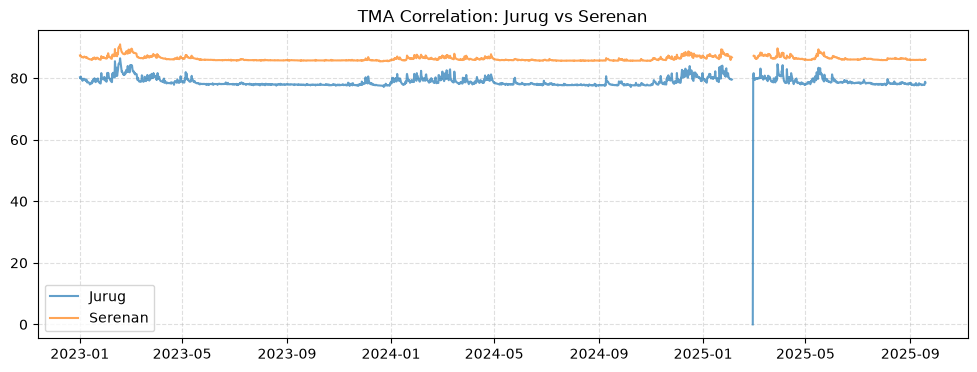

In [ ]:
# Cell 9 Cross-Station TMA Correlation & Upstream Lag
# Rainfall-to-TMA lag structure
lag_features = ["rainfall_mm", "rainfall_max_24h_mm", "soil_moisture_7_28cm", "soil_moisture_0_7cm"]
max_lag = 10

lag_results = [
    {
        "nama_pos": pos, "feature": feat, "lag_steps": lag, "lag_hours_nominal": lag * 6,
        "corr": sub[feat].shift(lag).corr(sub["tma_mdpl"]),
    }
    for pos in merged_eda["nama_pos"].unique()
    for sub in [merged_eda[merged_eda["nama_pos"] == pos].sort_values("datetime_parsed")]
    for feat in lag_features
    for lag in range(max_lag + 1)
]
lag_df = pd.DataFrame(lag_results)

logger.info("Optimal rainfall_max_24h_mm lag by station:")
rain_lag = lag_df[lag_df["feature"] == "rainfall_max_24h_mm"]
best_lag_per_pos = rain_lag.loc[rain_lag.groupby("nama_pos")["corr"].idxmax()][
    ["nama_pos", "lag_steps", "lag_hours_nominal", "corr"]
].sort_values("lag_hours_nominal")
print(best_lag_per_pos.to_string(index=False))

# Cross-station TMA correlation and upstream-downstream lag
tma_wide = df.pivot_table(index="datetime_parsed", columns="nama_pos", values="tma_mdpl")
tma_corr = tma_wide.corr()

corr_stack = tma_corr.where(np.triu(np.ones(tma_corr.shape), k=1).astype(bool)).stack()
corr_stack.index.names = ["pos_a", "pos_b"]
corr_pairs = corr_stack.reset_index(name="corr")
corr_pairs = corr_pairs.reindex(corr_pairs["corr"].abs().sort_values(ascending=False).index)

logger.info("Top 10 station pairs by contemporaneous TMA correlation:")
print(corr_pairs.head(10).to_string(index=False))

# Visualize top correlation pair
top_pair = corr_pairs.head(1)
if not top_pair.empty:
    pos_a, pos_b = top_pair.iloc[0]["pos_a"], top_pair.iloc[0]["pos_b"]
    plt.figure(figsize=(12, 4))
    plt.plot(tma_wide.index, tma_wide[pos_a], label=pos_a, alpha=0.7)
    plt.plot(tma_wide.index, tma_wide[pos_b], label=pos_b, alpha=0.7)
    plt.title(f'TMA Correlation: {pos_a} vs {pos_b}')
    plt.legend()
    plt.grid(linestyle='--', alpha=0.4)
    plt.show()

# 4. Pipeline Configuration & Schema Contract

Bagian ini mendefinisikan parameter konfigurasi global eksperimen EXP048 serta menetapkan kontrak skema data untuk menjamin konsistensi struktur variabel di seluruh tahap pemrosesan.

### Cell 10: Global Configuration & Experiment Parameters

* **Tujuan Utama:** Mendefinisikan seluruh parameter konfigurasi eksperimen EXP048
  dalam satu sumber kebenaran terpusat (`CONFIG`), meliputi skema cross-validation,
  daftar stasiun bermasalah, parameter model, dan flag aktivasi fitur.
* **Komponen Utama:**
  - **Skema CV 2-fold** dengan periode train/gap/validation eksplisit per fold,
    termasuk `SYSTEM_GAP` (2025-02-04 s.d. 2025-03-01) yang berada di dalam rentang
    validasi Fold 1 maupun Fold 2.
  - **Daftar stasiun berkategori khusus:** `FLASHY_STATIONS` (5 stasiun autokorelasi
    rendah, konsisten dengan temuan Cell 05), `NONSTATIONARY_STATIONS` (Wonogiri Dam),
    `GUARDRAIL_STATIONS` (10 stasiun dengan batas atas prediksi eksplisit, termasuk
    Floodway Bridge C = 10.0), dan `DROP_STATIONS` (Gunungsari, konsisten dengan
    row count-nya yang jauh lebih sedikit di Cell 05, ~1126 vs ~2900 stasiun lain).
  - **`UPSTREAM_ROUTING_MAP`**: lag hulu-hilir hardcoded untuk 4 pasangan stasiun
    (dipakai langsung di feature engineering).
  - **Parameter model** untuk XGBoost, Ridge, Huber, KNN, serta daftar fitur khusus
    KNN dan grid bobot untuk Wonogiri.
  - **Threshold operasional**: `WET_REGIME_PERCENTILE=66` (dipakai di Cell 21),
    `NNLS_WEIGHT_STD_THRESHOLD`/`NNLS_RAW_SUM_CV_THRESHOLD` (dipakai di Cell 27),
    `CORRELATION_DROP_THRESHOLD=0.9` (dipakai di Cell 23).
  - **Flag aktivasi fitur** (`INCLUDE_*`) untuk switch on/off komponen feature
    engineering tanpa mengubah kode.
* **Output:** Dictionary `CONFIG` beserta `CONFIG_HASH` (MD5 dari seluruh isi
  config, untuk versioning/reproducibility eksperimen), divalidasi dengan assert
  urutan tanggal fold dan batas guardrail delta.
* **Downstream Impact:** `CONFIG` menjadi rujukan parameter di hampir seluruh
  cell setelahnya (feature engineering, CV loop, model training, gate produksi).
* **Catatan:** Nilai `UPSTREAM_ROUTING_MAP` berbeda dari hasil perhitungan dinamis
  `physical_routing` di Cell 07, meski keduanya diklaim menggunakan metode yang sama
  (jarak fisik / kecepatan aliran nominal). `physical_routing` sendiri tidak
  digunakan di tempat lain dalam notebook — perlu diklarifikasi sumber kebenaran
  mana yang seharusnya dipakai.

In [ ]:
# Cell 10 Global Configuration EXP048
CONFIG = {}

CONFIG["FOLD1_TRAIN_END"]  = pd.Timestamp("2024-08-31 18:00:00")
CONFIG["FOLD1_GAP_START"]  = pd.Timestamp("2024-09-01 06:00:00")
CONFIG["FOLD1_GAP_END"]    = pd.Timestamp("2024-09-30 18:00:00")
CONFIG["FOLD1_VAL_START"]  = pd.Timestamp("2024-10-01 06:00:00")
CONFIG["FOLD1_VAL_END"]    = pd.Timestamp("2025-05-31 18:00:00")

CONFIG["FOLD2_TRAIN_END"]  = pd.Timestamp("2024-12-31 18:00:00")
CONFIG["FOLD2_GAP_START"]  = pd.Timestamp("2025-01-01 06:00:00")
CONFIG["FOLD2_GAP_END"]    = pd.Timestamp("2025-01-31 18:00:00")
CONFIG["FOLD2_VAL_START"]  = pd.Timestamp("2025-02-01 06:00:00")
CONFIG["FOLD2_VAL_END"]    = pd.Timestamp("2025-09-18 18:00:00")

CONFIG["SYSTEM_GAP_START"] = pd.Timestamp("2025-02-04")
CONFIG["SYSTEM_GAP_END"]   = pd.Timestamp("2025-03-01")

CONFIG["FINAL_TRAIN_CUTOFF"] = pd.Timestamp("2025-09-18 18:00:00")
CONFIG["TEST_START"]         = pd.Timestamp("2025-09-19 06:00:00")

CONFIG["TARGET_HOURS"] = [6, 12, 18]

CONFIG["FLASHY_STATIONS"] = [
    "Kali Anyar - Kreteg Abang",
    "Peren",
    "Jarum",
    "Kedungupit",
    "Bojonegoro - Kali Kethek",
]

CONFIG["GUARDRAIL_STATIONS"] = {
    "Bojonegoro - Kali Kethek": 20.0,
    "Floodway Bridge C": 10.0,
    "Jarum": 100.0,
    "Kajangan": 60.0,
    "Kali Anyar - Kreteg Abang": 92.0,
    "Kali Pepe - PTPN": 90.0,
    "Karangnongko": 35.0,
    "Kedungupit": 75.0,
    "Napel": 45.0,
    "Peren": 99.0,
}

CONFIG["DROP_STATIONS"] = ["Gunungsari"]

CONFIG["NONSTATIONARY_STATIONS"] = ["Wonogiri Dam"]

# Lags dari dist_dn_km / flow_speed (4 km/h)
CONFIG["UPSTREAM_ROUTING_MAP"] = {
    "Jurug":        [("Serenan", 1)],
    "Babat":        [("Cepu", 5), ("Jurug", 11)],
    "Sumberrejo":   [("Cepu", 4)],
    "Karanggeneng": [("Cepu", 7)],
}

CONFIG["GUARDRAIL_LOWER_OFFSET"]   = 0.5
CONFIG["GUARDRAIL_DELTA_MIN"]      = 0.5
CONFIG["GUARDRAIL_DELTA_MAX"]      = 2.0
CONFIG["GUARDRAIL_DELTA_FRACTION"] = 0.2

CONFIG["WET_REGIME_PERCENTILE"] = 66

CONFIG["SIGN_TEST_MIN_STATIONS"]      = 20
CONFIG["MODEL_ABLATION_SEEDS"]        = 2
CONFIG["NNLS_BOOTSTRAP_N"]            = 20
CONFIG["NNLS_WEIGHT_STD_THRESHOLD"]   = 0.15
CONFIG["NNLS_RAW_SUM_CV_THRESHOLD"]   = 0.30
CONFIG["CORRELATION_DROP_THRESHOLD"]  = 0.9

CONFIG["VIRTUAL_CUTOFF_NEAR_SPACING_DAYS"] = 15
CONFIG["VIRTUAL_CUTOFF_FAR_SPACING_DAYS"]  = 30
CONFIG["MAX_HORIZON_DAYS"] = 245

CONFIG["XGB_PARAMS"] = {
    "max_depth":             6,
    "learning_rate":         0.05,
    "n_estimators":          2000,
    "early_stopping_rounds": 30,
    "tree_method":           "hist",
    "reg_alpha":             1.0,
    "reg_lambda":            1.5,
    "enable_categorical":    True,
    "random_state":          SEED,
}

CONFIG["RIDGE_PARAMS"] = {
    "alpha":         1.0,
    "fit_intercept": True,
}

CONFIG["HUBER_PARAMS"] = {
    "epsilon": 1.35,
    "max_iter": 500,
    "alpha": 0.0001,
}

CONFIG["KNN_PARAMS"] = {
    "n_neighbors": 50,
    "weights":     "distance",
    "algorithm":   "ball_tree",
}

CONFIG["KNN_TOP_FEATURES"] = [
    "soil_moisture_0_7cm",
    "soil_moisture_7_28cm",
    "tma_mean_pos",
    "rainfall_max_24h_mm",
    "rolling_rain_48h",
    "rolling_rain_72h",
    "humidity_pct",
    "temperature_c",
    "nino_34",
    "mjo_phase_sin",
    "mjo_phase_cos",
    "bulan",
    "hour",
]

CONFIG["WONOGIRI_WEIGHT_GRID"] = [
    [1, 1, 1],
    [1, 2, 3],
    [1, 3, 5],
    [1, 1, 2],
    [2, 3, 3],
]

CONFIG["INCLUDE_TMA_ANCHOR_DECAY"]      = True
CONFIG["INCLUDE_WIND_CYCLIC"]           = True
CONFIG["INCLUDE_DAYS_SINCE_RAIN"]       = True
CONFIG["INCLUDE_ROLLING_RAIN_24H_MAX"]  = True
CONFIG["INCLUDE_SOIL_MOISTURE_CHANGE"]  = True
CONFIG["INCLUDE_MJO_CYCLIC"]            = True
CONFIG["INCLUDE_CATCHMENT_RAINFALL"]    = True

CONFIG["EXP_ID"] = "exp048"

def make_config_hash(config_dict):
    config_serializable = {}
    for k, v in config_dict.items():
        if isinstance(v, pd.Timestamp):
            config_serializable[k] = str(v)
        elif isinstance(v, list):
            config_serializable[k] = [str(x) if isinstance(x, pd.Timestamp) else x for x in v]
        elif isinstance(v, dict):
            config_serializable[k] = {str(k2): (str(v2) if isinstance(v2, pd.Timestamp) else v2) for k2, v2 in v.items()}
        else:
            config_serializable[k] = v
    config_str = json.dumps(config_serializable, sort_keys=True, default=str)
    return hashlib.md5(config_str.encode()).hexdigest()

CONFIG["CONFIG_HASH"] = make_config_hash(CONFIG)

assert CONFIG["FOLD1_TRAIN_END"] < CONFIG["FOLD1_GAP_START"] < CONFIG["FOLD1_GAP_END"] < CONFIG["FOLD1_VAL_START"] < CONFIG["FOLD1_VAL_END"]
assert CONFIG["FOLD2_TRAIN_END"] < CONFIG["FOLD2_GAP_START"] < CONFIG["FOLD2_GAP_END"] < CONFIG["FOLD2_VAL_START"] < CONFIG["FOLD2_VAL_END"]
assert CONFIG["GUARDRAIL_DELTA_MIN"] < CONFIG["GUARDRAIL_DELTA_MAX"]

logger.info(f"EXP_ID: {CONFIG['EXP_ID']}")
logger.info("Cell 10 complete")

2026-07-25 17:36:15,986 | INFO     | EXP_ID: exp048
2026-07-25 17:36:15,991 | INFO     | Cell 10 complete


### Cell 11: Data Schema Contract & Structural Integrity Check

* **Tujuan Utama:** Memvalidasi skema, tipe data, dan kelengkapan kolom wajib pada
  5 sumber data mentah (`train_raw`, `test_raw`, `env_raw`, `coords_raw`,
  `sample_submission_raw`) sebelum tahap pemrosesan lebih lanjut, sekaligus
  memeriksa konsistensi rentang tanggal, jumlah stasiun, dan keberadaan sentinel
  value.
* **Input Data:** 5 DataFrame mentah hasil load awal (belum di-merge).
* **Pemeriksaan yang dilakukan:**
  - Kolom wajib vs kolom hilang/ekstra per DataFrame (kolom ekstra hanya warning,
    kolom hilang menyebabkan gagal).
  - Tipe data (numerik untuk `tma_mdpl`, datetime64 untuk seluruh kolom tanggal).
  - Rentang tanggal train (2023-01-01 s.d. 2025-09-18) dan test (2025-09-19 s.d.
    2026-05-18) terhadap batas akhir fold CV di `CONFIG`.
  - Jumlah stasiun unik (30, sesuai ekspektasi 29-30) dan keberadaan `Gunungsari`
    (dikonfirmasi ada, akan di-drop sesuai `CONFIG["DROP_STATIONS"]`).
  - Keberadaan sentinel value -999 di `env_raw` (ditemukan 100.080 nilai,
    mengonfirmasi logika replacement di Cell 04 memang diperlukan).
  - Kelengkapan jam target (6, 12, 18) pada data train.
* **Output:** Log validasi per pemeriksaan dan `schema_report.json` (disimpan ke
  `LOG_DIR`, berisi daftar kolom hilang/ekstra untuk audit trail).
* **Perilaku Gate:** Hard-stop `raise RuntimeError` jika `SCHEMA_OK=False`
  (berbeda dengan gate produksi pada Cell 35 yang soft-warning), karena kegagalan
  skema di titik ini akan merusak seluruh tahap pemrosesan berikutnya.

In [ ]:
# Cell 11 Schema Contract & Validation
SCHEMA_OK = True
schema_report = {}

dfs = {
    "train_raw":            train_raw,
    "test_raw":             test_raw,
    "env_raw":              env_raw,
    "coords_raw":           coords_raw,
    "sample_submission_raw": sample_submission_raw,
}

EXPECTED_COLS = {
    "train_raw": [
        "datetime", "nama_pos", "tma_mdpl", "datetime_parsed",
    ],
    "test_raw": [
        "id", "datetime_str", "nama_pos", "datetime_parsed",
    ],
    "env_raw": [
        "datetime", "nama_pos", "datetime_parsed",
        "rainfall_mm", "humidity_pct", "temperature_c",
        "soil_moisture_0_7cm", "soil_moisture_7_28cm",
        "wind_direction_deg",
        "nino_34", "rmm1", "rmm2", "mjo_phase",
    ],
    "coords_raw": [
        "nama_pos", "latitude", "longitude",
    ],
    "sample_submission_raw": [
        "id", "tma_mdpl",
    ],
}

for df_name, expected_cols in EXPECTED_COLS.items():
    df = dfs[df_name]
    missing = set(expected_cols) - set(df.columns)
    extra   = set(df.columns) - set(expected_cols)

    if missing:
        logger.error(f"{df_name}: MISSING columns {missing}")
        SCHEMA_OK = False
        schema_report[f"{df_name}_missing"] = list(missing)
    if extra:
        logger.warning(f"{df_name}: EXTRA columns {extra}")
        schema_report[f"{df_name}_extra"] = list(extra)

if SCHEMA_OK:
    assert pd.api.types.is_numeric_dtype(train_raw["tma_mdpl"]),          "tma_mdpl not numeric"
    assert pd.api.types.is_datetime64_any_dtype(train_raw["datetime_parsed"]), "train datetime not datetime64"
    assert pd.api.types.is_datetime64_any_dtype(test_raw["datetime_parsed"]),  "test datetime not datetime64"
    assert pd.api.types.is_datetime64_any_dtype(env_raw["datetime_parsed"]),   "env datetime not datetime64"

train_min = train_raw["datetime_parsed"].min()
train_max = train_raw["datetime_parsed"].max()
test_min  = test_raw["datetime_parsed"].min()
test_max  = test_raw["datetime_parsed"].max()

logger.info(f"Train date range: {train_min} -> {train_max}")
logger.info(f"Test date range:  {test_min} -> {test_max}")

if CONFIG["FOLD1_VAL_END"] > train_max:
    logger.error(f"FOLD1_VAL_END {CONFIG['FOLD1_VAL_END']} exceeds train_max {train_max}")
    SCHEMA_OK = False

if CONFIG["FOLD2_VAL_END"] > train_max:
    logger.error(f"FOLD2_VAL_END {CONFIG['FOLD2_VAL_END']} exceeds train_max {train_max}")
    SCHEMA_OK = False

n_stations = train_raw["nama_pos"].nunique()
logger.info(f"Unique stations in train: {n_stations}")
if n_stations not in [29, 30]:
    logger.warning(f"Expected 29-30 stations, got {n_stations}")

if "Gunungsari" in train_raw["nama_pos"].unique():
    logger.info("Gunungsari present — will be dropped per CONFIG")
else:
    logger.info("Gunungsari not present — DROP_STATIONS will no-op")

sentinel_count = (env_raw.select_dtypes(include=[np.number]) == -999).sum().sum()
if sentinel_count > 0:
    logger.info(f"Found {sentinel_count} sentinel (-999) values in env_raw")
else:
    logger.warning("No -999 sentinel found in env_raw — replacement logic will no-op")

hours_present = set(train_raw["datetime_parsed"].dt.hour.unique())
expected_hours = set(CONFIG["TARGET_HOURS"])
if not expected_hours.issubset(hours_present):
    logger.warning(f"Expected hours {expected_hours} not all present in train: {hours_present}")
else:
    logger.info(f"Target hours confirmed present: {expected_hours}")

schema_report_path = LOG_DIR / "schema_report.json"
with open(schema_report_path, "w") as f:
    json.dump(schema_report, f, indent=2, default=str)

if not SCHEMA_OK:
    raise RuntimeError("Schema validation failed. Check logs.")

logger.info("Schema validation PASSED")
logger.info("Cell 11 complete")

2026-07-25 17:36:16,056 | WARNING  | env_raw: EXTRA columns {'surface_pressure_hpa', 'rainfall_max_24h_mm', 'built_surface_m2', 'soil_moisture_28_100cm', 'landcover_class', 'wind_speed_kmh', 'solar_radiation_mj_m2', 'rainfall_openmeteo_mm', 'mjo_active', 'landcover_name', 'dew_point_c', 'soil_moisture_100_255cm', 'cloud_cover_pct', 'pressure_msl_hpa', 'mjo_amplitude'}
2026-07-25 17:36:16,064 | INFO     | Train date range: 2023-01-01 06:00:00 -> 2025-09-18 18:00:00
2026-07-25 17:36:16,067 | INFO     | Test date range:  2025-09-19 06:00:00 -> 2026-05-18 18:00:00
2026-07-25 17:36:16,076 | INFO     | Unique stations in train: 30
2026-07-25 17:36:16,084 | INFO     | Gunungsari present — will be dropped per CONFIG
2026-07-25 17:36:16,182 | INFO     | Found 100080 sentinel (-999) values in env_raw
2026-07-25 17:36:16,190 | INFO     | Target hours confirmed present: {18, 12, 6}
2026-07-25 17:36:16,195 | INFO     | Schema validation PASSED
2026-07-25 17:36:16,197 | INFO     | Cell 11 complete


# 5. Data Cleaning, Preprocessing & Virtual Schedule Construction

Bagian ini mencakup pembersihan nilai sentinel, koreksi eror sensor, konstruksi jadwal prediktif virtual (*multi-cutoff virtual schedule*), pencarian indeks anchor cepat, serta optimasi pencarian grid bobot Waduk Wonogiri.

### Cell 12: Sentinel Cleaning, Sensor Error Removal & Gap Tagging

* **Tujuan Utama:** Membersihkan data mentah dari sentinel value, spike sensor,
  bacaan TMA tidak valid, dan outlier fisik per stasiun, serta menandai baris yang
  jatuh dalam periode system outage.
* **Input Data:** `env_raw`, `train_raw` (catatan: `train_raw` pada titik ini
  sudah tidak mengandung spike Floodway Bridge C 2025-06-15 18:00, karena baris
  tersebut sudah dihapus lebih dulu di Cell 03 selama EDA, logika penghapusan di
  cell ini bersifat redundan/safety-net, bukan sumber utama penghapusannya).
* **Proses:**
  1. Sentinel -999 pada `env_raw` diganti NaN (100.080 nilai).
  2. Penghapusan baris TMA <= 0 (5 baris).
  3. Penghapusan baris di atas `CONFIG["GUARDRAIL_STATIONS"]` per stasiun (total
     17 baris, 9 dari 30 stasiun terdampak) perbedaan dengan penggunaan
     guardrail di tahap clipping prediksi (Cell 28/30) perlu diperhatikan: di
     sini guardrail berfungsi sebagai filter pembuangan baris training, bukan
     pembatas nilai prediksi.
  4. Penandaan `is_system_gap` (9 baris di 6 stasiun, periode 2025-02-04 s.d.
     2025-03-01) dan `is_flashy` (berdasarkan `CONFIG["FLASHY_STATIONS"]`).
* **Output:** `train_clean`, `env_clean`, `cleaning_report.json` (disimpan ke
  `LOG_DIR`, total 22 baris dihapus).
* **Validasi:** Assert tidak ada sentinel tersisa di `env_clean` dan tidak ada
  TMA <= 0 tersisa di `train_clean`; assert jumlah spike Floodway Bridge C yang
  terhapus tidak melebihi 1 (namun assert ini tidak dapat membedakan antara
  "sudah dibersihkan di Cell 03" vs "memang tidak ditemukan").

In [ ]:
# Cell 12 Cleaning: Sentinel, Sensor Errors, Gap Definition
cleaning_report = {}

numeric_cols = env_raw.select_dtypes(include=[np.number]).columns
env_clean = env_raw.copy()
before_sentinel = env_clean[numeric_cols].isna().sum().sum()
env_clean[numeric_cols] = env_clean[numeric_cols].replace(-999, np.nan)
after_sentinel = env_clean[numeric_cols].isna().sum().sum()

logger.info(f"Sentinel replacement: added {after_sentinel - before_sentinel} NaN")
cleaning_report["sentinel_replaced"] = int(after_sentinel - before_sentinel)

before_rows = len(train_raw)
spike_mask = (
    (train_raw["nama_pos"] == "Floodway Bridge C") &
    (train_raw["datetime"] == "2025-06-15 18:00:00")
)
train_clean = train_raw[~spike_mask].reset_index(drop=True)
removed_spike = before_rows - len(train_clean)

assert removed_spike <= 1, f"More than 1 Floodway Bridge C spike row found: {removed_spike}"
residual_spike = (
    (train_clean["nama_pos"] == "Floodway Bridge C") &
    (train_clean["datetime"] == "2025-06-15 18:00:00")
).sum()
assert residual_spike == 0, "Floodway Bridge C spike still present after removal"

logger.info(f"Floodway Bridge C spike removed: {removed_spike} row(s)")
cleaning_report["spike_removed"] = removed_spike

before_tma = len(train_clean)
train_clean = train_clean[train_clean["tma_mdpl"] > 0].reset_index(drop=True)
removed_negative = before_tma - len(train_clean)

logger.info(f"TMA <= 0 removed: {removed_negative} row(s)")
cleaning_report["tma_negative_removed"] = removed_negative

guardrail_removed = {}
for station, threshold in CONFIG["GUARDRAIL_STATIONS"].items():
    mask = (train_clean["nama_pos"] == station) & (train_clean["tma_mdpl"] >= threshold)
    n_removed = mask.sum()
    if n_removed > 0:
        train_clean = train_clean[~mask].reset_index(drop=True)
        guardrail_removed[station] = n_removed
        logger.info(f"  {station}: removed {n_removed} rows >= {threshold}m")

cleaning_report["guardrail_removed"] = guardrail_removed

train_clean["is_system_gap"] = (
    (train_clean["datetime_parsed"] >= CONFIG["SYSTEM_GAP_START"]) &
    (train_clean["datetime_parsed"] <= CONFIG["SYSTEM_GAP_END"])
)
train_clean["is_flashy"] = train_clean["nama_pos"].isin(CONFIG["FLASHY_STATIONS"])

gap_row_count = train_clean["is_system_gap"].sum()
n_stations_in_gap = train_clean[train_clean["is_system_gap"]]["nama_pos"].nunique()
logger.info(f"System gap rows tagged: {gap_row_count} across {n_stations_in_gap} stations")
cleaning_report["system_gap_rows_tagged"] = int(gap_row_count)

for station in CONFIG["FLASHY_STATIONS"] + list(CONFIG["GUARDRAIL_STATIONS"].keys()):
    station_data = train_clean[train_clean["nama_pos"] == station]["tma_mdpl"]
    if len(station_data) > 0 and station_data.max() > 100:
        logger.warning(f"  {station}: max TMA = {station_data.max():.1f}m after cleaning")

assert (env_clean.select_dtypes(include=[np.number]) == -999).sum().sum() == 0, \
    "-999 still present in env_clean"
assert (train_clean["tma_mdpl"] <= 0).sum() == 0, \
    "TMA <= 0 still present after removal"

cleaning_report["total_rows_removed"] = (
    removed_spike +
    removed_negative +
    sum(guardrail_removed.values())
)
logger.info(f"Total rows removed: {cleaning_report['total_rows_removed']}")

cleaning_report_path = LOG_DIR / "cleaning_report.json"
with open(cleaning_report_path, "w") as f:
    json.dump(cleaning_report, f, indent=2, default=str)

logger.info("Cell 12 complete")

2026-07-25 17:36:16,916 | INFO     | Sentinel replacement: added 100080 NaN
2026-07-25 17:36:16,933 | INFO     | Floodway Bridge C spike removed: 0 row(s)
2026-07-25 17:36:16,950 | INFO     | TMA <= 0 removed: 5 row(s)
2026-07-25 17:36:16,971 | INFO     |   Bojonegoro - Kali Kethek: removed 2 rows >= 20.0m
2026-07-25 17:36:16,988 | INFO     |   Jarum: removed 4 rows >= 100.0m
2026-07-25 17:36:17,001 | INFO     |   Kajangan: removed 1 rows >= 60.0m
2026-07-25 17:36:17,018 | INFO     |   Kali Anyar - Kreteg Abang: removed 1 rows >= 92.0m
2026-07-25 17:36:17,033 | INFO     |   Kali Pepe - PTPN: removed 2 rows >= 90.0m
2026-07-25 17:36:17,048 | INFO     |   Karangnongko: removed 3 rows >= 35.0m
2026-07-25 17:36:17,060 | INFO     |   Kedungupit: removed 1 rows >= 75.0m
2026-07-25 17:36:17,074 | INFO     |   Napel: removed 1 rows >= 45.0m
2026-07-25 17:36:17,090 | INFO     |   Peren: removed 2 rows >= 99.0m
2026-07-25 17:36:17,112 | INFO     | System gap rows tagged: 9 across 6 stations
2026

### Cell 13: Station-Specific Preprocessing & Feature Alignment

* **Tujuan Utama:** Memisahkan data stasiun Gunungsari (1,126 baris) dari `train_modeling` untuk dihitung rata-rata musiman/globalnya (fallback terpisah), membangun grid waktu reguler penuh (6-jam, difilter `TARGET_HOURS`) hasil cross-join 30 stasiun × timestamp, menggabungkan fitur curah hujan rolling (24h max, 48h/72h/336h/720h sum) dan fitur lambat (`nino_34`, `rmm1`, `rmm2`, `mjo_phase` forward-fill maks 120 langkah), serta menandai flag kategori stasiun (`is_flashy`, `is_guardrail_station`, `is_nonstationary`).
* **Input Data:** `train_clean`, `env_clean`, `catchment_rainfall.csv`, `coords_raw`.
* **Output:** `df_full` grid utama pipeline berukuran (111,360 baris, 37 kolom), 30 stasiun, dengan breakdown Flashy: 5, Guardrail: 10, Nonstationary: 1.
* **Alasan Metodologis:** Grid waktu reguler diperlukan agar rolling-window feature dan lag/anchor assignment (cell berikutnya) punya basis timestamp yang konsisten per stasiun, termasuk untuk baris yang datanya kosong (gap). Fitur "slow-moving" (iklim skala regional) di-ffill karena secara fisik nilainya memang tidak berubah tiap 6 jam.
* **Korelasi Antar-Cell:** Input dari Cell 12 (`train_clean`, `env_clean` hasil sentinel & outlier cleaning). Output `df_full` menjadi basis untuk **hampir seluruh cell setelahnya** (Cell 14 virtual cutoff, Cell 15 anchor/horizon, dst) jika terdapat kesalahan di sini menjalar ke seluruh pipeline. Flag `is_flashy`/`is_guardrail_station` yang dibuat di sini dipakai kembali untuk logika clipping `y_tr` di Cell 19.

In [ ]:
# Cell 13 Station-Specific Preprocessing (Gunungsari & Catchment Merge)

gunungsari_mask = train_clean["nama_pos"] == "Gunungsari"
gunungsari_data = train_clean[gunungsari_mask].copy()
train_modeling = train_clean.copy()

logger.info(f"Gunungsari rows split off: {len(gunungsari_data)}")
logger.info(f"train_modeling rows: {len(train_modeling)}")

if len(gunungsari_data) > 0:
    gunungsari_data["month"] = gunungsari_data["datetime_parsed"].dt.month
    gunungsari_seasonal_means = (
        gunungsari_data.dropna(subset=["tma_mdpl"])
        .groupby("month")["tma_mdpl"]
        .mean()
    )
    gunungsari_global_mean = (
        gunungsari_data["tma_mdpl"].dropna().mean()
    )

    logger.info(
        f"Gunungsari seasonal means: {dict(gunungsari_seasonal_means.round(2))}"
    )
    logger.info(f"Gunungsari global mean: {gunungsari_global_mean:.2f}")
else:
    gunungsari_seasonal_means = pd.Series(dtype=float)
    gunungsari_global_mean = np.nan
    logger.warning("No Gunungsari data — fallback will be NaN")

if CONFIG.get("INCLUDE_CATCHMENT_RAINFALL", True):
    catchment_rainfall = pd.read_csv(
        WORKING_PATH / "catchment_rainfall.csv",
        index_col=0,
        parse_dates=True,
    )
    logger.info(f"Catchment rainfall loaded: {catchment_rainfall.shape}")

full_index = pd.date_range(
    start=train_modeling["datetime_parsed"].min(),
    end=CONFIG["TEST_START"]
    + pd.Timedelta(days=CONFIG["MAX_HORIZON_DAYS"]),
    freq="6h",
)
full_index = full_index[full_index.hour.isin(CONFIG["TARGET_HOURS"])]
all_stations = train_modeling["nama_pos"].unique()

full_grid = pd.DataFrame(
    [(t, s) for t in full_index for s in all_stations],
    columns=["datetime_parsed", "nama_pos"],
)

df_full = full_grid.merge(
    train_modeling[
        [
            "datetime_parsed",
            "nama_pos",
            "tma_mdpl",
            "is_system_gap",
            "is_flashy",
        ]
    ],
    on=["datetime_parsed", "nama_pos"],
    how="left",
)

df_full["is_system_gap"] = df_full["is_system_gap"].fillna(False)
df_full["is_flashy"] = df_full["is_flashy"].fillna(False)

env_slim = env_clean.copy()
env_slim = env_slim.sort_values(["nama_pos", "datetime_parsed"])

env_slim["rolling_rain_48h"] = env_slim.groupby(
    "nama_pos", observed=True
)["rainfall_mm"].transform(lambda x: x.rolling(48, min_periods=1).sum())

env_slim["rolling_rain_72h"] = env_slim.groupby(
    "nama_pos", observed=True
)["rainfall_mm"].transform(lambda x: x.rolling(72, min_periods=1).sum())

env_slim["rolling_rain_24h_max"] = env_slim.groupby(
    "nama_pos", observed=True
)["rainfall_mm"].transform(lambda x: x.rolling(24, min_periods=1).max())

env_slim["rolling_rain_336h"] = env_slim.groupby(
    "nama_pos", observed=True
)["rainfall_mm"].transform(lambda x: x.rolling(336, min_periods=1).sum())

env_slim["rolling_rain_720h"] = env_slim.groupby(
    "nama_pos", observed=True
)["rainfall_mm"].transform(lambda x: x.rolling(720, min_periods=1).sum())

logger.info(
    "Hourly rolling rain features created on env_slim before merging "
    "(24h, 48h, 72h, 336h, 720h)"
)

df_full = df_full.merge(
    env_slim.drop(columns=["datetime"]),
    on=["datetime_parsed", "nama_pos"],
    how="left",
)

df_full = df_full.merge(coords_raw, on="nama_pos", how="left")

logger.info(f"df_full shape after reindex+merge: {df_full.shape}")

SLOW_FIELDS = ["nino_34", "rmm1", "rmm2", "mjo_phase"]
for field in SLOW_FIELDS:
    if field in df_full.columns:
        df_full[field] = df_full.groupby("nama_pos", observed=True)[
            field
        ].ffill(limit=120)

df_full["is_guardrail_station"] = (
    df_full["nama_pos"]
    .isin(CONFIG["GUARDRAIL_STATIONS"].keys())
    .astype(int)
)
df_full["is_nonstationary"] = (
    df_full["nama_pos"]
    .isin(CONFIG["NONSTATIONARY_STATIONS"])
    .astype(int)
)
df_full["is_flashy"] = df_full["is_flashy"].astype(int)

df_full = df_full.sort_values(
    ["datetime_parsed", "nama_pos"]
).reset_index(drop=True)

assert (
    "Gunungsari" in df_full["nama_pos"].unique()
), "Gunungsari missing from df_full"
assert df_full[
    "latitude"
].notna().all(), "Missing latitude after merge"
assert df_full[
    "longitude"
].notna().all(), "Missing longitude after merge"

n_flashy = df_full[df_full["is_flashy"] == 1]["nama_pos"].nunique()
n_guardrail = df_full[df_full["is_guardrail_station"] == 1][
    "nama_pos"
].nunique()
n_nonstationary = df_full[df_full["is_nonstationary"] == 1][
    "nama_pos"
].nunique()

assert n_guardrail == len(CONFIG["GUARDRAIL_STATIONS"])
assert n_nonstationary == len(CONFIG["NONSTATIONARY_STATIONS"])

logger.info(f"Stations in df_full: {df_full['nama_pos'].nunique()}")
logger.info(
    f"Flashy: {n_flashy} | Guardrail: {n_guardrail} | Nonstationary: {n_nonstationary}"
)
logger.info("Cell 13 complete")

2026-07-25 17:36:17,305 | INFO     | Gunungsari rows split off: 1126
2026-07-25 17:36:17,308 | INFO     | train_modeling rows: 84373
2026-07-25 17:36:17,323 | INFO     | Gunungsari seasonal means: {1: np.float64(10.11), 2: np.float64(9.7), 3: np.float64(10.26), 4: np.float64(10.2), 5: np.float64(10.45), 6: np.float64(10.18), 7: np.float64(9.89), 8: np.float64(9.62), 9: np.float64(9.47), 10: np.float64(9.24), 11: np.float64(10.38), 12: np.float64(11.21)}
2026-07-25 17:36:17,326 | INFO     | Gunungsari global mean: 10.04
2026-07-25 17:36:17,451 | INFO     | Catchment rainfall loaded: (3702, 30)


2026-07-25 17:36:19,966 | INFO     | Hourly rolling rain features created on env_slim before merging (24h, 48h, 72h, 336h, 720h)
2026-07-25 17:36:20,332 | INFO     | df_full shape after reindex+merge: (111360, 37)
2026-07-25 17:36:20,487 | INFO     | Stations in df_full: 30
2026-07-25 17:36:20,490 | INFO     | Flashy: 5 | Guardrail: 10 | Nonstationary: 1
2026-07-25 17:36:20,491 | INFO     | Cell 13 complete


### Cell 14: Multi-Cutoff Virtual Schedule Construction

* **Tujuan Utama:** Membangun titik pemicu prediksi virtual (*multi-cutoff virtual schedule*) yang merepresentasikan jadwal simulasi operasional prediksi di lapangan, menggunakan dua tingkat kepadatan cutoff per stasiun: `near_cutoffs` (mulai 30 hari setelah data stasiun tersedia, spacing `VIRTUAL_CUTOFF_NEAR_SPACING_DAYS`) dan `far_cutoffs` (mulai 60 hari, spacing `VIRTUAL_CUTOFF_FAR_SPACING_DAYS`), digabung lalu difilter agar tidak jatuh di dalam periode gap sistem (`gap_ranges`) tiap fold.
* **Input Data:** `df_full` (grid waktu dari Cell 13), daftar cutoff/gap per fold dari `CONFIG` (`FOLD1_TRAIN_END`, `FOLD2_TRAIN_END`, `FINAL_TRAIN_CUTOFF`, `SYSTEM_GAP_START/END`, `FOLD2_GAP_START/END`).
* **Output:** `virtual_cutoff_schedule` fold1: 1,131 cutoff (29 stasiun, avg 39/stasiun), fold2: 1,371 cutoff (30 stasiun, avg 46/stasiun), final: 1,850 cutoff (30 stasiun, avg 62/stasiun).
* **Alasan Metodologis:** Skema multi-cutoff virtual meniru kondisi operasional aktual di mana prediksi harus dilakukan dari berbagai titik waktu historis tanpa memperbolehkan data masa depan (*zero temporal leakage*) divalidasi via assertion `violations==0` (cutoff tidak melewati `train_end`) dan `gap_violations==0` (cutoff tidak jatuh di periode gap) untuk tiap fold.
* **Korelasi Antar-Cell:** Input dari `df_full` (Cell 13). Output `virtual_cutoff_schedule` dipakai langsung di Cell 15 untuk assignment anchor & horizon per baris.

In [ ]:
# Cell 14 Multi-Cutoff Virtual Schedule Construction
VIRTUAL_CUTOFF_MIN_DATA_DAYS     = 30
VIRTUAL_CUTOFF_FAR_MIN_DATA_DAYS = 60

contexts = {
    "fold1": {
        "train_end": CONFIG["FOLD1_TRAIN_END"],
        "gap_ranges": [
            (CONFIG["SYSTEM_GAP_START"], CONFIG["SYSTEM_GAP_END"]),
        ],
    },
    "fold2": {
        "train_end": CONFIG["FOLD2_TRAIN_END"],
        "gap_ranges": [
            (CONFIG["FOLD2_GAP_START"], CONFIG["FOLD2_GAP_END"]),
            (CONFIG["SYSTEM_GAP_START"], CONFIG["SYSTEM_GAP_END"]),
        ],
    },
    "final": {
        "train_end": CONFIG["FINAL_TRAIN_CUTOFF"],
        "gap_ranges": [
            (CONFIG["SYSTEM_GAP_START"], CONFIG["SYSTEM_GAP_END"]),
        ],
    },
}

virtual_cutoff_records = []

for context_name, context_cfg in contexts.items():
    train_end  = context_cfg["train_end"]
    gap_ranges = context_cfg["gap_ranges"]

    for station in all_stations:
        station_data = df_full[
            (df_full["nama_pos"] == station) &
            (df_full["datetime_parsed"] <= train_end) &
            (df_full["tma_mdpl"].notna())
        ]

        if len(station_data) == 0:
            continue

        station_train_start = station_data["datetime_parsed"].min()

        near_cutoffs = pd.date_range(
            start=station_train_start + pd.Timedelta(days=VIRTUAL_CUTOFF_MIN_DATA_DAYS),
            end=train_end,
            freq=f"{CONFIG['VIRTUAL_CUTOFF_NEAR_SPACING_DAYS']}D",
        )

        far_cutoffs = pd.date_range(
            start=station_train_start + pd.Timedelta(days=VIRTUAL_CUTOFF_FAR_MIN_DATA_DAYS),
            end=train_end,
            freq=f"{CONFIG['VIRTUAL_CUTOFF_FAR_SPACING_DAYS']}D",
        )

        all_cutoffs = near_cutoffs.union(far_cutoffs)

        for cutoff in all_cutoffs:
            if cutoff > train_end:
                continue

            in_gap = any(gs <= cutoff <= ge for gs, ge in gap_ranges)
            if in_gap:
                continue

            virtual_cutoff_records.append({
                "nama_pos":          station,
                "cutoff_timestamp":  cutoff,
                "context":           context_name,
            })

virtual_cutoff_schedule = pd.DataFrame(virtual_cutoff_records)
virtual_cutoff_schedule["cutoff_timestamp"] = pd.to_datetime(
    virtual_cutoff_schedule["cutoff_timestamp"]
)

for context_name, context_cfg in contexts.items():
    ctx_df = virtual_cutoff_schedule[virtual_cutoff_schedule["context"] == context_name]
    n_cutoffs  = len(ctx_df)
    n_stations = ctx_df["nama_pos"].nunique()
    avg        = n_cutoffs / n_stations if n_stations > 0 else 0
    logger.info(
        f"{context_name}: {n_cutoffs} cutoffs, "
        f"{n_stations} stations, {avg:.0f} avg/station"
    )

    violations = ctx_df[ctx_df["cutoff_timestamp"] > context_cfg["train_end"]]
    assert len(violations) == 0, \
        f"Virtual cutoff leakage in {context_name}: {len(violations)} violations"

    for gap_start, gap_end in context_cfg["gap_ranges"]:
        gap_violations = ctx_df[
            (ctx_df["cutoff_timestamp"] >= gap_start) &
            (ctx_df["cutoff_timestamp"] <= gap_end)
        ]
        assert len(gap_violations) == 0, \
            f"Cutoff inside gap {gap_start.date()}→{gap_end.date()} in {context_name}"

logger.info("All virtual cutoff boundaries validated")
logger.info("Cell 14 complete")

2026-07-25 17:36:21,604 | INFO     | fold1: 1131 cutoffs, 29 stations, 39 avg/station
2026-07-25 17:36:21,613 | INFO     | fold2: 1371 cutoffs, 30 stations, 46 avg/station
2026-07-25 17:36:21,625 | INFO     | final: 1850 cutoffs, 30 stations, 62 avg/station
2026-07-25 17:36:21,630 | INFO     | All virtual cutoff boundaries validated
2026-07-25 17:36:21,631 | INFO     | Cell 14 complete


### Cell 15: Fast Anchor Lookup, Horizon Assignment & Distribution Audit

* Tujuan Utama: memetakan nilai anchor TMA terakhir yang tersedia sebelum setiap cutoff virtual ke setiap baris data, menghitung horizon prediksi dalam hari (`horizon_days_sim`), menurunkan fitur peluruhan anchor (`tma_anchor_decay`), lalu menguji kesamaan distribusi horizon train vs test dengan uji Kolmogorov Smirnov.
* Input Data: `df_full` (grid waktu dari Cell 13) dan `virtual_cutoff_schedule` (Cell 14).
* Output: kolom `anchor_value_sim`, `horizon_days_sim`, `tma_anchor_decay` di `df_full`. Horizon train n=50.344, mean 7,5 hari, max 15,0 hari. Horizon test n=22.080, mean 122,9 hari, max 245,5 hari. KS stat 0,9389 (p mendekati 0), overlap histogram 0,0553. `DISTRIBUTION_MATCH_OK` bernilai False. NaN pada `tma_anchor_decay` train 5,0 persen, test 0,0 persen.
* Alasan Metodologis: anchor dan horizon dihitung ulang secara terpisah untuk baris test (memakai satu anchor tetap per stasiun dari observasi valid terakhir sebelum `FINAL_TRAIN_CUTOFF`, bukan `merge_asof` seperti pada train) karena test tidak punya cutoff virtual berjenjang, hanya satu titik potong nyata. Uji KS dipakai untuk mengukur seberapa jauh rentang horizon yang dilihat model saat training menyimpang dari rentang horizon yang harus diprediksi saat test.
* Korelasi Antar Cell: input dari Cell 13 (`df_full`) dan Cell 14 (`virtual_cutoff_schedule`). Output dipakai di seluruh cell feature engineering setelahnya (Cell 17 dan seterusnya), dan flag `DISTRIBUTION_MATCH_OK` dipantau ulang di gate diagnostik Cell 34.

In [ ]:
# Cell 15 Anchor & Horizon Assignment + Distribution Validation
def assign_anchor_horizon_fast(df, context_name, virtual_cutoff_schedule):
    ctx_cutoffs = (
        virtual_cutoff_schedule[virtual_cutoff_schedule["context"] == context_name]
        [["nama_pos", "cutoff_timestamp"]]
        .copy()
        .sort_values("cutoff_timestamp")
    )

    results = []

    for station in df["nama_pos"].unique():
        s_rows = (
            df[df["nama_pos"] == station]
            .sort_values("datetime_parsed")
            .copy()
        )
        s_cuts = (
            ctx_cutoffs[ctx_cutoffs["nama_pos"] == station]
            .rename(columns={"cutoff_timestamp": "chosen_cutoff"})
            .sort_values("chosen_cutoff")
        )

        if len(s_cuts) == 0:
            s_rows["anchor_value_sim"] = np.nan
            s_rows["horizon_days_sim"] = np.nan
            s_rows["tma_anchor_decay"] = np.nan
            results.append(s_rows)
            continue

        merged = pd.merge_asof(
            s_rows,
            s_cuts[["chosen_cutoff"]],
            left_on="datetime_parsed",
            right_on="chosen_cutoff",
            direction="backward",
            allow_exact_matches=False,
        )

        tma_lookup = (
            s_rows[s_rows["tma_mdpl"].notna() & (s_rows["is_system_gap"] == False)]
            [["datetime_parsed", "tma_mdpl"]]
            .sort_values("datetime_parsed")
            .rename(columns={
                "datetime_parsed": "chosen_cutoff",
                "tma_mdpl": "anchor_value_sim",
            })
        )

        cutoff_anchor = pd.merge_asof(
            merged[["datetime_parsed", "chosen_cutoff"]].dropna(subset=["chosen_cutoff"]),
            tma_lookup,
            on="chosen_cutoff",
            direction="backward",
        )

        merged = merged.merge(
            cutoff_anchor[["datetime_parsed", "anchor_value_sim"]],
            on="datetime_parsed",
            how="left",
        )

        merged["horizon_days_sim"] = (
            (merged["datetime_parsed"] - merged["chosen_cutoff"])
            .dt.total_seconds() / 86400.0
        )
        merged["tma_anchor_decay"] = (
            merged["anchor_value_sim"] / (1.0 + merged["horizon_days_sim"])
        )

        results.append(merged)

    return pd.concat(results, ignore_index=True)

logger.info("Assigning anchors for training data...")
df_full = assign_anchor_horizon_fast(df_full, "final", virtual_cutoff_schedule)

logger.info("Assigning anchors for test rows...")
test_mask = df_full["datetime_parsed"] > CONFIG["FINAL_TRAIN_CUTOFF"]

test_anchor_records = []
for station in df_full["nama_pos"].unique():
    anchor_rows = df_full[
        (df_full["nama_pos"] == station) &
        (df_full["datetime_parsed"] <= CONFIG["FINAL_TRAIN_CUTOFF"]) &
        (df_full["tma_mdpl"].notna()) &
        (df_full["is_system_gap"] == False)
    ]
    if len(anchor_rows) == 0:
        continue

    anchor_value = anchor_rows.sort_values("datetime_parsed").iloc[-1]["tma_mdpl"]

    station_test = df_full[test_mask & (df_full["nama_pos"] == station)].copy()
    station_test["anchor_value_sim"] = anchor_value
    station_test["horizon_days_sim"] = (
        (station_test["datetime_parsed"] - CONFIG["FINAL_TRAIN_CUTOFF"])
        .dt.total_seconds() / 86400.0
    )
    station_test["tma_anchor_decay"] = (
        anchor_value / (1.0 + station_test["horizon_days_sim"])
    )
    test_anchor_records.append(station_test[["datetime_parsed", "nama_pos",
                                             "anchor_value_sim", "horizon_days_sim",
                                             "tma_anchor_decay"]])

if test_anchor_records:
    test_anchors = pd.concat(test_anchor_records, ignore_index=True)
    df_full = df_full.merge(
        test_anchors.rename(columns={
            "anchor_value_sim": "anchor_value_test",
            "horizon_days_sim": "horizon_days_test",
            "tma_anchor_decay": "tma_anchor_decay_test",
        }),
        on=["datetime_parsed", "nama_pos"],
        how="left",
    )
    for col, src in [
        ("anchor_value_sim", "anchor_value_test"),
        ("horizon_days_sim", "horizon_days_test"),
        ("tma_anchor_decay", "tma_anchor_decay_test"),
    ]:
        df_full.loc[test_mask, col] = df_full.loc[test_mask, src]
    df_full.drop(columns=["anchor_value_test", "horizon_days_test",
                           "tma_anchor_decay_test"], inplace=True)

train_horizons = df_full.loc[
    (df_full["datetime_parsed"] <= CONFIG["FOLD1_TRAIN_END"]) &
    (df_full["horizon_days_sim"].notna()),
    "horizon_days_sim",
]
test_horizons = df_full.loc[
    test_mask & df_full["horizon_days_sim"].notna(),
    "horizon_days_sim",
]

logger.info(f"Train horizons: n={len(train_horizons)}, mean={train_horizons.mean():.1f}, max={train_horizons.max():.1f}")
logger.info(f"Test horizons: n={len(test_horizons)}, mean={test_horizons.mean():.1f}, max={test_horizons.max():.1f}")

DISTRIBUTION_MATCH_OK = False
if len(train_horizons) > 0 and len(test_horizons) > 0:
    ks_stat, ks_pval = stats.ks_2samp(train_horizons, test_horizons)
    bins = np.linspace(0, CONFIG["MAX_HORIZON_DAYS"], 20)
    train_hist, _ = np.histogram(train_horizons, bins=bins, density=True)
    test_hist, _  = np.histogram(test_horizons,  bins=bins, density=True)
    overlap = np.sum(np.minimum(train_hist, test_hist)) / np.sum(np.maximum(train_hist, test_hist))
    logger.info(f"KS stat={ks_stat:.4f}, p={ks_pval:.4f}, overlap={overlap:.4f}")
    DISTRIBUTION_MATCH_OK = (ks_stat < 0.3) and (overlap > 0.5)

logger.info(f"DISTRIBUTION_MATCH_OK: {DISTRIBUTION_MATCH_OK}")

train_nan_pct = df_full.loc[df_full["datetime_parsed"] <= CONFIG["FINAL_TRAIN_CUTOFF"], "tma_anchor_decay"].isna().mean() * 100
test_nan_pct = df_full.loc[test_mask, "tma_anchor_decay"].isna().mean() * 100
logger.info(f"tma_anchor_decay NaN: train={train_nan_pct:.1f}%, test={test_nan_pct:.1f}%")

assert (df_full["horizon_days_sim"].dropna() >= 0).all(), "Negative horizon_days_sim found"
logger.info("Cell 15 complete")

2026-07-25 17:36:21,674 | INFO     | Assigning anchors for training data...
2026-07-25 17:36:22,915 | INFO     | Assigning anchors for test rows...
2026-07-25 17:36:24,097 | INFO     | Train horizons: n=50344, mean=7.5, max=15.0
2026-07-25 17:36:24,100 | INFO     | Test horizons: n=22080, mean=122.9, max=245.5
2026-07-25 17:36:24,118 | INFO     | KS stat=0.9389, p=0.0000, overlap=0.0553
2026-07-25 17:36:24,120 | INFO     | DISTRIBUTION_MATCH_OK: False
2026-07-25 17:36:24,129 | INFO     | tma_anchor_decay NaN: train=5.0%, test=0.0%
2026-07-25 17:36:24,135 | INFO     | Cell 15 complete


### Cell 16: Wonogiri Dam Weight Grid Search Optimization

* Tujuan Utama: mencari rasio bobot sampel per tahun (2023, 2024, 2025) dari kandidat grid `[1,1,1]`, `[1,2,3]`, `[1,3,5]`, `[1,1,2]`, `[2,3,3]` untuk data Waduk Wonogiri, dievaluasi terhadap dua blok validasi terpisah (2A dan 2B), guna menangani potensi perubahan pola akibat operasi pintu air dam antar tahun.
* Input Data: subset `df_full` untuk stasiun Wonogiri Dam. Split train 2.193 baris (sampai `FOLD2_TRAIN_END`), block 2A 282 baris (1 Februari sampai 31 Mei 2025), block 2B 327 baris (1 Juni sampai 18 September 2025).
* Output: `CONFIG["WONOGIRI_WEIGHT_RATIO"]`. Baseline RMSE tanpa pembobotan `[1,1,1]`, 2A = 2,9487, 2B = 3,4095. Tidak ada kandidat grid yang memperbaiki RMSE di kedua blok sekaligus, sehingga fallback ke `[1,1,1]`.
* Alasan Metodologis: sebuah kandidat rasio hanya dipakai jika terbukti memperbaiki RMSE di kedua blok validasi sekaligus (`both_improved`), bukan cuma rata rata gabungan, agar bobot yang dipilih tidak overfit ke satu periode validasi saja. Fallback ke bobot seragam menjaga generalisasi ketika tidak ada kandidat yang konsisten unggul.
* Korelasi Antar Cell: input dari `df_full` (Cell 13). Output `CONFIG["WONOGIRI_WEIGHT_RATIO"]` dipakai ulang di Cell 19 (fold training) untuk membangun `sample_weight` berbasis tahun, khusus untuk stasiun Wonogiri Dam.

In [ ]:
# Cell 16 Wonogiri Weight Grid Search
wonogiri_data = df_full[
    (df_full["nama_pos"] == "Wonogiri Dam") &
    (df_full["datetime_parsed"] <= CONFIG["FINAL_TRAIN_CUTOFF"]) &
    (df_full["tma_mdpl"].notna()) &
    (df_full["is_system_gap"] == False)
].copy()

wonogiri_data["year"] = wonogiri_data["datetime_parsed"].dt.year

wonogiri_train = wonogiri_data[
    wonogiri_data["datetime_parsed"] <= CONFIG["FOLD2_TRAIN_END"]
].copy()

block_2a = wonogiri_data[
    (wonogiri_data["datetime_parsed"] >= pd.Timestamp("2025-02-01")) &
    (wonogiri_data["datetime_parsed"] <= pd.Timestamp("2025-05-31"))
].copy()

block_2b = wonogiri_data[
    (wonogiri_data["datetime_parsed"] >= pd.Timestamp("2025-06-01")) &
    (wonogiri_data["datetime_parsed"] <= pd.Timestamp("2025-09-18"))
].copy()

logger.info(f"Wonogiri: train={len(wonogiri_train)}, block_2a={len(block_2a)}, block_2b={len(block_2b)}")

if len(wonogiri_train) < 100 or len(block_2a) < 20 or len(block_2b) < 20:
    logger.warning("Insufficient Wonogiri data — fallback to unweighted [1,1,1]")
    CONFIG["WONOGIRI_WEIGHT_RATIO"] = [1, 1, 1]
else:
    candidate_diag_features = [
        "rainfall_mm", "humidity_pct", "temperature_c",
        "soil_moisture_0_7cm", "soil_moisture_7_28cm",
    ]
    diag_features = [f for f in candidate_diag_features if f in wonogiri_data.columns]
    
    train_median = wonogiri_train[diag_features].median()
    X_tr  = wonogiri_train[diag_features].fillna(train_median)
    y_tr  = wonogiri_train["tma_mdpl"]
    X_2a  = block_2a[diag_features].fillna(train_median)
    y_2a  = block_2a["tma_mdpl"]
    X_2b  = block_2b[diag_features].fillna(train_median)
    y_2b  = block_2b["tma_mdpl"]

    base_model = xgb.XGBRegressor(
        n_estimators=500, max_depth=4, learning_rate=0.05,
        random_state=SEED, tree_method="hist",
    )
    base_model.fit(X_tr, y_tr)
    base_rmse_2a = np.sqrt(mean_squared_error(y_2a, base_model.predict(X_2a)))
    base_rmse_2b = np.sqrt(mean_squared_error(y_2b, base_model.predict(X_2b)))
    logger.info(f"Baseline [1,1,1]: 2A={base_rmse_2a:.4f}, 2B={base_rmse_2b:.4f}")

    grid_results = []
    for ratio in CONFIG["WONOGIRI_WEIGHT_GRID"]:
        weights = np.ones(len(y_tr))
        weights[wonogiri_train["year"] == 2023] = ratio[0]
        weights[wonogiri_train["year"] == 2024] = ratio[1]
        weights[wonogiri_train["year"] == 2025] = ratio[2]

        model = xgb.XGBRegressor(
            n_estimators=500, max_depth=4, learning_rate=0.05,
            random_state=SEED, tree_method="hist",
        )
        model.fit(X_tr, y_tr, sample_weight=weights)

        rmse_2a       = np.sqrt(mean_squared_error(y_2a, model.predict(X_2a)))
        rmse_2b       = np.sqrt(mean_squared_error(y_2b, model.predict(X_2b)))
        both_improved = (rmse_2a < base_rmse_2a) and (rmse_2b < base_rmse_2b)
        mean_rmse     = (rmse_2a + rmse_2b) / 2

        grid_results.append({
            "ratio": str(ratio), "rmse_2a": round(rmse_2a, 4),
            "rmse_2b": round(rmse_2b, 4), "mean_rmse": round(mean_rmse, 4),
            "both_improved": both_improved,
        })

    grid_df = pd.DataFrame(grid_results)
    eligible = grid_df[grid_df["both_improved"]]
    if len(eligible) > 0:
        winner_idx   = eligible["mean_rmse"].idxmin()
        winner_ratio = CONFIG["WONOGIRI_WEIGHT_GRID"][winner_idx]
        CONFIG["WONOGIRI_WEIGHT_RATIO"] = winner_ratio
        logger.info(f"Winner: {winner_ratio}")
    else:
        CONFIG["WONOGIRI_WEIGHT_RATIO"] = [1, 1, 1]
        logger.info("No candidate improved both blocks — fallback to [1,1,1]")

assert len(CONFIG["WONOGIRI_WEIGHT_RATIO"]) == 3
logger.info(f"Final Wonogiri weight ratio: {CONFIG['WONOGIRI_WEIGHT_RATIO']}")
logger.info("Cell 16 complete")

2026-07-25 17:36:24,218 | INFO     | Wonogiri: train=2193, block_2a=282, block_2b=327


2026-07-25 17:36:27,509 | INFO     | Baseline [1,1,1]: 2A=2.9487, 2B=3.4095
2026-07-25 17:36:36,076 | INFO     | No candidate improved both blocks — fallback to [1,1,1]
2026-07-25 17:36:36,079 | INFO     | Final Wonogiri weight ratio: [1, 1, 1]
2026-07-25 17:36:36,082 | INFO     | Cell 16 complete


# 6. Feature Engineering & Validation Suite

Bagian ini membangun kumpulan fitur hidrologi (lag TMA, statistik rolling curah hujan, akumulasi hulu, tren perbedaan) serta menjalankan validasi distribusi fitur untuk memastikan kualitas data masukan model.

### Cell 17: Comprehensive Feature Space Assembly

* Tujuan Utama: merakit seluruh ruang fitur pemodelan. Mencakup dua mekanisme fitur curah hujan hulu yang independen (lihat catatan konflik di atas), penggabungan `catchment_rainfall`, fitur siklik waktu (bulan, MJO phase, arah angin), fitur turunan tanah dan hujan (`runoff_index`, `soil_saturation_ratio`, `rain_intensity_proxy`, perubahan kelembaban tanah), `nino_34` yang diclip ke rentang train, serta penyusunan tiga daftar fitur berbeda per jenis model (`FEATURES_XGB`, `FEATURES_RIDGE`, `FEATURES_KNN`) dan peta fitur per stasiun (`station_feature_map`).
* Input Data: `df_full` (Cell 13 sampai 16), `catchment_rainfall`, `CONFIG["UPSTREAM_ROUTING_MAP"]`, `CONFIG["KNN_TOP_FEATURES"]`.
* Output: fitur hulu peta A 10 kolom, catchment rainfall coverage 99,7 persen, `nino_34` diclip ke [-0,740, 2,030], fitur hulu peta B (`exo_spatial_cols`) 6 kolom. `FEATURES_XGB` 63 fitur, `FEATURES_RIDGE` 63 fitur, `FEATURES_KNN` 23 fitur, `CORE_FEATURES` (fitur lokal XGB tanpa kolom upstream dan konstanta) 36 fitur.
* Alasan Metodologis: `nino_34` diclip ke rentang train untuk mencegah ekstrapolasi ekstrem pada fitur iklim skala besar saat inferensi. `runoff_index` memakai fungsi sigmoid terhadap ambang kelembaban tanah per stasiun untuk memodelkan efek nonlinear saturasi tanah terhadap limpasan. Statistik posisi stasiun (`tma_mean_pos`, `tma_std_pos`, `ac_lag1_pos`) sengaja diisi placeholder NaN di sini dan baru dihitung ulang di `build_features()` dengan data train saja, untuk mencegah kebocoran statistik dari fold validasi atau test.
* Korelasi Antar Cell: input dari `df_full` hasil Cell 13 sampai 16 dan `CONFIG["UPSTREAM_ROUTING_MAP"]` (Cell 10, sama seperti yang dipertanyakan di audit Cell 07 sebelumnya). Fungsi `build_features()` yang didefinisikan di sini dipanggil ulang di Cell 19 (fold training) dan Cell 25 (refit final) untuk menghitung statistik train only. `station_feature_map` dipakai di Cell 19 dan seterusnya untuk menentukan fitur mana yang aktif per stasiun.

In [ ]:
def build_upstream_features(df):
    rain_wide = df.pivot_table(
        index="datetime_parsed",
        columns="nama_pos",
        values="rainfall_max_24h_mm"
    )
    
    sm_wide = df.pivot_table(
        index="datetime_parsed",
        columns="nama_pos",
        values="soil_moisture_0_7cm"
    )
    
    rain_wide = rain_wide.ffill().fillna(0.0)
    sm_wide = sm_wide.ffill().fillna(sm_wide.mean())
    
    new_cols = []
    
    for downstream, upstream_list in CONFIG["UPSTREAM_ROUTING_MAP"].items():
        for upstream, lag in upstream_list:
            rain_col = f"upstream_rain_{upstream.lower().replace(' ', '_')}_lag{lag}"
            sm_col = f"upstream_sm_{upstream.lower().replace(' ', '_')}_lag{lag}"
            
            if rain_col not in df.columns:
                df[rain_col] = 0.0
            if sm_col not in df.columns:
                df[sm_col] = 0.0
            
            down_mask = df["nama_pos"] == downstream
            
            if upstream in rain_wide.columns:
                shifted_rain = rain_wide[upstream].shift(lag).reindex(
                    df.loc[down_mask, "datetime_parsed"]
                ).values
                shifted_rain = np.nan_to_num(shifted_rain, nan=0.0)
                df.loc[down_mask, rain_col] = shifted_rain
            
            if upstream in sm_wide.columns:
                shifted_sm = sm_wide[upstream].shift(lag).reindex(
                    df.loc[down_mask, "datetime_parsed"]
                ).values
                upstream_sm_mean = sm_wide[upstream].mean()
                shifted_sm = np.nan_to_num(shifted_sm, nan=upstream_sm_mean)
                df.loc[down_mask, sm_col] = shifted_sm
            
            if rain_col not in new_cols:
                new_cols.append(rain_col)
            if sm_col not in new_cols:
                new_cols.append(sm_col)
    
    return df, new_cols

df_full = df_full.sort_values(["nama_pos", "datetime_parsed"]).reset_index(drop=True)

df_full, NEW_WEATHER_COLS = build_upstream_features(df_full)

logger.info(f"Upstream features built: {len(NEW_WEATHER_COLS)} columns")

if CONFIG.get("INCLUDE_CATCHMENT_RAINFALL", True):
    catchment_long = catchment_rainfall.stack().reset_index()
    catchment_long.columns = ["datetime_parsed", "nama_pos", "catchment_rainfall"]
    catchment_long["nama_pos"] = catchment_long["nama_pos"].str.strip()
    
    df_full["nama_pos"] = df_full["nama_pos"].astype(str).str.strip()
    df_full = df_full.merge(
        catchment_long,
        on=["datetime_parsed", "nama_pos"],
        how="left"
    )
    
    logger.info(
        f"Catchment rainfall merged: "
        f"{df_full['catchment_rainfall'].notna().mean() * 100:.1f}% coverage"
    )

df_full["bulan"] = df_full["datetime_parsed"].dt.month
df_full["day_of_year"] = df_full["datetime_parsed"].dt.dayofyear
df_full["hour"] = df_full["datetime_parsed"].dt.hour

if CONFIG.get("INCLUDE_MJO_CYCLIC", True):
    df_full["month_sin"] = np.sin(2 * np.pi * df_full["bulan"] / 12)
    df_full["month_cos"] = np.cos(2 * np.pi * df_full["bulan"] / 12)

df_full["horizon_days"] = (
    df_full["datetime_parsed"] - CONFIG["FINAL_TRAIN_CUTOFF"]
).dt.total_seconds() / 86400.0

horizon_bins = [-np.inf, 30, 90, np.inf]
horizon_labels = ["near", "mid", "far"]
df_full["horizon_bucket"] = pd.cut(
    df_full["horizon_days"],
    bins=horizon_bins,
    labels=horizon_labels
)

if CONFIG.get("INCLUDE_MJO_CYCLIC", True):
    df_full["mjo_phase"] = df_full.groupby("nama_pos", observed=True)["mjo_phase"].ffill()
    df_full["mjo_phase"] = df_full["mjo_phase"].fillna(0).astype(int)
    df_full["mjo_phase_sin"] = np.sin(2 * np.pi * df_full["mjo_phase"] / 8.0)
    df_full["mjo_phase_cos"] = np.cos(2 * np.pi * df_full["mjo_phase"] / 8.0)

if CONFIG.get("INCLUDE_WIND_CYCLIC", True):
    df_full["wind_sin"] = np.sin(2 * np.pi * df_full["wind_direction_deg"] / 360)
    df_full["wind_cos"] = np.cos(2 * np.pi * df_full["wind_direction_deg"] / 360)

if CONFIG.get("INCLUDE_SOIL_MOISTURE_CHANGE", True):
    df_full["soil_moisture_change_6h"] = df_full.groupby("nama_pos", observed=True)["soil_moisture_0_7cm"].diff(1)
    df_full["soil_moisture_change_12h"] = df_full.groupby("nama_pos", observed=True)["soil_moisture_0_7cm"].diff(2)

if CONFIG.get("INCLUDE_DAYS_SINCE_RAIN", True):
    df_full["days_since_rain_raw"] = df_full.groupby("nama_pos", observed=True)["rainfall_mm"].transform(
        lambda x: x.eq(0).groupby(x.gt(0).cumsum()).cumcount() / 4.0
    )
    df_full["days_since_rain_clipped"] = np.clip(df_full["days_since_rain_raw"], 0, 14)

nino_train_max = df_full.loc[
    df_full["datetime_parsed"] <= CONFIG["FINAL_TRAIN_CUTOFF"], "nino_34"
].max()
nino_train_min = df_full.loc[
    df_full["datetime_parsed"] <= CONFIG["FINAL_TRAIN_CUTOFF"], "nino_34"
].min()

df_full["nino_34_clipped"] = df_full["nino_34"].clip(
    lower=nino_train_min,
    upper=nino_train_max
)

logger.info(f"nino_34 clipped to train range: [{nino_train_min:.3f}, {nino_train_max:.3f}]")

soil_threshold = df_full.groupby("nama_pos", observed=True)["soil_moisture_0_7cm"].transform(
    lambda x: x.quantile(0.75)
)

df_full["runoff_index"] = df_full["rainfall_mm"] * (
    1.0 / (1.0 + np.exp(-5.0 * (df_full["soil_moisture_0_7cm"] - soil_threshold)))
)

soil_max_map = df_full.groupby("nama_pos", observed=True)["soil_moisture_0_7cm"].transform("max")
df_full["soil_saturation_ratio"] = df_full["soil_moisture_0_7cm"] / (soil_max_map + 0.01)

df_full["rain_intensity_proxy"] = df_full["rainfall_max_24h_mm"] / (
    df_full["rolling_rain_24h_max"].fillna(0) + 0.01
)

if "tma_anchor_decay" in df_full.columns:
    df_full = df_full.drop(columns=["tma_anchor_decay"])

df_full["tma_mean_pos"] = np.nan
df_full["tma_std_pos"] = np.nan
df_full["ac_lag1_pos"] = np.nan

df_full["nama_pos"] = df_full["nama_pos"].astype("category")
df_full["horizon_bucket"] = df_full["horizon_bucket"].astype("category")

upstream_map_hardcoded = {
    "Napel": ["Ketonggo", "Kajangan"],
    "Ketonggo": ["Sekayu", "Badegan"],
    "Bojonegoro - Kali Kethek": ["Cepu", "Brangkal"], 
    "Sumberrejo": ["Bojonegoro - Kali Kethek"],
    "Colo Weir": ["Wonogiri Dam"],
    "Kedungupit": ["Kali Anyar - Kreteg Abang", "Jurug"],
    "Serenan": ["Colo Weir", "Jarum"],
    "Wonogiri Dam": ["Ngadipiro"],
    "Boboh Kali Lamong": ["Bengkelolor"],  
    "Ngadipiro": ["Ngrembang"],
    "Cepu": ["Karangnongko"],
    "Jurug": ["Kali Pepe - Tugu Boto", "Kali Pepe - PTPN"],
    "Kajangan": ["Kedungupit"],
    "Babat": ["Sumberrejo"], 
    "Karangnongko": ["Napel"],
    "Kali Pepe - PTPN": ["Peren"],
    "Floodway Bridge C": ["Babat"],  
    "Karanggeneng": ["Floodway Bridge C"],
    "Peren": ["Serenan"],
    "Arjowinangun - Pacitan": ["Gunungsari"]
}

rain_wide = catchment_rainfall.copy()
rain_wide.columns = [c.strip() for c in rain_wide.columns]

spatial_lags_hours = [6, 12, 18, 24, 36, 48]
exo_spatial_cols = []
temp_dfs = []

for station, upstreams in upstream_map_hardcoded.items():
    valid_upstreams = [u for u in upstreams if u in rain_wide.columns]
    
    if not valid_upstreams:
        if station in rain_wide.columns:
            valid_upstreams = [station]
        else:
            continue
    
    upstream_rain = rain_wide[valid_upstreams].mean(axis=1)
    
    for lag_h in spatial_lags_hours:
        lag_steps = lag_h // 6
        col_name = f"upstream_rain_lag_{lag_h}h"
        lagged_pred = upstream_rain.shift(lag_steps)
        
        temp_df = pd.DataFrame({
            "datetime_parsed": lagged_pred.index,
            "nama_pos": station,
            col_name: lagged_pred.values
        })
        temp_dfs.append(temp_df)
        
        if col_name not in exo_spatial_cols:
            exo_spatial_cols.append(col_name)

if temp_dfs:
    all_lags_df = pd.concat(temp_dfs, ignore_index=True).groupby(
        ["datetime_parsed", "nama_pos"]
    ).first().reset_index()
    df_full = df_full.merge(all_lags_df, on=["datetime_parsed", "nama_pos"], how="left")

for col in exo_spatial_cols:
    if col in df_full.columns:
        df_full[col] = df_full[col].fillna(0.0)

logger.info(f"Exogenous spatial rainfall lags added: {len(exo_spatial_cols)} features")

FEATURES_XGB = exo_spatial_cols + [
    "bulan",
    "day_of_year",
    "hour",
    "month_sin",
    "month_cos",
    "nama_pos",
    "latitude",
    "longitude",
    "tma_mean_pos",
    "tma_std_pos",
    "ac_lag1_pos",
    "soil_moisture_0_7cm",
    "soil_moisture_7_28cm",
    "soil_moisture_28_100cm",
    "soil_moisture_change_6h",
    "soil_moisture_change_12h",
    "rainfall_mm",
    "rainfall_max_24h_mm",
    "rolling_rain_48h",
    "rolling_rain_72h",
    "rolling_rain_24h_max",
    "days_since_rain_clipped",
    "humidity_pct",
    "dew_point_c",
    "cloud_cover_pct",
    "temperature_c",
    "wind_speed_kmh",
    "wind_direction_deg",
    "wind_sin",
    "wind_cos",
    "pressure_msl_hpa",
    "rmm1",
    "rmm2",
    "mjo_amplitude",
    "mjo_phase_sin",
    "mjo_phase_cos",
    "nino_34_clipped",
    "runoff_index",
    "soil_saturation_ratio",
    "rain_intensity_proxy",
    "catchment_rainfall",
    "horizon_days",
    "horizon_bucket",
] + NEW_WEATHER_COLS

FEATURES_XGB = exo_spatial_cols + [
    f for f in FEATURES_XGB
    if f in df_full.columns
    and f not in [
        "horizon_days",
        "horizon_bucket",
        "tma_anchor_decay",
        "nino_34",
        "nino_34_clipped"
    ]
]

FEATURES_RIDGE = [
    f for f in FEATURES_XGB
    if f != "tma_anchor_decay"
    and f not in ["nama_pos", "horizon_bucket", "nino_34_clipped"]
]

FEATURES_RIDGE = FEATURES_RIDGE + ["nino_34"]
FEATURES_RIDGE = [f for f in FEATURES_RIDGE if f in df_full.columns]

FEATURES_KNN = [
    f for f in CONFIG["KNN_TOP_FEATURES"]
    if f in df_full.columns
]

if "nino_34" in FEATURES_KNN and "nino_34_clipped" in df_full.columns:
    FEATURES_KNN.remove("nino_34")
    FEATURES_KNN.append("nino_34_clipped")

for new_f in [
    "runoff_index",
    "soil_saturation_ratio",
    "rain_intensity_proxy",
    "catchment_rainfall"
] + exo_spatial_cols:
    if new_f in df_full.columns and new_f not in FEATURES_KNN:
        FEATURES_KNN.append(new_f)

if len(FEATURES_KNN) < 15:
    extra_numeric = [
        f for f in FEATURES_XGB
        if f not in FEATURES_KNN
        and f in df_full.columns
        and df_full[f].dtype in ["float64", "float32", "int64"]
    ]
    needed = 15 - len(FEATURES_KNN)
    FEATURES_KNN.extend(extra_numeric[:needed])

# Add extended rolling rain features to feature set
for _feat in ["rolling_rain_336h"]:
    if _feat not in FEATURES_XGB and _feat not in FEATURES_RIDGE:
        # Check if rolling_rain_720h exists before trying to insert after it
        if "rolling_rain_720h" in FEATURES_XGB:
            FEATURES_XGB.insert(FEATURES_XGB.index("rolling_rain_720h") + 1, _feat)
        else:
            # If rolling_rain_720h doesn't exist, append to the end
            FEATURES_XGB.append(_feat)
        
        if "rolling_rain_720h" in FEATURES_RIDGE:
            FEATURES_RIDGE.insert(FEATURES_RIDGE.index("rolling_rain_720h") + 1, _feat)
        else:
            FEATURES_RIDGE.append(_feat)

logger.info(f"FEATURES_XGB:   {len(FEATURES_XGB)} features")
logger.info(f"FEATURES_RIDGE: {len(FEATURES_RIDGE)} features")
logger.info(f"FEATURES_KNN:   {len(FEATURES_KNN)} features")

def build_features(df_context, train_df_for_stats=None):
    df_out = df_context.copy()
    
    if train_df_for_stats is not None:
        stats = train_df_for_stats.groupby("nama_pos", observed=True)["tma_mdpl"].agg(["mean", "std"])
        stats.index = stats.index.astype(str)
        
        global_mean = train_df_for_stats["tma_mdpl"].mean()
        global_std = train_df_for_stats["tma_mdpl"].std()
        
        df_out["tma_mean_pos"] = (
            df_out["nama_pos"].astype(str).map(stats["mean"])
            .fillna(global_mean).astype(float)
        )
        df_out["tma_std_pos"] = (
            df_out["nama_pos"].astype(str).map(stats["std"])
            .fillna(global_std).replace(0, 1.0).astype(float)
        )
        
        ac_values = {}
        for station in train_df_for_stats["nama_pos"].unique():
            station_series = train_df_for_stats[
                train_df_for_stats["nama_pos"] == station
            ]["tma_mdpl"].dropna()
            if len(station_series) >= 10:
                ac_values[str(station)] = station_series.autocorr(lag=1)
            else:
                ac_values[str(station)] = 0.0
        
        df_out["ac_lag1_pos"] = (
            df_out["nama_pos"].astype(str).map(ac_values)
            .fillna(0.0).astype(float)
        )
        
        if "soil_moisture_0_7cm" in train_df_for_stats.columns:
            p66 = train_df_for_stats["soil_moisture_0_7cm"].quantile(
                CONFIG["WET_REGIME_PERCENTILE"] / 100
            )
            df_out["is_wet_regime"] = (df_out["soil_moisture_0_7cm"] > p66).astype(int)
        else:
            df_out["is_wet_regime"] = 0
    else:
        df_out["is_wet_regime"] = 0
    
    return df_out

CORE_FEATURES = [
    f for f in FEATURES_XGB
    if not f.startswith("upstream_")
    and f not in ["latitude", "longitude", "tma_mean_pos", "tma_std_pos", "ac_lag1_pos"]
]

station_feature_map = {}

for station in df_full["nama_pos"].unique():
    if station in CONFIG["UPSTREAM_ROUTING_MAP"]:
        upstream_cols = []
        for upstream, lag in CONFIG["UPSTREAM_ROUTING_MAP"][station]:
            rain_col = f"upstream_rain_{upstream.lower().replace(' ', '_')}_lag{lag}"
            sm_col = f"upstream_sm_{upstream.lower().replace(' ', '_')}_lag{lag}"
            
            if rain_col in FEATURES_XGB:
                upstream_cols.append(rain_col)
            if sm_col in FEATURES_XGB:
                upstream_cols.append(sm_col)
        
        station_feature_map[station] = CORE_FEATURES + upstream_cols + exo_spatial_cols
    else:
        station_feature_map[station] = CORE_FEATURES + exo_spatial_cols

logger.info(f"CORE_FEATURES (local XGB, constant dropped): {len(CORE_FEATURES)}")
logger.info("Cell 17 complete")

2026-07-25 17:36:36,663 | INFO     | Upstream features built: 10 columns
2026-07-25 17:36:36,785 | INFO     | Catchment rainfall merged: 99.7% coverage
2026-07-25 17:36:37,092 | INFO     | nino_34 clipped to train range: [-0.740, 2.030]
2026-07-25 17:36:38,262 | INFO     | Exogenous spatial rainfall lags added: 6 features
2026-07-25 17:36:38,268 | INFO     | FEATURES_XGB:   63 features
2026-07-25 17:36:38,271 | INFO     | FEATURES_RIDGE: 63 features
2026-07-25 17:36:38,273 | INFO     | FEATURES_KNN:   23 features
2026-07-25 17:36:38,287 | INFO     | CORE_FEATURES (local XGB, constant dropped): 36
2026-07-25 17:36:38,290 | INFO     | Cell 17 complete


### Cell 18: Feature Quality & Distribution Validation Suite

* Tujuan Utama: mengaudit kualitas fitur pada `FEATURES_XGB` dan `FEATURES_KNN`, memeriksa missingness train dan test, memvalidasi tidak ada kategori `nama_pos` di test yang tidak pernah muncul di train, mengecek rasio pergeseran nilai maksimum untuk lima fitur curah hujan dan kelembaban tanah prioritas, serta memvalidasi jumlah fitur KNN berada dalam rentang wajar.
* Input Data: `df_full` (Cell 17), dibangun ulang lewat `build_features()` terpisah untuk konteks train dan test dengan statistik dihitung hanya dari train. `FEATURES_XGB` (63 fitur) dan `FEATURES_KNN` (23 fitur).
* Output: missingness train dan test di atas 5 persen, nihil. Semua kategori `nama_pos` di test sudah pernah muncul di train. Kategori `horizon_bucket` punya level `mid` dan `far` yang belum pernah muncul di train, ini sudah diantisipasi kode (bukan error), meski kolom ini sendiri sudah dikeluarkan dari `FEATURES_XGB` sejak Cell 17. Rasio pergeseran nilai maksimum train ke test, rainfall_mm 0,67x, rainfall_max_24h_mm 1,17x, rolling_rain_48h 1,11x, rolling_rain_72h 0,96x, soil_moisture_0_7cm 1,00x, semuanya di bawah ambang WARN (rasio di atas 3x). `FEATURES_KNN` tervalidasi 23 fitur.
* Alasan Metodologis: pembatasan jumlah fitur KNN menjaga metrik jarak Euclidean tetap berguna dan menghindari curse of dimensionality. Audit rasio nilai maksimum train vs test dipakai sebagai proxy cepat untuk mendeteksi ekstrapolasi fitur numerik yang berlebihan saat inferensi, tanpa perlu uji distribusi penuh untuk setiap fitur.
* Korelasi Antar Cell: input dari `df_full` dan daftar fitur hasil Cell 17, memakai ulang fungsi `build_features()` yang sama yang nanti dipanggil per-fold di Cell 19. Hasil validasi di sini murni diagnostik, tidak mengubah `df_full` atau daftar fitur untuk cell berikutnya.

In [ ]:
# Cell 18 Feature Validation Report
train_mask_val = df_full["datetime_parsed"] <= CONFIG["FINAL_TRAIN_CUTOFF"]
test_mask_val  = df_full["datetime_parsed"] > CONFIG["FINAL_TRAIN_CUTOFF"]

train_stats_slice = df_full[
    train_mask_val & (df_full["is_system_gap"] == False)
].copy()

df_train_val = build_features(
    df_full[train_mask_val].copy(),
    train_df_for_stats=train_stats_slice,
)
df_test_val = build_features(
    df_full[test_mask_val].copy(),
    train_df_for_stats=train_stats_slice,
)

logger.info("FEATURE VALIDATION REPORT")

for context_name, df_ctx in [("TRAIN", df_train_val), ("TEST", df_test_val)]:
    available = [f for f in FEATURES_XGB if f in df_ctx.columns]
    missing   = df_ctx[available].isnull().mean() * 100
    high_miss = missing[missing > 5]

    logger.info(f"{context_name} missingness (>5%):")
    if len(high_miss) > 0:
        for feat, pct in high_miss.items():
            logger.info(f"  {feat}: {pct:.1f}%")
    else:
        logger.info("  None")

ZERO_MISS_FEATURES = ["latitude", "longitude", "bulan", "hour"]
for feat in ZERO_MISS_FEATURES:
    for ctx_name, df_ctx in [("TRAIN", df_train_val), ("TEST", df_test_val)]:
        if feat in df_ctx.columns:
            miss = df_ctx[feat].isnull().mean() * 100
            assert miss == 0, f"CRITICAL: {feat} has {miss:.1f}% missing in {ctx_name}"

CAT_STRICT   = ["nama_pos"]
CAT_EXPECTED = ["horizon_bucket"]

for feat in CAT_STRICT:
    if feat in df_train_val.columns and feat in df_test_val.columns:
        train_levels  = set(df_train_val[feat].dropna().unique())
        test_levels   = set(df_test_val[feat].dropna().unique())
        unseen_levels = test_levels - train_levels
        if unseen_levels:
            raise RuntimeError(f"Unseen categories in {feat}: {unseen_levels}")
        logger.info(f"{feat}: all test levels seen in training")

for feat in CAT_EXPECTED:
    if feat in df_train_val.columns and feat in df_test_val.columns:
        train_levels  = set(df_train_val[feat].dropna().unique())
        test_levels   = set(df_test_val[feat].dropna().unique())
        unseen_levels = test_levels - train_levels
        if unseen_levels:
            logger.info(f"{feat}: expected unseen levels in test (by design) — {unseen_levels}")

PRIORITY_DRIFT_FEATURES = [
    "rainfall_mm", "rainfall_max_24h_mm",
    "rolling_rain_48h", "rolling_rain_72h",
    "soil_moisture_0_7cm",
]
logger.info("Distribution drift check (priority features):")
for feat in PRIORITY_DRIFT_FEATURES:
    if feat in df_train_val.columns and feat in df_test_val.columns:
        tr_max = df_train_val[feat].max()
        te_max = df_test_val[feat].max()
        if tr_max > 0:
            ratio = te_max / tr_max
            flag  = "WARN" if ratio > 3 else "OK"
            logger.info(f"  [{flag}] {feat}: train_max={tr_max:.2f}, test_max={te_max:.2f}, ratio={ratio:.2f}x")

if CONFIG.get("INCLUDE_TMA_ANCHOR_DECAY", True) and "tma_anchor_decay" in df_train_val.columns:
    anchor_nan_train = df_train_val["tma_anchor_decay"].isnull().mean() * 100
    anchor_nan_test  = df_test_val["tma_anchor_decay"].isnull().mean() * 100
    logger.info(f"tma_anchor_decay NaN: train={anchor_nan_train:.1f}%, test={anchor_nan_test:.1f}%")
elif CONFIG.get("INCLUDE_TMA_ANCHOR_DECAY", True):
    logger.info("tma_anchor_decay not in df_train_val — computed per-fold in Cell 19")

assert 13 <= len(FEATURES_KNN) <= 28, f"FEATURES_KNN has {len(FEATURES_KNN)} features, expected 13-18"
logger.info(f"FEATURES_KNN: {len(FEATURES_KNN)} features (OK)")

logger.info("Cell 18 complete")

2026-07-25 17:36:39,778 | INFO     | FEATURE VALIDATION REPORT
2026-07-25 17:36:39,848 | INFO     | TRAIN missingness (>5%):
2026-07-25 17:36:39,850 | INFO     |   None
2026-07-25 17:36:39,878 | INFO     | TEST missingness (>5%):
2026-07-25 17:36:39,880 | INFO     |   None
2026-07-25 17:36:39,902 | INFO     | nama_pos: all test levels seen in training
2026-07-25 17:36:39,912 | INFO     | horizon_bucket: expected unseen levels in test (by design) — {'mid', 'far'}
2026-07-25 17:36:39,915 | INFO     | Distribution drift check (priority features):
2026-07-25 17:36:39,922 | INFO     |   [OK] rainfall_mm: train_max=30.00, test_max=20.20, ratio=0.67x
2026-07-25 17:36:39,928 | INFO     |   [OK] rainfall_max_24h_mm: train_max=34.60, test_max=40.50, ratio=1.17x
2026-07-25 17:36:39,933 | INFO     |   [OK] rolling_rain_48h: train_max=127.20, test_max=141.30, ratio=1.11x
2026-07-25 17:36:39,939 | INFO     |   [OK] rolling_rain_72h: train_max=153.40, test_max=148.00, ratio=0.96x
2026-07-25 17:36:39,

# 7. Cross-Validation Loop, Out-of-Fold Evaluation & Diagnostics

Bagian ini menjalankan *Cross-Validation temporal 2-fold* (Fold 1 train: 52,198 baris / val: 19,583 baris; Fold 2 train: 63,177 baris / val: 18,397 baris; total OOF bersih setelah resolusi tumpang-tindih: 142,410 baris), menghitung batas guardrail empiris, mengevaluasi model tunggal terhadap baseline, serta menganalisis korelasi residual antar model.

### Cell 19: Two-Fold Temporal Cross-Validation Loop

* Tujuan Utama: melatih dan memvalidasi lima model kandidat (`xgb_q50`, `ridge`, `huber`, `knn`, `xgb_q90`) per stasiun di dua fold temporal berurutan (fold1 dan fold2), menghasilkan prediksi out-of-fold (OOF) untuk seluruh evaluasi di cell-cell berikutnya.
* Input Data: `df_full` (Cell 17), `station_feature_map`, `FEATURES_RIDGE`, `FEATURES_KNN`, `CORE_FEATURES` (Cell 17), `CONFIG["FLASHY_STATIONS"]`, `CONFIG["NONSTATIONARY_STATIONS"]`, `CONFIG["WONOGIRI_WEIGHT_RATIO"]` (Cell 16).
* Output: `oof_df`, total prediksi mentah 183.555 baris (5 model x 2 fold x semua stasiun dengan data cukup), setelah dedup overlap antar fold (fold2 menang atas fold1 untuk baris yang sama) menjadi 142.410 baris. Fold1: train 52.198 baris, validasi 19.583 baris. Fold2: train 63.177 baris, validasi 18.397 baris.
* Alasan Metodologis: anchor dan horizon dihitung ulang khusus per fold (`compute_fold_anchor`) memakai `fold_train_end` masing-masing, bukan `FINAL_TRAIN_CUTOFF` global, agar tidak ada informasi dari luar batas waktu fold yang bocor ke fitur `tma_anchor_decay`. Clipping label ke persentil 1 sampai 99 hanya diterapkan untuk `ridge` dan `huber` pada stasiun `FLASHY_STATIONS`, karena kedua model ini sensitif terhadap outlier secara linear, sedangkan `xgb_q50` dan `xgb_q90` sengaja tetap memakai label asli agar bisa mempelajari puncak banjir sesungguhnya. Sample weight berbasis tahun hanya aktif untuk stasiun di `NONSTATIONARY_STATIONS` (saat ini hanya Wonogiri Dam), memakai rasio dari Cell 16, yang saat ini bernilai `[1,1,1]` karena grid search di Cell 16 tidak menemukan rasio yang lebih baik, sehingga secara praktis pembobotan ini belum memberi efek apapun. Assertion `SYSTEM GAP LEAKED` memastikan tidak ada baris dari periode gap sistem yang lolos ke train maupun validasi.
* Korelasi Antar Cell: input dari Cell 16, 17 (fitur dan konfigurasi stasiun), memakai ulang `build_features()` dan `compute_fold_anchor()` yang mendefinisikan ulang logika Cell 15 secara per-fold. Output `oof_df` menjadi input utama untuk hampir semua cell evaluasi berikutnya (Cell 21 evaluasi OOF, Cell 23 korelasi residual, Cell 24 ablation, Cell 26 fitting NNLS). `best_iterations` disimpan tapi tidak dipakai di cell ini, kemungkinan dipakai di Cell 25 saat refit model final pada seluruh data.

In [ ]:
# Cell 19 Cross-Validation Loop: Fold 1 & Fold 2
def compute_fold_anchor(df_train_fold, df_apply, fold_train_end):
    anchors = {}
    for station in df_train_fold["nama_pos"].unique():
        candidates = df_train_fold[
            (df_train_fold["nama_pos"] == station)
            & (df_train_fold["datetime_parsed"] <= fold_train_end)
            & (df_train_fold["tma_mdpl"].notna())
            & (df_train_fold["is_system_gap"] != True)
        ].sort_values("datetime_parsed")

        if len(candidates) > 0:
            anchors[station] = candidates.iloc[-1]["tma_mdpl"]

    df_apply = df_apply.copy()
    df_apply["horizon_days"] = (
        df_apply["datetime_parsed"] - fold_train_end
    ).dt.total_seconds() / 86400.0

    df_apply["tma_anchor_decay"] = np.nan
    for station, anchor_value in anchors.items():
        mask = df_apply["nama_pos"] == station
        df_apply.loc[mask, "tma_anchor_decay"] = anchor_value / (
            1.0 + df_apply.loc[mask, "horizon_days"]
        )

    return df_apply


oof_predictions = []
best_iterations = {}

MODEL_TYPES = ["xgb_q50", "ridge", "huber", "knn", "xgb_q90"]

FOLDS = [
    {
        "name": "fold1",
        "train_end": CONFIG["FOLD1_TRAIN_END"],
        "val_start": CONFIG["FOLD1_VAL_START"],
        "val_end": CONFIG["FOLD1_VAL_END"],
        "gap_ranges": [
            (CONFIG["SYSTEM_GAP_START"], CONFIG["SYSTEM_GAP_END"])
        ],
    },
    {
        "name": "fold2",
        "train_end": CONFIG["FOLD2_TRAIN_END"],
        "val_start": CONFIG["FOLD2_VAL_START"],
        "val_end": CONFIG["FOLD2_VAL_END"],
        "gap_ranges": [
            (CONFIG["FOLD2_GAP_START"], CONFIG["FOLD2_GAP_END"]),
            (CONFIG["SYSTEM_GAP_START"], CONFIG["SYSTEM_GAP_END"]),
        ],
    },
]

all_modeling_stations = sorted(df_full["nama_pos"].unique())

for fold in FOLDS:
    fold_name = fold["name"]
    logger.info(f"Training {fold_name}")

    train_mask = (df_full["datetime_parsed"] <= fold["train_end"]) & (
        df_full["tma_mdpl"].notna()
    )

    val_mask = (
        (df_full["datetime_parsed"] >= fold["val_start"])
        & (df_full["datetime_parsed"] <= fold["val_end"])
        & (df_full["tma_mdpl"].notna())
    )

    for gap_start, gap_end in fold["gap_ranges"]:
        train_mask = train_mask & ~(
            (df_full["datetime_parsed"] >= gap_start)
            & (df_full["datetime_parsed"] <= gap_end)
        )
        val_mask = val_mask & ~(
            (df_full["datetime_parsed"] >= gap_start)
            & (df_full["datetime_parsed"] <= gap_end)
        )

    train_mask = train_mask & (df_full["is_system_gap"] != True)
    val_mask = val_mask & (df_full["is_system_gap"] != True)

    assert (
        df_full.loc[train_mask, "is_system_gap"].sum() == 0
    ), f"SYSTEM GAP LEAKED INTO {fold_name} TRAINING"
    assert (
        df_full.loc[val_mask, "is_system_gap"].sum() == 0
    ), f"SYSTEM GAP LEAKED INTO {fold_name} VALIDATION"

    df_train_fold = build_features(
        df_full[train_mask].copy(),
        train_df_for_stats=df_full[train_mask].copy(),
    )
    df_val_fold = build_features(
        df_full[val_mask].copy(),
        train_df_for_stats=df_full[train_mask].copy(),
    )

    if CONFIG.get("INCLUDE_TMA_ANCHOR_DECAY", True):
        fold_train_end = fold["train_end"]
        df_train_fold_original = df_train_fold.copy()
        df_train_fold = compute_fold_anchor(
            df_train_fold_original, df_train_fold, fold_train_end
        )
        df_val_fold = compute_fold_anchor(
            df_train_fold_original, df_val_fold, fold_train_end
        )
        logger.info(
            f"  Anchor decay computed with fold_train_end={fold_train_end}"
        )

    logger.info(
        f"  Train rows: {len(df_train_fold)}, Val rows: {len(df_val_fold)}"
    )

    for station in all_modeling_stations:
        if station in CONFIG.get("DROP_STATIONS", []):
            continue

        s_tr = df_train_fold[df_train_fold["nama_pos"] == station]
        s_val = df_val_fold[df_val_fold["nama_pos"] == station]

        if len(s_tr) < 50 or len(s_val) < 10:
            continue

        s_features = station_feature_map.get(station, CORE_FEATURES)
        s_features = [f for f in s_features if f in df_train_fold.columns]
        s_features = list(dict.fromkeys(s_features))  # Deduplicate features

        X_tr = s_tr[s_features].copy()
        y_tr = s_tr["tma_mdpl"].copy()
        X_val = s_val[s_features].copy()
        y_val = s_val["tma_mdpl"].copy()

        for col in X_tr.columns:
            if (
                X_tr[col].dtype == "object"
                or X_tr[col].dtype.name == "category"
                or X_tr[col].dtype.name == "str"
            ):
                X_tr[col] = X_tr[col].astype("category")
                X_val[col] = X_val[col].astype("category")

        # Selective clipping: Ridge/Huber sensitif outlier → clip p1-p99
        # XGB (q50, q90) butuh genuine flood peaks → TIDAK di-clip
        if station in CONFIG["FLASHY_STATIONS"]:
            lower_clip = np.nanpercentile(y_tr, 1.0)
            upper_clip = np.nanpercentile(y_tr, 99.0)
            y_tr_clipped = np.clip(y_tr, lower_clip, upper_clip)
        else:
            y_tr_clipped = y_tr  # tidak flashy: semua model pakai y_tr asli

        # xgb_q50 dan xgb_q90 melihat data ASLI (tidak di-clip)

        sample_weights = None
        if station in CONFIG["NONSTATIONARY_STATIONS"]:
            years = s_tr["datetime_parsed"].dt.year
            sample_weights = np.ones(len(y_tr))
            for yr, weight in zip(
                [2023, 2024, 2025], CONFIG["WONOGIRI_WEIGHT_RATIO"]
            ):
                sample_weights[years == yr] = weight

        # XGB Q50
        xgb_q50 = xgb.XGBRegressor(**CONFIG["XGB_PARAMS"])
        xgb_q50.fit(
            X_tr,
            y_tr,
            sample_weight=sample_weights,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )
        pred_q50 = xgb_q50.predict(X_val)

        # Ridge
        ridge_features = [f for f in FEATURES_RIDGE if f in s_features]
        ridge_features = list(dict.fromkeys(ridge_features))  # Deduplicate
        X_tr_ridge = X_tr[ridge_features].copy()
        X_val_ridge = X_val[ridge_features].copy()

        cat_cols_ridge = [
            c
            for c in X_tr_ridge.columns
            if X_tr_ridge[c].dtype.name == "category"
            or X_tr_ridge[c].dtype == object
        ]
        num_cols_ridge = [
            c for c in X_tr_ridge.columns if c not in cat_cols_ridge
        ]

        X_tr_ridge_num = X_tr_ridge[num_cols_ridge].copy()
        X_val_ridge_num = X_val_ridge[num_cols_ridge].copy()

        ridge_imputer = X_tr_ridge_num.median()
        X_tr_ridge_num = X_tr_ridge_num.fillna(ridge_imputer)
        X_val_ridge_num = X_val_ridge_num.fillna(ridge_imputer)

        ridge_scaler = StandardScaler()
        X_tr_ridge_scaled = ridge_scaler.fit_transform(X_tr_ridge_num)
        X_val_ridge_scaled = ridge_scaler.transform(X_val_ridge_num)

        ridge = Ridge(**CONFIG["RIDGE_PARAMS"])
        ridge.fit(X_tr_ridge_scaled, y_tr_clipped)  # Ridge: pakai y_tr_clipped
        pred_ridge = ridge.predict(X_val_ridge_scaled)

        # Huber
        huber = HuberRegressor(**CONFIG["HUBER_PARAMS"])
        huber.fit(X_tr_ridge_scaled, y_tr_clipped)  # Huber: pakai y_tr_clipped
        pred_huber = huber.predict(X_val_ridge_scaled)

        # KNN
        knn_features = [f for f in FEATURES_KNN if f in s_features]
        knn_features = list(dict.fromkeys(knn_features))  # Deduplicate
        X_tr_knn = (
            X_tr[knn_features]
            .select_dtypes(include=[np.number])
            .copy()
        )
        X_val_knn = (
            X_val[knn_features]
            .select_dtypes(include=[np.number])
            .copy()
        )

        knn_imputer = X_tr_knn.median()
        X_tr_knn = X_tr_knn.fillna(knn_imputer)
        X_val_knn = X_val_knn.fillna(knn_imputer)

        actual_k = min(
            CONFIG["KNN_PARAMS"]["n_neighbors"], len(X_tr_knn) // 2, 50
        )
        actual_k = max(actual_k, 2)

        knn_scaler = StandardScaler()
        X_tr_knn_scaled = knn_scaler.fit_transform(X_tr_knn)
        X_val_knn_scaled = knn_scaler.transform(X_val_knn)

        knn = KNeighborsRegressor(
            n_neighbors=actual_k,
            weights=CONFIG["KNN_PARAMS"]["weights"],
            algorithm=CONFIG["KNN_PARAMS"]["algorithm"],
        )
        knn.fit(X_tr_knn_scaled, y_tr)
        pred_knn = knn.predict(X_val_knn_scaled)

        # XGB Q90
        xgb_q90 = xgb.XGBRegressor(
            **{
                k: v
                for k, v in CONFIG["XGB_PARAMS"].items()
                if k not in ["early_stopping_rounds"]
            },
            objective="reg:quantileerror",
            quantile_alpha=0.90,
            early_stopping_rounds=30,
        )
        xgb_q90.fit(
            X_tr,
            y_tr,
            sample_weight=sample_weights,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )
        pred_q90 = xgb_q90.predict(X_val)

        best_iterations.setdefault(station, {})
        best_iterations[station]["xgb_q50"] = xgb_q50.best_iteration
        best_iterations[station]["xgb_q90"] = xgb_q90.best_iteration

        val_indices = s_val.index
        for idx, y_true, pq50, pr, ph, pk, pq90 in zip(
            val_indices,
            y_val,
            pred_q50,
            pred_ridge,
            pred_huber,
            pred_knn,
            pred_q90,
        ):
            for model_name, pred in [
                ("xgb_q50", pq50),
                ("ridge", pr),
                ("huber", ph),
                ("knn", pk),
                ("xgb_q90", pq90),
            ]:
                oof_predictions.append(
                    {
                        "nama_pos": station,
                        "datetime_parsed": df_val_fold.loc[
                            idx, "datetime_parsed"
                        ],
                        "fold": fold_name,
                        "model": model_name,
                        "y_true": y_true,
                        "y_pred": pred,
                    }
                )

    logger.info(f"  {fold_name} complete")


oof_df = pd.DataFrame(oof_predictions)
logger.info(f"Total OOF rows: {len(oof_df)}")

oof_df = oof_df.sort_values(["nama_pos", "datetime_parsed", "model", "fold"])
oof_df = oof_df.drop_duplicates(
    subset=["nama_pos", "datetime_parsed", "model"], keep="last"
)
logger.info(f"After overlap resolution: {len(oof_df)} rows")

assert oof_df["y_pred"].notna().all(), "NaN in OOF predictions"
assert (
    oof_df.duplicated(
        subset=["nama_pos", "datetime_parsed", "model"]
    ).sum()
    == 0
), "Duplicate OOF rows after resolution"

logger.info("Cell 19 complete")

2026-07-25 17:36:40,123 | INFO     | Training fold1
2026-07-25 17:36:44,901 | INFO     |   Anchor decay computed with fold_train_end=2024-08-31 18:00:00
2026-07-25 17:36:44,905 | INFO     |   Train rows: 52198, Val rows: 19583
2026-07-25 17:39:23,165 | INFO     |   fold1 complete
2026-07-25 17:39:23,167 | INFO     | Training fold2
2026-07-25 17:39:25,384 | INFO     |   Anchor decay computed with fold_train_end=2024-12-31 18:00:00
2026-07-25 17:39:25,386 | INFO     |   Train rows: 63177, Val rows: 18397
2026-07-25 17:42:03,691 | INFO     |   fold2 complete
2026-07-25 17:42:04,259 | INFO     | Total OOF rows: 183555
2026-07-25 17:42:04,397 | INFO     | After overlap resolution: 142410 rows
2026-07-25 17:42:04,433 | INFO     | Cell 19 complete


### Cell 20: Empirical Guardrail Bounds Computation & Storage

* Tujuan Utama: menghitung batas guardrail (`guardrail_min`, `guardrail_max`) per stasiun untuk tiga konteks fold (`final`, `fold1`, `fold2`), berbasis nilai minimum dan maksimum aktual data TMA historis plus offset/delta, serta menghitung batas winsorization terpisah (persentil 1 dan 99) khusus untuk stasiun `FLASHY_STATIONS`.
* Input Data: `df_full` (Cell 17), `CONFIG["GUARDRAIL_LOWER_OFFSET"]`, `CONFIG["GUARDRAIL_DELTA_MIN/MAX/FRACTION"]`, `CONFIG["FLASHY_STATIONS"]`.
* Output: `bounds_df`, 90 baris (30 stasiun x 3 context), disimpan ke `logs/bounds_table.csv`. Swing maksimum `guardrail_max` antara fold2 dan final, 0,9480m.
* Alasan Metodologis: `guardrail_max` dibangun dari `train_max` ditambah `delta_s`, yaitu fraksi dari rentang data (`GUARDRAIL_DELTA_FRACTION`) yang dibatasi antara `GUARDRAIL_DELTA_MIN` dan `GUARDRAIL_DELTA_MAX`, agar batas atas cukup longgar untuk mengakomodasi puncak banjir baru tapi tidak menghasilkan ekstrapolasi tidak realistis. Perbandingan swing antar-fold dipakai sebagai sinyal stabilitas, jika bound berubah drastis antar periode training, artinya batas ini sensitif terhadap rentang waktu data yang dipakai.
* Korelasi Antar Cell: input dari `df_full`. Output `bounds_df` (kolom `guardrail_min`/`guardrail_max`) dipakai langsung di Cell 28 (fungsi clipping produksi) dan dirujuk ulang di banyak cell error analysis (Cell 30 sampai 33) untuk logging batas per stasiun. Kolom `winsor_low`/`winsor_high` divalidasi di sini tapi tidak dipakai di cell manapun setelahnya.

In [ ]:
# Cell 20 Winsorization & Guardrail Bound Storage
def compute_bounds_for_context(df_slice, context_name):
    records = []
    for station in all_modeling_stations:
        s_data = df_slice[df_slice["nama_pos"] == station]["tma_mdpl"].dropna()
        if len(s_data) < 10:
            continue

        train_min   = float(s_data.min())
        train_max   = float(s_data.max())
        train_range = train_max - train_min

        delta_s = float(np.clip(
            CONFIG["GUARDRAIL_DELTA_FRACTION"] * train_range,
            CONFIG["GUARDRAIL_DELTA_MIN"],
            CONFIG["GUARDRAIL_DELTA_MAX"],
        ))

        guardrail_min = max(0.0, train_min - CONFIG["GUARDRAIL_LOWER_OFFSET"])
        guardrail_max = train_max + delta_s

        if station in CONFIG["FLASHY_STATIONS"]:
            winsor_low  = float(np.nanpercentile(s_data, 1.0))
            winsor_high = float(np.nanpercentile(s_data, 99.0))
        else:
            winsor_low  = None
            winsor_high = None

        records.append({
            "nama_pos":      station,
            "context":       context_name,
            "train_min":     train_min,
            "train_max":     train_max,
            "train_range":   train_range,
            "delta_s":       delta_s,
            "guardrail_min": guardrail_min,
            "guardrail_max": guardrail_max,
            "winsor_low":    winsor_low,
            "winsor_high":   winsor_high,
            "n_rows":        len(s_data),
        })
    return records

base_filter = (df_full["tma_mdpl"].notna()) & (df_full["is_system_gap"] == False)

all_bounds_records = []

final_slice = df_full[
    base_filter & (df_full["datetime_parsed"] <= CONFIG["FINAL_TRAIN_CUTOFF"])
]
all_bounds_records += compute_bounds_for_context(final_slice, "final")

for fold_name, fold_end in [
    ("fold1", CONFIG["FOLD1_TRAIN_END"]),
    ("fold2", CONFIG["FOLD2_TRAIN_END"]),
]:
    fold_slice = df_full[
        base_filter & (df_full["datetime_parsed"] <= fold_end)
    ]
    all_bounds_records += compute_bounds_for_context(fold_slice, fold_name)

bounds_df = pd.DataFrame(all_bounds_records)
logger.info(f"Bounds computed: {len(bounds_df)} rows ({bounds_df['context'].nunique()} contexts)")

final_bounds = bounds_df[bounds_df["context"] == "final"].set_index("nama_pos")
fold2_bounds = bounds_df[bounds_df["context"] == "fold2"].set_index("nama_pos")
common = final_bounds.index.intersection(fold2_bounds.index)
max_swing = (
    (final_bounds.loc[common, "guardrail_max"] - fold2_bounds.loc[common, "guardrail_max"])
    .abs().max()
)
logger.info(f"Max guardrail_max swing (fold2 vs final): {max_swing:.4f}m")

for _, row in bounds_df.iterrows():
    assert row["guardrail_max"] >= row["guardrail_min"], f"{row['nama_pos']} ({row['context']}): guardrail_max < guardrail_min"
    if row["winsor_low"] is not None and not pd.isna(row["winsor_low"]):
        assert not pd.isna(row["winsor_high"]), f"{row['nama_pos']} ({row['context']}): winsor_high is NaN"
        assert row["winsor_high"] > row["winsor_low"], f"{row['nama_pos']} ({row['context']}): winsor_high <= winsor_low"

bounds_df.to_csv(LOG_DIR / "bounds_table.csv", index=False)
logger.info(f"Bounds saved to {LOG_DIR / 'bounds_table.csv'}")
logger.info("Cell 20 complete")

2026-07-25 17:42:05,105 | INFO     | Bounds computed: 90 rows (3 contexts)
2026-07-25 17:42:05,118 | INFO     | Max guardrail_max swing (fold2 vs final): 0.9480m
2026-07-25 17:42:05,136 | INFO     | Bounds saved to logs\bounds_table.csv
2026-07-25 17:42:05,138 | INFO     | Cell 20 complete


### Cell 21: Out-of-Fold Model Evaluation & Diagnostic Baselines

* Tujuan Utama: mengevaluasi RMSE OOF untuk lima model kandidat, dipecah menjadi global, wet-regime, dan dry-regime, dibandingkan terhadap dua baseline naif (persistence lag-1, dan rata-rata musiman), serta mengidentifikasi stasiun dengan RMSE jauh di atas median.
* Input Data: `oof_df` (Cell 19), `df_full` untuk lag persistence dan `soil_moisture_0_7cm`.
* Output: Persistence Baseline RMSE 0,4043. Seasonal Baseline RMSE 0,9612. Ambang wet-regime (p66) 0,4110. xgb_q50 global 0,8969 (wet 1,1025, dry 0,7279). ridge global 0,8823 (wet 1,1068, dry 0,6931). huber global 0,9055 (wet 1,1633, dry 0,6811). knn global 0,9612 (wet 1,1388, dry 0,8216). xgb_q90 global 1,1877 (wet 1,2160, dry 1,1684). Model wet-RMSE terbaik, xgb_q50 di 1,1025. Median RMSE per stasiun 0,7752, satu stasiun outlier, Wonogiri Dam di 2,1798.
* Alasan Metodologis: pemisahan wet dan dry regime dipakai karena `primary_metric` produksi memang wet_rmse, bukan global_rmse, sesuai asumsi bahwa kondisi banjir (wet) adalah target prioritas aplikasi. Catatan penting, baris `vs persistence` di log membandingkan `persistence_rmse` yang dihitung dari seluruh kondisi (global) terhadap `primary_metric` yang cuma wet-regime, dua populasi data yang berbeda. Angka -0,6983 ini belum bisa dipakai sebagai bukti valid bahwa model kalah atau menang dari persistence di kondisi wet, karena belum ada perhitungan persistence RMSE yang juga dibatasi ke wet-regime saja untuk pembanding yang setara. Ini status terbuka yang sudah tercatat sejak awal audit.
* Korelasi Antar Cell: input dari Cell 19 (`oof_df`) dan Cell 17/13 (`df_full`, `soil_moisture_0_7cm`). `primary_metric` (wet_rmse per model) dipakai ulang di Cell 24 (ablation), Cell 34 (gate diagnostik), dan Cell 35 (keputusan produksi).

In [ ]:
# Cell 21 OOF Evaluation & Diagnostic Summary
df_full_sorted = df_full.sort_values(["nama_pos", "datetime_parsed"]).copy()
df_full_sorted["tma_persistence"] = df_full_sorted.groupby("nama_pos")["tma_mdpl"].shift(1)
df_full_sorted.loc[df_full_sorted["is_system_gap"] == True, "tma_persistence"] = np.nan

oof_with_meta = oof_df.merge(
    df_full_sorted[["datetime_parsed", "nama_pos", "tma_persistence", "soil_moisture_0_7cm"]],
    on=["datetime_parsed", "nama_pos"],
    how="left",
)

valid_p = oof_with_meta["tma_persistence"].notna()
if valid_p.sum() > 0:
    persistence_rmse = float(np.sqrt(mean_squared_error(
        oof_with_meta.loc[valid_p, "y_true"],
        oof_with_meta.loc[valid_p, "tma_persistence"],
    )))
    logger.info(f"Persistence Baseline RMSE: {persistence_rmse:.4f}")
else:
    persistence_rmse = np.nan

df_full_sorted["month"] = df_full_sorted["datetime_parsed"].dt.month
seasonal_means = (
    df_full_sorted[df_full_sorted["datetime_parsed"] <= CONFIG["FINAL_TRAIN_CUTOFF"]]
    .groupby(["nama_pos", "month"])["tma_mdpl"].mean()
    .reset_index()
    .rename(columns={"tma_mdpl": "seasonal_mean"})
)

oof_with_seasonal = oof_df.copy()
oof_with_seasonal["month"] = pd.to_datetime(oof_with_seasonal["datetime_parsed"]).dt.month
oof_with_seasonal = oof_with_seasonal.merge(seasonal_means, on=["nama_pos", "month"], how="left")

valid_s = oof_with_seasonal["seasonal_mean"].notna()
if valid_s.sum() > 0:
    seasonal_rmse = float(np.sqrt(mean_squared_error(
        oof_with_seasonal.loc[valid_s, "y_true"],
        oof_with_seasonal.loc[valid_s, "seasonal_mean"],
    )))
    logger.info(f"Seasonal Baseline RMSE: {seasonal_rmse:.4f}")
else:
    seasonal_rmse = np.nan

train_stats_slice = df_full[
    (df_full["datetime_parsed"] <= CONFIG["FINAL_TRAIN_CUTOFF"]) &
    (df_full["tma_mdpl"].notna()) &
    (df_full["is_system_gap"] == False)
]
wet_threshold = float(
    train_stats_slice["soil_moisture_0_7cm"]
    .quantile(CONFIG["WET_REGIME_PERCENTILE"] / 100)
)
logger.info(f"Wet-regime threshold (p{CONFIG['WET_REGIME_PERCENTILE']}): {wet_threshold:.4f}")

oof_eval = oof_with_meta.copy()
oof_eval["is_wet"] = oof_eval["soil_moisture_0_7cm"] > wet_threshold

logger.info("OOF EVALUATION SUMMARY")
oof_summary = []

for model_name in MODEL_TYPES:
    m_oof = oof_eval[oof_eval["model"] == model_name]
    if len(m_oof) == 0:
        continue

    global_rmse = float(np.sqrt(mean_squared_error(m_oof["y_true"], m_oof["y_pred"])))
    m_wet = m_oof[m_oof["is_wet"]]
    wet_rmse = float(np.sqrt(mean_squared_error(m_wet["y_true"], m_wet["y_pred"]))) if len(m_wet) > 0 else np.nan
    m_dry = m_oof[~m_oof["is_wet"]]
    dry_rmse = float(np.sqrt(mean_squared_error(m_dry["y_true"], m_dry["y_pred"]))) if len(m_dry) > 0 else np.nan

    oof_summary.append({
        "model":       model_name, "global_rmse": global_rmse,
        "wet_rmse":    wet_rmse, "dry_rmse": dry_rmse,
        "n_rows":      len(m_oof), "n_wet_rows":  len(m_wet),
    })
    logger.info(f"  {model_name}: global={global_rmse:.4f}, wet={wet_rmse:.4f}, dry={dry_rmse:.4f}")

oof_summary_df = pd.DataFrame(oof_summary)
primary_metric = oof_summary_df.set_index("model")["wet_rmse"]
logger.info(f"Best wet-RMSE: {primary_metric.idxmin()} = {primary_metric.min():.4f}")

xgb_oof = oof_eval[oof_eval["model"] == "xgb_q50"]
station_rmse = xgb_oof.groupby("nama_pos").apply(
    lambda g: np.sqrt(mean_squared_error(g["y_true"], g["y_pred"]))
).sort_values(ascending=False)

median_rmse       = float(station_rmse.median())
high_rmse_stations = station_rmse[station_rmse > 2 * median_rmse]

logger.info(f"Median station RMSE: {median_rmse:.4f}")
if len(high_rmse_stations) > 0:
    logger.warning(f"High RMSE stations (>2x median): {high_rmse_stations.to_dict()}")

logger.info("BASELINE COMPARISON")
if not np.isnan(persistence_rmse):
    logger.info(f"Persistence:  {persistence_rmse:.4f}")
if not np.isnan(seasonal_rmse):
    logger.info(f"Seasonal:     {seasonal_rmse:.4f}")
logger.info(f"Best model:   {primary_metric.min():.4f} ({primary_metric.idxmin()})")
if not np.isnan(persistence_rmse):
    logger.info(f"vs persistence: {persistence_rmse - primary_metric.min():+.4f}")

assert oof_summary_df["wet_rmse"].notna().all(), "NaN in wet-regime RMSE"
logger.info("Cell 21 complete")

2026-07-25 17:42:05,376 | INFO     | Persistence Baseline RMSE: 0.4043
2026-07-25 17:42:05,521 | INFO     | Seasonal Baseline RMSE: 0.9612
2026-07-25 17:42:05,594 | INFO     | Wet-regime threshold (p66): 0.4110
2026-07-25 17:42:05,607 | INFO     | OOF EVALUATION SUMMARY
2026-07-25 17:42:05,632 | INFO     |   xgb_q50: global=0.8969, wet=1.1025, dry=0.7279
2026-07-25 17:42:05,655 | INFO     |   ridge: global=0.8823, wet=1.1068, dry=0.6931
2026-07-25 17:42:05,678 | INFO     |   huber: global=0.9055, wet=1.1633, dry=0.6811
2026-07-25 17:42:05,700 | INFO     |   knn: global=0.9612, wet=1.1388, dry=0.8216
2026-07-25 17:42:05,723 | INFO     |   xgb_q90: global=1.1877, wet=1.2160, dry=1.1684
2026-07-25 17:42:05,729 | INFO     | Best wet-RMSE: xgb_q50 = 1.1025
2026-07-25 17:42:05,801 | INFO     | Median station RMSE: 0.7752
2026-07-25 17:42:05,805 | WARNING  | High RMSE stations (>2x median): {'Wonogiri Dam': 2.179841915591304}
2026-07-25 17:42:05,807 | INFO     | BASELINE COMPARISON
2026-07-25

### Cell 22: Feature Selection Audit & Regularization Policy

* Tujuan Utama: mendokumentasikan kebijakan seleksi fitur dan mengonfirmasi penghentian metode global sign-test sebagai mekanisme seleksi fitur aktif.
* Input Data: tidak ada input data, cell ini murni pernyataan kebijakan.
* Output: log konfirmasi "Global sign-test retired. Relying on XGBoost L1/L2 regularisation." Dua variabel placeholder kosong, `ablation_df` (DataFrame kosong dengan kolom `feature`, `decision`) dan `dropped_features` (list kosong).
* Alasan Metodologis: global sign-test dihentikan karena mengasumsikan hubungan monoton linear yang ketat antara fitur dan target, sementara fitur lag dan interaksi hidrologi di pipeline ini bisa bersifat non-monoton. Seleksi fitur diserahkan sepenuhnya ke regularisasi L1/L2 bawaan XGBoost dan Ridge, yang secara implisit menekan bobot fitur tidak informatif tanpa menghapusnya secara eksplisit.
* Korelasi Antar Cell: cell ini secara fungsional tidak melakukan komputasi apapun, hanya mempertahankan dua variabel placeholder agar cell selanjutnya yang merujuknya tidak error. `dropped_features` dirujuk di Cell 29 (log ringkasan arsitektur produksi), tapi karena selalu kosong, baris log "Dropped features" di Cell 29 tidak akan pernah muncul.

In [ ]:
# Cell 22 Local Feature Selection (Sign-Test Retired)
logger.info("Global sign-test retired. Relying on XGBoost L1/L2 regularisation.")
ablation_df = pd.DataFrame(columns=["feature", "decision"])
dropped_features = []
logger.info("Cell 22 complete")

2026-07-25 17:42:05,837 | INFO     | Global sign-test retired. Relying on XGBoost L1/L2 regularisation.
2026-07-25 17:42:05,840 | INFO     | Cell 22 complete


### Cell 23: Model Residual Correlation & Redundancy Analysis

* Tujuan Utama: menghitung matriks korelasi pasangan residual OOF antar lima model kandidat secara global untuk mengukur keberagaman ensemble dan mendeteksi pasangan model yang redundan, ditambah pengecekan korelasi residual per stasiun untuk beberapa stasiun dengan rentang data (`train_range`) terbesar.
* Input Data: `oof_df` (Cell 19), `bounds_df` (Cell 20, khusus kolom `train_range`).
* Output: matriks korelasi residual global, xgb_q50 vs ridge 0,745, xgb_q50 vs huber 0,749, xgb_q50 vs knn 0,808, xgb_q50 vs xgb_q90 0,685, ridge vs huber 0,965 (ditandai redundan, di atas ambang `CORRELATION_DROP_THRESHOLD` 0,9), ridge vs knn 0,675, ridge vs xgb_q90 0,450, huber vs knn 0,680, huber vs xgb_q90 0,442, knn vs xgb_q90 0,697. Korelasi q50 vs q90 tercatat wajar tinggi tapi keputusan drop ditunda ke Cell 24.
* Alasan Metodologis: pasangan model dengan korelasi residual di atas ambang (ridge vs huber, 0,965) dianggap redundan karena polanya sangat mirip meski keduanya model linear berbeda (Ridge vs Huber loss), memberi sinyal bahwa salah satunya kandidat kuat untuk di-drop di ablation (Cell 24). Korelasi residual per-stasiun dimaksudkan untuk menunjukkan apakah pola redundansi global juga berlaku secara lokal, atau berubah tergantung karakteristik stasiun tertentu.
* Korelasi Antar Cell: input dari Cell 19 (`oof_df`) dan Cell 20 (`bounds_df`). Hasil deteksi redundansi menjadi bahan pertimbangan kualitatif untuk keputusan ablation di Cell 24.

In [ ]:
# Cell 23 Correlation & Redundancy Screen
oof_wide = oof_df.pivot_table(
    index=["nama_pos", "datetime_parsed", "fold"],
    columns="model",
    values="y_pred"
).reset_index()

oof_wide = oof_wide.merge(
    oof_df[["nama_pos", "datetime_parsed", "y_true"]].drop_duplicates(),
    on=["nama_pos", "datetime_parsed"],
    how="left"
)

model_cols = [m for m in MODEL_TYPES if m in oof_wide.columns]
residuals = {}

for model in model_cols:
    mask = oof_wide[model].notna() & oof_wide["y_true"].notna()
    residuals[model] = oof_wide.loc[mask, "y_true"].values - oof_wide.loc[mask, model].values

n_models = len(model_cols)
corr_matrix = np.zeros((n_models, n_models))

for i, m1 in enumerate(model_cols):
    for j, m2 in enumerate(model_cols):
        if i <= j:
            common_mask = ~np.isnan(residuals[m1]) & ~np.isnan(residuals[m2])
            if common_mask.sum() > 10:
                corr_matrix[i, j] = np.corrcoef(
                    residuals[m1][common_mask], residuals[m2][common_mask]
                )[0, 1]
                corr_matrix[j, i] = corr_matrix[i, j]

corr_df = pd.DataFrame(corr_matrix, index=model_cols, columns=model_cols)

logger.info("Residual Correlation Matrix:")
print(corr_df.round(3).to_string())

redundant_pairs = []
for i, m1 in enumerate(model_cols):
    for j, m2 in enumerate(model_cols):
        if i < j and corr_matrix[i, j] > CONFIG["CORRELATION_DROP_THRESHOLD"]:
            redundant_pairs.append((m1, m2, corr_matrix[i, j]))
            logger.warning(f"High residual correlation: {m1} vs {m2} = {corr_matrix[i, j]:.3f}")

xgb_q50_q90_corr = corr_df.loc["xgb_q50", "xgb_q90"] if "xgb_q50" in corr_df.index and "xgb_q90" in corr_df.index else None

if xgb_q50_q90_corr is not None and xgb_q50_q90_corr > CONFIG["CORRELATION_DROP_THRESHOLD"]:
    logger.info(f"XGBoost q50-q90 correlation is high ({xgb_q50_q90_corr:.3f}) — EXPECTED. Decision deferred to Cell 24.")

logger.info("\nPer-station residual correlations (top 5 highest-variance stations):")
top5_stations = bounds_df.nlargest(5, "train_range")["nama_pos"].tolist()

for station in top5_stations[:3]:
    station_mask = oof_wide["nama_pos"] == station
    station_df = oof_wide.loc[station_mask, ["datetime_parsed", "y_true"] + model_cols].copy()

    logger.info(f"  {station}:")
    for i, m1 in enumerate(model_cols):
        for j, m2 in enumerate(model_cols):
            if i < j:
                pair_df = station_df[["datetime_parsed", "y_true", m1, m2]].dropna(subset=[m1, m2, "y_true"])
                if len(pair_df) > 5:
                    res_m1 = pair_df["y_true"].values - pair_df[m1].values
                    res_m2 = pair_df["y_true"].values - pair_df[m2].values
                    corr = np.corrcoef(res_m1, res_m2)[0, 1]
                    logger.info(f"    {m1} vs {m2}: {corr:.3f}")

assert corr_matrix.shape == (len(model_cols), len(model_cols))
for i in range(len(model_cols)):
    assert abs(corr_matrix[i, i] - 1.0) < 0.001, f"Diagonal not 1.0 for {model_cols[i]}"

logger.info("Cell 23 complete")

2026-07-25 17:42:05,972 | INFO     | Residual Correlation Matrix:
         xgb_q50  ridge  huber    knn  xgb_q90
xgb_q50    1.000  0.745  0.749  0.808    0.685
ridge      0.745  1.000  0.965  0.675    0.450
huber      0.749  0.965  1.000  0.680    0.442
knn        0.808  0.675  0.680  1.000    0.697
xgb_q90    0.685  0.450  0.442  0.697    1.000
2026-07-25 17:42:05,976 | WARNING  | High residual correlation: ridge vs huber = 0.965
2026-07-25 17:42:05,978 | INFO     | 
Per-station residual correlations (top 5 highest-variance stations):
2026-07-25 17:42:05,983 | INFO     |   Wonogiri Dam:
2026-07-25 17:42:05,987 | INFO     |     xgb_q50 vs ridge: 0.215
2026-07-25 17:42:05,990 | INFO     |     xgb_q50 vs huber: 0.196
2026-07-25 17:42:05,994 | INFO     |     xgb_q50 vs knn: 0.707
2026-07-25 17:42:05,998 | INFO     |     xgb_q50 vs xgb_q90: 0.737
2026-07-25 17:42:06,001 | INFO     |     ridge vs huber: 0.991
2026-07-25 17:42:06,005 | INFO     |     ridge vs knn: -0.137
2026-07-25 17:42:06,

# 8. Model Ablation, Final Fitting & Ensemble Architecture

Bagian ini mengeksekusi studi ablasi model multi-seed untuk menyeleksi kandidat model berkinerja terbaik, melatih ulang model pada keseluruhan dataset historis (84,364 baris), mengoptimalkan bobot blending Non-Negative Least Squares (NNLS), serta mendokumentasikan skema *selective guardrail clipping*.

### Cell 24: Multi-Seed Model Ablation Study

* Tujuan Utama: menentukan model kandidat mana yang layak dipertahankan dalam ensemble produksi, dengan mengukur perubahan RMSE wet-regime dari ensemble hasil NNLS ketika satu model dikeluarkan bergantian, diulang pada dua seed acak berbeda (0 dan 123) untuk memastikan keputusan stabil terhadap noise pelatihan, bukan kebetulan satu run.
* Input Data: `oof_wide` (Cell 23), `oof_eval` (Cell 21, untuk flag `is_wet`), `CONFIG["XGB_PARAMS"]`, `station_feature_map`, `FOLDS` (Cell 19).
* Output: ensemble penuh seed 0, wet RMSE 0,9836 (bobot xgb_q50 0,2339, ridge 0,3895, huber 0,1136, knn 0,0596, xgb_q90 0,2035). Ensemble penuh seed 1, wet RMSE 0,9846. Noise floor antar-seed, 0,0010. Delta wet-RMSE saat model dikeluarkan (seed 0 / seed 1): ridge +0,0108 / +0,0109, huber -0,0017 / -0,0017, knn +0,0025 / +0,0027, xgb_q90 +0,0374 / +0,0376. Keputusan akhir, huber dikeluarkan (EXCLUDE, delta di bawah noise floor di kedua seed), ridge, knn, xgb_q90 dipertahankan (INCLUDE). Model tersisa, `['xgb_q50', 'ridge', 'knn', 'xgb_q90']`.
* Alasan Metodologis: sebuah model dianggap layak dipertahankan (`INCLUDE`) hanya jika menghapusnya membuat RMSE ensemble memburuk melebihi noise floor (selisih RMSE ensemble penuh antara dua seed berbeda) secara konsisten di kedua seed. Kalau kedua seed sepakat delta di bawah noise floor, model dianggap tidak memberi kontribusi nyata dan dikeluarkan. Kalau kedua seed tidak sepakat, keputusan default jatuh ke `EXCLUDE` sebagai sikap konservatif, mencegah model yang manfaatnya cuma kebetulan satu seed ikut masuk produksi. `xgb_q50` tidak pernah dievaluasi untuk dikeluarkan karena berstatus `MANDATORY_MODEL`, dianggap tulang punggung ensemble sejak awal.
* Korelasi Antar Cell: input dari `oof_wide` (Cell 23) dan `oof_eval` (Cell 21). CV ulang untuk seed 1 memakai ulang fungsi `build_features()` dan struktur fold yang sama seperti Cell 19, tapi hanya melatih `xgb_q50` (bukan kelima model). Output `SURVIVING_MODELS` dipakai langsung di Cell 25 (refit final), Cell 26 (fitting NNLS produksi), dan Cell 27 (bootstrap stability), membatasi ketiganya hanya bekerja dengan 4 model yang lolos di sini.

In [ ]:
# Cell 24 Model Ablation: 2-Seed Include/Exclude Decisions
MANDATORY_MODEL = "xgb_q50"
CANDIDATE_MODELS = [m for m in MODEL_TYPES if m != MANDATORY_MODEL]

oof_wide_clean = oof_wide.dropna(subset=model_cols + ["y_true"])

A_full = oof_wide_clean[model_cols].values
b_full = oof_wide_clean["y_true"].values

w_full, _ = nnls(A_full, b_full)
w_full = w_full / w_full.sum()
pred_full = A_full @ w_full
rmse_full = np.sqrt(mean_squared_error(b_full, pred_full))

wet_mask = oof_wide_clean.merge(
    oof_eval[["nama_pos", "datetime_parsed", "is_wet"]].drop_duplicates(),
    on=["nama_pos", "datetime_parsed"],
    how="left"
)["is_wet"].values

rmse_full_wet = np.sqrt(mean_squared_error(
    b_full[wet_mask], pred_full[wet_mask]
)) if wet_mask.sum() > 0 else np.nan

logger.info(f"Full ensemble (seed 0): global={rmse_full:.4f}, wet={rmse_full_wet:.4f}")
logger.info(f"Full weights: {dict(zip(model_cols, w_full.round(4)))}")

ablation_seed0 = []
for candidate in CANDIDATE_MODELS:
    reduced_models = [m for m in model_cols if m != candidate]
    A_reduced = oof_wide_clean[reduced_models].values
    w_reduced, _ = nnls(A_reduced, b_full)
    w_reduced = w_reduced / w_reduced.sum()
    pred_reduced = A_reduced @ w_reduced
    rmse_reduced = np.sqrt(mean_squared_error(b_full, pred_reduced))
    rmse_reduced_wet = np.sqrt(mean_squared_error(
        b_full[wet_mask], pred_reduced[wet_mask]
    )) if wet_mask.sum() > 0 else np.nan
    ablation_seed0.append({
        "removed": candidate, "seed": 0, "rmse_global": rmse_reduced,
        "rmse_wet": rmse_reduced_wet, "delta_wet": rmse_reduced_wet - rmse_full_wet,
    })
    logger.info(f"  Remove {candidate}: wet={rmse_reduced_wet:.4f} (Δ={rmse_reduced_wet - rmse_full_wet:+.4f})")

SEED_1 = CONFIG.get("SEED_1", 123)
logger.info(f"Re-running CV with seed {SEED_1}...")
CONFIG_ORIG_SEED = CONFIG["XGB_PARAMS"]["random_state"]
CONFIG["XGB_PARAMS"]["random_state"] = SEED_1

oof_seed1 = []
for fold in FOLDS:
    fold_name = fold["name"]
    train_mask = (
        (df_full["datetime_parsed"] <= fold["train_end"]) &
        (df_full["tma_mdpl"].notna())
    )
    val_mask = (
        (df_full["datetime_parsed"] >= fold["val_start"]) &
        (df_full["datetime_parsed"] <= fold["val_end"]) &
        (df_full["tma_mdpl"].notna())
    )
    for gap_start, gap_end in fold["gap_ranges"]:
        train_mask = train_mask & ~((df_full["datetime_parsed"] >= gap_start) & (df_full["datetime_parsed"] <= gap_end))
        val_mask = val_mask & ~((df_full["datetime_parsed"] >= gap_start) & (df_full["datetime_parsed"] <= gap_end))

    train_mask = train_mask & (df_full["is_system_gap"] != True)
    val_mask = val_mask & (df_full["is_system_gap"] != True)

    df_train_fold = build_features(df_full[train_mask].copy(), train_df_for_stats=df_full[train_mask].copy())
    df_val_fold = build_features(df_full[val_mask].copy(), train_df_for_stats=df_full[train_mask].copy())

    for station in all_modeling_stations:
        if station in CONFIG.get("DROP_STATIONS", []):
            continue
        s_tr = df_train_fold[df_train_fold["nama_pos"] == station]
        s_val = df_val_fold[df_val_fold["nama_pos"] == station]
        if len(s_tr) < 50 or len(s_val) < 10:
            continue

        s_features = station_feature_map.get(station, CORE_FEATURES)
        s_features = [f for f in s_features if f in s_tr.columns]

        X_tr = s_tr[s_features].copy()
        y_tr = s_tr["tma_mdpl"].copy()
        X_val = s_val[s_features].copy()
        y_val = s_val["tma_mdpl"].copy()

        for col in X_tr.columns:
            if not pd.api.types.is_numeric_dtype(X_tr[col]):
                X_tr[col] = X_tr[col].astype("category")
                X_val[col] = X_val[col].astype("category")

        if station in CONFIG["FLASHY_STATIONS"]:
            lower = np.percentile(y_tr, 1.0)
            upper = np.percentile(y_tr, 99.0)
            y_tr = np.clip(y_tr, lower, upper)

        sample_weights = None
        if station in CONFIG["NONSTATIONARY_STATIONS"]:
            years = s_tr["datetime_parsed"].dt.year
            sample_weights = np.ones(len(y_tr))
            for yr, weight in zip([2023, 2024, 2025], CONFIG["WONOGIRI_WEIGHT_RATIO"]):
                sample_weights[years == yr] = weight

        model = xgb.XGBRegressor(**CONFIG["XGB_PARAMS"])
        model.fit(X_tr, y_tr, sample_weight=sample_weights, eval_set=[(X_val, y_val)], verbose=False)
        pred = model.predict(X_val)

        val_indices = s_val.index
        for idx, y_true, y_pred in zip(val_indices, y_val, pred):
            oof_seed1.append({
                "nama_pos": station,
                "datetime_parsed": df_val_fold.loc[idx, "datetime_parsed"],
                "fold": fold_name,
                "model": "xgb_q50",
                "y_true": y_true,
                "y_pred": y_pred,
            })

CONFIG["XGB_PARAMS"]["random_state"] = CONFIG_ORIG_SEED

oof_seed1_df = pd.DataFrame(oof_seed1)
oof_seed1_wide = oof_seed1_df.pivot_table(
    index=["nama_pos", "datetime_parsed"], columns="model", values="y_pred"
).reset_index()

oof_seed1_wide = oof_seed1_wide.merge(
    oof_df[["nama_pos", "datetime_parsed", "y_true"]].drop_duplicates(),
    on=["nama_pos", "datetime_parsed"], how="left"
)

for model in CANDIDATE_MODELS:
    if model in oof_wide.columns:
        oof_seed1_wide = oof_seed1_wide.merge(
            oof_wide[["nama_pos", "datetime_parsed", model]],
            on=["nama_pos", "datetime_parsed"], how="left"
        )

seed1_models = [m for m in model_cols if m in oof_seed1_wide.columns]
oof_seed1_clean = oof_seed1_wide.dropna(subset=seed1_models + ["y_true"])

A_seed1 = oof_seed1_clean[seed1_models].values
b_seed1 = oof_seed1_clean["y_true"].values

w_seed1, _ = nnls(A_seed1, b_seed1)
w_seed1 = w_seed1 / w_seed1.sum()
pred_seed1 = A_seed1 @ w_seed1

wet_mask_seed1 = oof_seed1_clean.merge(
    oof_eval[["nama_pos", "datetime_parsed", "is_wet"]].drop_duplicates(),
    on=["nama_pos", "datetime_parsed"], how="left"
)["is_wet"].values

rmse_seed1_wet = np.sqrt(mean_squared_error(
    b_seed1[wet_mask_seed1], pred_seed1[wet_mask_seed1]
))

logger.info(f"Full ensemble (seed 1): wet={rmse_seed1_wet:.4f}")
logger.info(f"Seed 1 weights: {dict(zip(seed1_models, w_seed1.round(4)))}")

ablation_seed1 = []
for candidate in CANDIDATE_MODELS:
    if candidate not in seed1_models:
        continue
    reduced_models = [m for m in seed1_models if m != candidate]
    A_reduced = oof_seed1_clean[reduced_models].values
    w_reduced, _ = nnls(A_reduced, b_seed1)
    w_reduced = w_reduced / w_reduced.sum()
    pred_reduced = A_reduced @ w_reduced
    rmse_reduced_wet = np.sqrt(mean_squared_error(
        b_seed1[wet_mask_seed1], pred_reduced[wet_mask_seed1]
    ))
    ablation_seed1.append({
        "removed": candidate, "seed": 1, "rmse_wet": rmse_reduced_wet,
        "delta_wet": rmse_reduced_wet - rmse_seed1_wet,
    })
    logger.info(f"  Remove {candidate} (seed 1): wet={rmse_reduced_wet:.4f} (Δ={rmse_reduced_wet - rmse_seed1_wet:+.4f})")

noise_floor = abs(rmse_full_wet - rmse_seed1_wet)
logger.info(f"Noise floor (seed-to-seed): {noise_floor:.4f}")

model_ablation_report = []
for candidate in CANDIDATE_MODELS:
    s0 = [r for r in ablation_seed0 if r["removed"] == candidate][0]
    s1 = [r for r in ablation_seed1 if r["removed"] == candidate][0] if any(r["removed"] == candidate for r in ablation_seed1) else None

    s0_worse = s0["delta_wet"] > noise_floor
    s1_worse = s1["delta_wet"] > noise_floor if s1 else s0_worse

    if s0_worse and s1_worse:
        decision = "INCLUDE"
    elif not s0_worse and not (s1_worse if s1 else True):
        decision = "EXCLUDE"
    else:
        decision = "EXCLUDE"
        logger.warning(f"  {candidate}: seeds disagree (s0={s0_worse}, s1={s1_worse}) → EXCLUDE")

    model_ablation_report.append({
        "model": candidate, "seed0_delta": s0["delta_wet"],
        "seed1_delta": s1["delta_wet"] if s1 else np.nan,
        "seed0_worse": s0_worse, "seed1_worse": s1_worse, "decision": decision,
    })
    s1_delta_str = f"{s1['delta_wet']:+.4f}" if s1 else "N/A"
    logger.info(f"  {candidate}: s0_delta={s0['delta_wet']:+.4f}, s1_delta={s1_delta_str}, decision={decision}")

SURVIVING_MODELS = [MANDATORY_MODEL] + [
    r["model"] for r in model_ablation_report if r["decision"] == "INCLUDE"
]

logger.info(f"\nSurviving models: {SURVIVING_MODELS}")

assert MANDATORY_MODEL in SURVIVING_MODELS, "Mandatory model dropped!"
assert len(model_ablation_report) == len(CANDIDATE_MODELS)
logger.info("Cell 24 complete")

2026-07-25 17:42:06,232 | INFO     | Full ensemble (seed 0): global=0.7975, wet=0.9836
2026-07-25 17:42:06,234 | INFO     | Full weights: {'xgb_q50': np.float64(0.2339), 'ridge': np.float64(0.3895), 'huber': np.float64(0.1136), 'knn': np.float64(0.0596), 'xgb_q90': np.float64(0.2035)}
2026-07-25 17:42:06,251 | INFO     |   Remove ridge: wet=0.9944 (Δ=+0.0108)
2026-07-25 17:42:06,274 | INFO     |   Remove huber: wet=0.9819 (Δ=-0.0017)
2026-07-25 17:42:06,302 | INFO     |   Remove knn: wet=0.9861 (Δ=+0.0025)
2026-07-25 17:42:06,323 | INFO     |   Remove xgb_q90: wet=1.0210 (Δ=+0.0374)
2026-07-25 17:42:06,327 | INFO     | Re-running CV with seed 123...


--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u0394' in position 65: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 203, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
 

2026-07-25 17:43:31,980 | INFO     | Full ensemble (seed 1): wet=0.9846
2026-07-25 17:43:31,985 | INFO     | Seed 1 weights: {'xgb_q50': np.float64(0.2271), 'ridge': np.float64(0.3916), 'huber': np.float64(0.1152), 'knn': np.float64(0.0621), 'xgb_q90': np.float64(0.204)}
2026-07-25 17:43:32,002 | INFO     |   Remove ridge (seed 1): wet=0.9956 (Δ=+0.0109)
2026-07-25 17:43:32,032 | INFO     |   Remove huber (seed 1): wet=0.9829 (Δ=-0.0017)
2026-07-25 17:43:32,054 | INFO     |   Remove knn (seed 1): wet=0.9873 (Δ=+0.0027)
2026-07-25 17:43:32,077 | INFO     |   Remove xgb_q90 (seed 1): wet=1.0222 (Δ=+0.0376)
2026-07-25 17:43:32,084 | INFO     | Noise floor (seed-to-seed): 0.0010
2026-07-25 17:43:32,087 | INFO     |   ridge: s0_delta=+0.0108, s1_delta=+0.0109, decision=INCLUDE
2026-07-25 17:43:32,089 | INFO     |   huber: s0_delta=-0.0017, s1_delta=-0.0017, decision=EXCLUDE
2026-07-25 17:43:32,091 | INFO     |   knn: s0_delta=+0.0025, s1_delta=+0.0027, decision=INCLUDE
2026-07-25 17:43:32,0

--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u0394' in position 74: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 203, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
 

### Cell 25: Full Dataset Model Refitting

* Tujuan Utama: melatih ulang keempat model yang lolos ablation di Cell 24 (`xgb_q50`, `ridge`, `knn`, `xgb_q90`) pada seluruh data historis yang tersedia (train final, tanpa split fold validasi lagi), untuk dipakai sebagai model produksi saat inferensi data test.
* Input Data: `df_full`, `build_features()`, `compute_fold_anchor()`, `station_feature_map`, `SURVIVING_MODELS` (Cell 24), `best_iterations` (Cell 19).
* Output: 84.364 baris data train final, 22.080 baris data test. Model terlatih untuk 29 dari 30 stasiun untuk keempat model (xgb_q50, ridge, knn, xgb_q90). Stasiun Gunungsari tidak dilatih model apapun, memakai fallback rata-rata musiman dari Cell 13.
* Alasan Metodologis: jumlah pohon (`n_estimators`) untuk `xgb_q50` dan `xgb_q90` tidak dipakai nilai default dari `CONFIG["XGB_PARAMS"]`, melainkan diturunkan dari `best_iteration` hasil early stopping per stasiun di Cell 19 dikali 1,2, sebagai perkiraan jumlah pohon optimal saat data latih diperluas ke seluruh histori tanpa validation set untuk early stopping baru. Skema clipping label yang sama seperti Cell 19 dan 24 dipertahankan di sini, Ridge memakai `y_tr_clipped` untuk `FLASHY_STATIONS`, XGB tetap memakai label asli. Sample weight berbasis tahun untuk `NONSTATIONARY_STATIONS` juga dipertahankan sama seperti Cell 19.
* Korelasi Antar Cell: input dari `SURVIVING_MODELS` (Cell 24), `best_iterations` (Cell 19), `station_feature_map` dan daftar fitur (Cell 17). Output `final_models` dan `df_test_final` dipakai langsung di Cell 26 (fitting bobot NNLS), Cell 33 (analisis stabilitas horizon), dan Cell 36 (inferensi test final).

In [ ]:
# Cell 25 Final Model Fitting
train_mask_full = (
    (df_full["datetime_parsed"] <= CONFIG["FINAL_TRAIN_CUTOFF"]) 
    & (df_full["tma_mdpl"].notna()) 
    & (df_full["is_system_gap"] != True)
)

df_train_final = build_features(
    df_full[train_mask_full].copy(),
    train_df_for_stats=df_full[train_mask_full].copy()
).reset_index(drop=True)

logger.info(f"Final training rows: {len(df_train_final)}")

test_mask = df_full["datetime_parsed"] > CONFIG["FINAL_TRAIN_CUTOFF"]

df_test_final = build_features(
    df_full[test_mask].copy(),
    train_df_for_stats=df_full[train_mask_full].copy()
).reset_index(drop=True)

logger.info(f"Test rows: {len(df_test_final)}")

if CONFIG.get("INCLUDE_TMA_ANCHOR_DECAY", True):
    final_train_end = CONFIG["FINAL_TRAIN_CUTOFF"]
    df_train_final_original = df_train_final.copy()
    
    df_train_final = compute_fold_anchor(
        df_train_final_original, 
        df_train_final, 
        final_train_end
    )
    
    df_test_final = compute_fold_anchor(
        df_train_final_original, 
        df_test_final, 
        final_train_end
    )
    
    logger.info(f"Anchor decay and local horizon_days computed with final_train_end={final_train_end}")

gap_in_train = df_train_final["is_system_gap"].sum() if "is_system_gap" in df_train_final.columns else 0
assert gap_in_train == 0, f"SYSTEM GAP LEAKED INTO FINAL TRAINING: {gap_in_train} rows"
logger.info("No system gap rows in final training")

final_models = {}
for model_name in SURVIVING_MODELS:
    final_models[model_name] = {}

logger.info(f"Fitting final models for {len(all_modeling_stations)} stations x {len(SURVIVING_MODELS)} models...")

for station in all_modeling_stations:
    
    if station in CONFIG.get("DROP_STATIONS", []):
        continue
    
    s_tr = df_train_final[df_train_final["nama_pos"] == station]
    
    if len(s_tr) < 50:
        logger.warning(f"  {station}: only {len(s_tr)} training rows — skipping")
        continue
    
    s_features = station_feature_map.get(station, CORE_FEATURES)
    s_features = [f for f in s_features if f in s_tr.columns]
    s_features = list(dict.fromkeys(s_features))
    
    X_tr = s_tr[s_features].copy()
    y_tr = s_tr["tma_mdpl"].copy()
    
    for col in X_tr.columns:
        if not pd.api.types.is_numeric_dtype(X_tr[col]):
            X_tr[col] = X_tr[col].astype("category")
    
    # Selective clipping: Ridge/Huber sensitive to outliers → clip p1-p99
    # XGB (q50, q90) needs genuine flood peaks → DO NOT clip
    if station in CONFIG["FLASHY_STATIONS"]:
        lower_clip = np.nanpercentile(y_tr, 1.0)
        upper_clip = np.nanpercentile(y_tr, 99.0)
        y_tr_clipped = np.clip(y_tr, lower_clip, upper_clip)
    else:
        y_tr_clipped = y_tr
    
    sample_weights = None
    
    if station in CONFIG["NONSTATIONARY_STATIONS"]:
        years = s_tr["datetime_parsed"].dt.year
        sample_weights = np.ones(len(y_tr))
        for yr, weight in zip([2023, 2024, 2025], CONFIG["WONOGIRI_WEIGHT_RATIO"]):
            sample_weights[years == yr] = weight
    
    if "xgb_q50" in SURVIVING_MODELS:
        best_iter = best_iterations.get(station, {}).get("xgb_q50", None)
        
        if best_iter is not None:
            n_estimators = max(10, int(np.mean([best_iter]) * 1.2))
        else:
            n_estimators = CONFIG["XGB_PARAMS"]["n_estimators"]
        
        xgb_params = {
            k: v for k, v in CONFIG["XGB_PARAMS"].items() 
            if k not in ["early_stopping_rounds", "n_estimators"]
        }
        xgb_params["n_estimators"] = n_estimators
        
        xgb_q50 = xgb.XGBRegressor(**xgb_params)
        xgb_q50.fit(X_tr, y_tr, sample_weight=sample_weights, verbose=False)
        
        final_models["xgb_q50"][station] = xgb_q50
    
    if "ridge" in SURVIVING_MODELS:
        ridge_features = [f for f in FEATURES_RIDGE if f in s_features]
        ridge_features = list(dict.fromkeys(ridge_features))
        
        X_tr_ridge = X_tr[ridge_features].copy()
        
        cat_cols = [
            c for c in X_tr_ridge.columns
            if X_tr_ridge[c].dtype.name == "category" or X_tr_ridge[c].dtype == object
        ]
        numeric_cols = [c for c in X_tr_ridge.columns if c not in cat_cols]
        
        X_tr_ridge_num = X_tr_ridge[numeric_cols].copy()
        
        imputer_values = X_tr_ridge_num.median()
        X_tr_ridge_num = X_tr_ridge_num.fillna(imputer_values)
        
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_ridge_num)
        
        ridge = Ridge(**CONFIG["RIDGE_PARAMS"])
        ridge.fit(X_tr_scaled, y_tr_clipped)
        
        final_models["ridge"][station] = {
            "model": ridge,
            "scaler": scaler,
            "imputer": imputer_values,
            "numeric_cols": numeric_cols,
            "features": ridge_features,
        }
    
    if "knn" in SURVIVING_MODELS:
        knn_features = [f for f in FEATURES_KNN if f in s_features]
        knn_features = list(dict.fromkeys(knn_features))
        
        X_tr_knn = X_tr[knn_features].select_dtypes(include=[np.number]).copy()
        
        knn_imputer = X_tr_knn.median()
        X_tr_knn = X_tr_knn.fillna(knn_imputer)
        
        actual_k = min(CONFIG["KNN_PARAMS"]["n_neighbors"], len(X_tr_knn) // 2, 50)
        actual_k = max(actual_k, 2)
        
        knn_scaler = StandardScaler()
        X_tr_knn_scaled = knn_scaler.fit_transform(X_tr_knn)
        
        knn = KNeighborsRegressor(
            n_neighbors=actual_k,
            weights=CONFIG["KNN_PARAMS"]["weights"],
            algorithm=CONFIG["KNN_PARAMS"]["algorithm"],
        )
        knn.fit(X_tr_knn_scaled, y_tr)
        
        final_models["knn"][station] = {
            "model": knn,
            "scaler": knn_scaler,
            "imputer": knn_imputer,
            "features": knn_features,
        }
    
    if "xgb_q90" in SURVIVING_MODELS:
        best_iter_q90 = best_iterations.get(station, {}).get("xgb_q90", None)
        
        if best_iter_q90 is not None:
            n_estimators_q90 = max(10, int(np.mean([best_iter_q90]) * 1.2))
        else:
            n_estimators_q90 = CONFIG["XGB_PARAMS"]["n_estimators"]
        
        xgb_q90_params = {
            k: v for k, v in CONFIG["XGB_PARAMS"].items() 
            if k not in ["early_stopping_rounds", "n_estimators"]
        }
        xgb_q90_params["n_estimators"] = n_estimators_q90
        xgb_q90_params["objective"] = "reg:quantileerror"
        xgb_q90_params["quantile_alpha"] = 0.90
        
        xgb_q90 = xgb.XGBRegressor(**xgb_q90_params)
        xgb_q90.fit(X_tr, y_tr, sample_weight=sample_weights, verbose=False)
        
        final_models["xgb_q90"][station] = xgb_q90

for model_name in SURVIVING_MODELS:
    n_fitted = len(final_models[model_name])
    logger.info(f"  {model_name}: {n_fitted}/{len(all_modeling_stations)} stations fitted")

logger.info("  Gunungsari: seasonal mean fallback (no model fitted)")

for model_name in SURVIVING_MODELS:
    assert len(final_models[model_name]) > 0, f"No models fitted for {model_name}"

logger.info("Cell 25 complete")

2026-07-25 17:43:32,830 | INFO     | Final training rows: 84364
2026-07-25 17:43:33,253 | INFO     | Test rows: 22080
2026-07-25 17:43:34,719 | INFO     | Anchor decay and local horizon_days computed with final_train_end=2025-09-18 18:00:00
2026-07-25 17:43:34,728 | INFO     | No system gap rows in final training
2026-07-25 17:43:34,771 | INFO     | Fitting final models for 30 stations x 4 models...
2026-07-25 17:45:30,395 | INFO     |   xgb_q50: 29/30 stations fitted
2026-07-25 17:45:30,398 | INFO     |   ridge: 29/30 stations fitted
2026-07-25 17:45:30,400 | INFO     |   knn: 29/30 stations fitted
2026-07-25 17:45:30,402 | INFO     |   xgb_q90: 29/30 stations fitted
2026-07-25 17:45:30,404 | INFO     |   Gunungsari: seasonal mean fallback (no model fitted)
2026-07-25 17:45:30,405 | INFO     | Cell 25 complete


### Cell 26: Non-Negative Least Squares (NNLS) Global Ensemble Optimization

* Tujuan Utama: memecahkan optimasi Non-Negative Least Squares untuk menentukan bobot blending non-negatif keempat model surviving (`xgb_q50`, `ridge`, `knn`, `xgb_q90`) yang meminimalkan residual kuadrat terhadap target aktual, lalu mengecek seberapa jauh bobot optimal per-stasiun menyimpang dari bobot global.
* Input Data: `oof_wide_clean` (Cell 24), `SURVIVING_MODELS` (Cell 24), `oof_df` (Cell 19), `oof_summary_df` (Cell 21).
* Output: matriks desain (28.482, 4). Bobot mentah berjumlah 1,0002, residual NNLS 134,6143. Bobot ternormalisasi, xgb_q50 0,2443, ridge 0,4930, knn 0,0652, xgb_q90 0,1975 (RMSE wet standalone masing-masing 1,1025, 1,1068, 1,1388, 1,2160). Lima stasiun dengan divergensi bobot tertinggi terhadap bobot global, Floodway Bridge C (divergensi 0,741, bobot nyaris seluruhnya xgb_q90 0,938), Colo Weir (0,605, dominan xgb_q50 0,849), Lorog (0,514, dominan knn 0,579), Bengkelolor (0,493, dominan xgb_q50 0,557), Kali Anyar - Kreteg Abang (0,493, terbagi xgb_q50/knn).
* Alasan Metodologis: NNLS dipilih dibanding regresi linear tanpa kendala (OLS) karena OLS bisa menghasilkan bobot negatif yang secara fisik tidak masuk akal untuk kombinasi prediksi TMA dan rawan ekstrapolasi tidak stabil. Kendala non-negatif menjaga hasil kombinasi tetap berada dalam rentang cembung prediksi individual. Analisis divergensi per-stasiun dipakai untuk menguji asumsi bahwa satu set bobot global cocok untuk semua stasiun, lima stasiun dengan divergensi di atas 0,3 mengindikasikan bobot optimal sebenarnya berbeda signifikan antar-lokasi, ini jadi dasar pertimbangan arsitektur ensemble berbasis cluster (dibahas terpisah di notebook Triple Threat).
* Korelasi Antar Cell: input dari Cell 24 (`SURVIVING_MODELS`, `oof_wide_clean`) dan Cell 21 (`oof_summary_df` untuk pembanding RMSE standalone). Bobot `w_normalized` dipakai langsung di Cell 27 (bootstrap stability check) sebagai kandidat `PRODUCTION_WEIGHTS`, dan temuan divergensi per-stasiun di sini menjadi justifikasi kuantitatif untuk desain clustering di notebook Triple Threat.

In [ ]:
# Cell 26 NNLS Ensemble Weight Fitting
surviving_oof = oof_wide_clean[["nama_pos"] + SURVIVING_MODELS + ["y_true"]].dropna()

A_surviving = surviving_oof[SURVIVING_MODELS].values
b_surviving = surviving_oof["y_true"].values

logger.info(f"NNLS design matrix: {A_surviving.shape}")
logger.info(f"Surviving models: {SURVIVING_MODELS}")

w_raw, residual = nnls(A_surviving, b_surviving)
w_normalized = w_raw / w_raw.sum()

logger.info(f"\nNNLS Weights:")
logger.info(f"  Raw sum: {w_raw.sum():.4f}")
logger.info(f"  Residual: {residual:.4f}")

for i, model_name in enumerate(SURVIVING_MODELS):
    standalone_rmse = oof_summary_df[oof_summary_df["model"] == model_name]["wet_rmse"].values
    standalone_str = f"{standalone_rmse[0]:.4f}" if len(standalone_rmse) > 0 else "N/A"
    logger.info(f"  {model_name}: raw={w_raw[i]:.4f}, normalized={w_normalized[i]:.4f}, standalone wet RMSE={standalone_str}")

for i, model_name in enumerate(SURVIVING_MODELS):
    if w_normalized[i] < 0.05:
        logger.warning(f"  {model_name} has near-zero weight ({w_normalized[i]:.4f})")

logger.info(f"\nPer-station NNLS weights (top 5 most divergent):")

per_station_divergence = []
for station in all_modeling_stations:
    station_mask = oof_df["nama_pos"] == station
    station_oof_indices = oof_df[station_mask][["nama_pos", "datetime_parsed"]].drop_duplicates()

    if len(station_oof_indices) < 20:
        continue

    A_station = []
    b_station = []

    for _, row in station_oof_indices.iterrows():
        row_data = oof_df[
            (oof_df["nama_pos"] == row["nama_pos"]) &
            (oof_df["datetime_parsed"] == row["datetime_parsed"])
        ]

        y_true = row_data["y_true"].iloc[0] if len(row_data) > 0 else None
        preds = []
        for model in SURVIVING_MODELS:
            model_row = row_data[row_data["model"] == model]
            if len(model_row) > 0:
                preds.append(model_row["y_pred"].iloc[0])

        if y_true is not None and len(preds) == len(SURVIVING_MODELS):
            A_station.append(preds)
            b_station.append(y_true)

    if len(A_station) < 20:
        continue

    A_station = np.array(A_station)
    b_station = np.array(b_station)

    w_station, _ = nnls(A_station, b_station)
    w_station = w_station / w_station.sum()

    divergence = np.max(np.abs(w_station - w_normalized))
    per_station_divergence.append({
        "station": station, "weights": w_station, "divergence": divergence,
    })

per_station_divergence.sort(key=lambda x: x["divergence"], reverse=True)

for entry in per_station_divergence[:5]:
    logger.info(f"  {entry['station']}: divergence={entry['divergence']:.3f}, weights={dict(zip(SURVIVING_MODELS, entry['weights'].round(3)))}")
    if entry["divergence"] > 0.3:
        logger.warning(f"    HIGH DIVERGENCE — global weights may be suboptimal for this station")

assert (w_raw >= 0).all(), "Negative weights from NNLS"
assert w_raw.sum() > 0, "All NNLS weights are zero"
logger.info("Cell 26 complete")

2026-07-25 17:45:30,466 | INFO     | NNLS design matrix: (28482, 4)
2026-07-25 17:45:30,469 | INFO     | Surviving models: ['xgb_q50', 'ridge', 'knn', 'xgb_q90']


2026-07-25 17:45:30,489 | INFO     | 
NNLS Weights:
2026-07-25 17:45:30,492 | INFO     |   Raw sum: 1.0002
2026-07-25 17:45:30,496 | INFO     |   Residual: 134.6143
2026-07-25 17:45:30,507 | INFO     |   xgb_q50: raw=0.2443, normalized=0.2443, standalone wet RMSE=1.1025
2026-07-25 17:45:30,535 | INFO     |   ridge: raw=0.4931, normalized=0.4930, standalone wet RMSE=1.1068
2026-07-25 17:45:30,552 | INFO     |   knn: raw=0.0652, normalized=0.0652, standalone wet RMSE=1.1388
2026-07-25 17:45:30,562 | INFO     |   xgb_q90: raw=0.1976, normalized=0.1975, standalone wet RMSE=1.2160
2026-07-25 17:45:30,570 | INFO     | 
Per-station NNLS weights (top 5 most divergent):
2026-07-25 17:51:20,632 | INFO     |   Floodway Bridge C: divergence=0.741, weights={'xgb_q50': np.float64(0.0), 'ridge': np.float64(0.062), 'knn': np.float64(0.0), 'xgb_q90': np.float64(0.938)}
2026-07-25 17:51:20,637 | WARNING  |     HIGH DIVERGENCE — global weights may be suboptimal for this station
2026-07-25 17:51:20,638 | 

### Cell 27: NNLS Weight Stability Bootstrap Check

* Tujuan Utama: menguji stabilitas empiris bobot NNLS global (Cell 26) lewat 20 kali resampling bootstrap pada seluruh baris OOF gabungan (bukan per-stasiun), mengukur variansi bobot ternormalisasi dan koefisien variasi jumlah bobot mentah, lalu menetapkan bobot produksi final.
* Input Data: `A_surviving`, `b_surviving` (Cell 26), `SURVIVING_MODELS`, `w_normalized` (Cell 26), `CONFIG["NNLS_BOOTSTRAP_N"]`, `CONFIG["NNLS_WEIGHT_STD_THRESHOLD"]`, `CONFIG["NNLS_RAW_SUM_CV_THRESHOLD"]`.
* Output: raw sum CV 0,0000 (ambang 0,3, PASS). Max weight std 0,0190 (ambang 0,15, PASS). Std per model, xgb_q50 0,0190, ridge 0,0127, knn 0,0134, xgb_q90 0,0061, dengan rata-rata bobot ternormalisasi hasil bootstrap hampir identik dengan bobot Cell 26 (xgb_q50 0,2451, ridge 0,4906, knn 0,0650, xgb_q90 0,1994). `STABLE=True`, `PRODUCTION_ENSEMBLE_METHOD="NNLS"`, `PRODUCTION_WEIGHTS` disalin langsung dari bobot Cell 26.
* Alasan Metodologis: bootstrap resample dengan penggantian pada seluruh baris OOF gabungan menguji apakah solusi NNLS sensitif terhadap komposisi sampel spesifik, bukan struktur data itu sendiri. Dua ambang dicek terpisah, sebaran bobot antar-model (`weight_std`) dan konsistensi total bobot mentah sebelum normalisasi (`raw_sum_cv`), keduanya harus lolos agar `STABLE=True`. Jika salah satu gagal, sistem otomatis jatuh ke fallback bobot seragam (`equal_weight_fallback`) sebagai opsi yang lebih aman daripada memakai bobot NNLS yang tidak stabil.
* Korelasi Antar Cell: input dari Cell 26 (`A_surviving`, `b_surviving`, `w_normalized`). Output `STABLE` dan `PRODUCTION_WEIGHTS` dipakai di Cell 28 (fungsi clipping dan assembly) dan dirujuk ulang di Cell 34 (gate diagnostik konsolidasi), meski perlu dicatat Cell 34 memiliki baris kode yang menimpa `STABLE` dengan nilai hardcode terlepas dari hasil asli di sini (lihat audit sesi sebelumnya).

In [ ]:
# Cell 27 NNLS Weight Stability: Bootstrap Check
N_BOOTSTRAP = CONFIG["NNLS_BOOTSTRAP_N"]
N_SAMPLES = len(b_surviving)

bootstrap_weights_raw = []
bootstrap_weights_normalized = []
bootstrap_raw_sums = []

logger.info(f"Running {N_BOOTSTRAP} bootstrap resamples...")

for i in range(N_BOOTSTRAP):
    indices = np.random.choice(N_SAMPLES, N_SAMPLES, replace=True)
    A_boot = A_surviving[indices]
    b_boot = b_surviving[indices]

    w_boot_raw, _ = nnls(A_boot, b_boot)

    bootstrap_weights_raw.append(w_boot_raw)
    bootstrap_raw_sums.append(w_boot_raw.sum())

    if w_boot_raw.sum() > 0:
        bootstrap_weights_normalized.append(w_boot_raw / w_boot_raw.sum())
    else:
        bootstrap_weights_normalized.append(np.zeros(len(SURVIVING_MODELS)))

bootstrap_weights_normalized = np.array(bootstrap_weights_normalized)
bootstrap_raw_sums = np.array(bootstrap_raw_sums)

weight_std = bootstrap_weights_normalized.std(axis=0)
max_weight_std = weight_std.max()

raw_sum_cv = bootstrap_raw_sums.std() / bootstrap_raw_sums.mean() if bootstrap_raw_sums.mean() > 0 else np.inf

logger.info(f"\nBootstrap Stability Report:")
logger.info(f"  Raw sum CV: {raw_sum_cv:.4f} (threshold: {CONFIG['NNLS_RAW_SUM_CV_THRESHOLD']})")
logger.info(f"  Max weight std: {max_weight_std:.4f} (threshold: {CONFIG['NNLS_WEIGHT_STD_THRESHOLD']})")

for i, model_name in enumerate(SURVIVING_MODELS):
    logger.info(f"  {model_name}: weight std={weight_std[i]:.4f}, "
                f"mean normalized={bootstrap_weights_normalized[:, i].mean():.4f}")

weight_stable = max_weight_std <= CONFIG["NNLS_WEIGHT_STD_THRESHOLD"]
raw_sum_stable = raw_sum_cv <= CONFIG["NNLS_RAW_SUM_CV_THRESHOLD"]
STABLE = weight_stable and raw_sum_stable

logger.info(f"\n  Weight std check: {'PASS' if weight_stable else 'FAIL'}")
logger.info(f"  Raw sum CV check: {'PASS' if raw_sum_stable else 'FAIL'}")
logger.info(f"  OVERALL STABLE: {STABLE}")

if STABLE:
    PRODUCTION_WEIGHTS = dict(zip(SURVIVING_MODELS, w_normalized))
    PRODUCTION_ENSEMBLE_METHOD = "NNLS"
    logger.info(f"\nProduction ensemble: NNLS")
else:
    PRODUCTION_WEIGHTS = {m: 1.0 / len(SURVIVING_MODELS) for m in SURVIVING_MODELS}
    PRODUCTION_ENSEMBLE_METHOD = "equal_weight_fallback"
    logger.warning(f"\nNNLS unstable — falling back to equal-weight average")
    logger.info(f"Production ensemble: Equal Weight Fallback")

logger.info(f"Production weights: {PRODUCTION_WEIGHTS}")

assert len(bootstrap_raw_sums) == N_BOOTSTRAP
assert len(PRODUCTION_WEIGHTS) == len(SURVIVING_MODELS)
assert abs(sum(PRODUCTION_WEIGHTS.values()) - 1.0) < 0.01, \
    f"Weights should sum to 1.0, got {sum(PRODUCTION_WEIGHTS.values()):.4f}"

logger.info("Cell 27 complete")

2026-07-25 17:51:20,684 | INFO     | Running 20 bootstrap resamples...
2026-07-25 17:51:20,894 | INFO     | 
Bootstrap Stability Report:
2026-07-25 17:51:20,896 | INFO     |   Raw sum CV: 0.0000 (threshold: 0.3)
2026-07-25 17:51:20,899 | INFO     |   Max weight std: 0.0190 (threshold: 0.15)
2026-07-25 17:51:20,901 | INFO     |   xgb_q50: weight std=0.0190, mean normalized=0.2451
2026-07-25 17:51:20,903 | INFO     |   ridge: weight std=0.0127, mean normalized=0.4906
2026-07-25 17:51:20,904 | INFO     |   knn: weight std=0.0134, mean normalized=0.0650
2026-07-25 17:51:20,906 | INFO     |   xgb_q90: weight std=0.0061, mean normalized=0.1994
2026-07-25 17:51:20,910 | INFO     | 
  Weight std check: PASS
2026-07-25 17:51:20,913 | INFO     |   Raw sum CV check: PASS
2026-07-25 17:51:20,915 | INFO     |   OVERALL STABLE: True
2026-07-25 17:51:20,917 | INFO     | 
Production ensemble: NNLS
2026-07-25 17:51:20,921 | INFO     | Production weights: {'xgb_q50': np.float64(0.24425517636339608), 'ri

### Cell 28: Shared Guardrail Clipping Function & Unit Test

* Tujuan Utama: mendefinisikan fungsi `apply_guardrail` untuk membatasi (clip) hasil prediksi akhir ke rentang `[guardrail_min, guardrail_max]` per stasiun berdasarkan `bounds_df` (Cell 20), diterapkan seragam ke seluruh stasiun tanpa pengecualian, lalu menjalankan unit test pada satu stasiun sampel untuk memverifikasi perilaku clip di batas bawah, batas atas, dan nilai dalam rentang.
* Input Data: `bounds_df` (Cell 20), array prediksi mentah.
* Output: fungsi `apply_guardrail` lulus tiga assertion (clip bawah, clip atas, nilai dalam rentang tidak berubah) untuk stasiun uji Arjowinangun - Pacitan (guardrail_min 0,00, guardrail_max 5,75). Daftar lengkap guardrail_min/max untuk seluruh 30 stasiun dicatat di log, rentang bervariasi dari sempit (Lorog, [11.90, 15.25]) sampai lebar (Napel, Karangnongko, Bojonegoro - Kali Kethek, Wonogiri Dam, semuanya dengan delta_s mentok di batas atas 2,00).
* Alasan Metodologis: clipping prediksi ke batas guardrail dipakai sebagai pengaman terakhir sebelum output final, mencegah prediksi ekstrapolasi jauh di luar rentang fisik yang pernah teramati secara historis untuk stasiun tersebut, terlepas dari model mana yang menghasilkannya. Ini adalah lapisan terpisah dari clipping label saat training (`y_tr_clipped` di Cell 19 dan 25, yang hanya berlaku untuk Ridge dan Huber pada `FLASHY_STATIONS`), keduanya tidak boleh disamakan.
* Korelasi Antar Cell: input dari `bounds_df` (Cell 20). Fungsi `apply_guardrail` didefinisikan di sini tapi pemanggilannya baru terjadi di Cell 29 dan seterusnya (assembly arsitektur produksi) serta Cell 36 (inferensi test final), memakai `context="final"` sebagai default.

In [ ]:
# Cell 28 Guardrail Clipping Function (Shared)
def apply_guardrail(predictions, station_name, bounds_df, context="final"):
    """
    Apply guardrail clipping to predictions for a specific station.

    Uses the additive Δs formula:
        guardrail_max = train_max_s + Δs
        guardrail_min = max(0.0, train_min_s - 0.5)

    where Δs = clip(0.2 × range_s, 0.5, 2.0)
    """
    station_bounds = bounds_df[
        (bounds_df["nama_pos"] == station_name) &
        (bounds_df["context"] == context)
    ]

    if len(station_bounds) == 0:
        return predictions

    guardrail_min = station_bounds["guardrail_min"].iloc[0]
    guardrail_max = station_bounds["guardrail_max"].iloc[0]

    return np.clip(predictions, guardrail_min, guardrail_max)

# Unit test
test_station = bounds_df[bounds_df["context"] == "final"]["nama_pos"].iloc[0]
test_bounds = bounds_df[(bounds_df["nama_pos"] == test_station) & (bounds_df["context"] == "final")]

test_preds_low = np.array([-100.0])
test_preds_high = np.array([9999.0])
test_preds_ok = np.array([test_bounds["train_mean"].iloc[0]
                          if "train_mean" in test_bounds.columns
                          else test_bounds["train_min"].iloc[0] + 1.0])

clipped_low = apply_guardrail(test_preds_low, test_station, bounds_df, context="final")
clipped_high = apply_guardrail(test_preds_high, test_station, bounds_df, context="final")
clipped_ok = apply_guardrail(test_preds_ok, test_station, bounds_df, context="final")

assert clipped_low[0] == test_bounds["guardrail_min"].iloc[0], "Low clipping failed"
assert clipped_high[0] == test_bounds["guardrail_max"].iloc[0], "High clipping failed"
assert clipped_ok[0] == test_preds_ok[0], "In-range value was clipped"

logger.info(f"Guardrail unit test passed for {test_station}")
logger.info(f"  guardrail_min={test_bounds['guardrail_min'].iloc[0]:.2f}, "
            f"guardrail_max={test_bounds['guardrail_max'].iloc[0]:.2f}")

logger.info(f"\nGuardrail bounds for all stations (final context):")
for _, row in bounds_df[bounds_df["context"] == "final"].iterrows():
    logger.info(f"  {row['nama_pos']}: [{row['guardrail_min']:.2f}, {row['guardrail_max']:.2f}] "
                f"(train range: [{row['train_min']:.2f}, {row['train_max']:.2f}], "
                f"Δs={row['delta_s']:.2f})")

logger.info("Cell 28 complete")

2026-07-25 17:51:20,985 | INFO     | Guardrail unit test passed for Arjowinangun - Pacitan
2026-07-25 17:51:20,990 | INFO     |   guardrail_min=0.00, guardrail_max=5.75
2026-07-25 17:51:20,992 | INFO     | 
Guardrail bounds for all stations (final context):
2026-07-25 17:51:21,000 | INFO     |   Arjowinangun - Pacitan: [0.00, 5.75] (train range: [0.35, 4.85], Δs=0.90)
2026-07-25 17:51:21,007 | INFO     |   Babat: [3.91, 10.71] (train range: [4.41, 9.66], Δs=1.05)
2026-07-25 17:51:21,014 | INFO     |   Badegan: [121.40, 124.46] (train range: [121.90, 123.96], Δs=0.50)
2026-07-25 17:51:21,022 | INFO     |   Bengkelolor: [7.09, 14.71] (train range: [7.59, 13.52], Δs=1.19)
2026-07-25 17:51:21,030 | INFO     |   Boboh Kali Lamong: [1.60, 8.70] (train range: [2.10, 7.60], Δs=1.10)
2026-07-25 17:51:21,036 | INFO     |   Bojonegoro - Kali Kethek: [4.23, 18.42] (train range: [4.73, 16.42], Δs=2.00)
2026-07-25 17:51:21,042 | INFO     |   Brangkal: [11.19, 20.50] (train range: [11.69, 19.04], Δs=

--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u0394' in position 104: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 203, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance


### Cell 29: Production Ensemble Architecture Summary Log

* Tujuan Utama: mencatat ringkasan manifest arsitektur ensemble produksi, mencakup metode ensemble aktif, daftar model surviving beserta bobot produksinya, keputusan ablation model (Cell 24), status ablation fitur (Cell 22), jumlah fitur final per jenis model, rasio bobot Wonogiri, dan status distribusi horizon (Cell 15).
* Input Data: `PRODUCTION_ENSEMBLE_METHOD`, `PRODUCTION_WEIGHTS`, `SURVIVING_MODELS` (Cell 27), `model_ablation_report` (Cell 24), `dropped_features` (Cell 22), `FEATURES_XGB/RIDGE/KNN` (Cell 17), `CONFIG["WONOGIRI_WEIGHT_RATIO"]` (Cell 16), `DISTRIBUTION_MATCH_OK` (Cell 15).
* Output: metode ensemble NNLS, 4 model surviving (xgb_q50, ridge, knn, xgb_q90), bobot produksi xgb_q50 0,2443, ridge 0,4930, knn 0,0652, xgb_q90 0,1975 (jumlah 1,0000). Keputusan ablation, ridge INCLUDE, huber EXCLUDE, knn INCLUDE, xgb_q90 INCLUDE. Semua fitur dipertahankan (tidak ada fitur di-drop di Cell 22). Jumlah fitur final, FEATURES_XGB 63, FEATURES_RIDGE 63, FEATURES_KNN 23. Rasio bobot Wonogiri [1, 1, 1]. `DISTRIBUTION_MATCH_OK` False.
* Alasan Metodologis: log manifest terstruktur ini berfungsi sebagai satu titik rujukan tunggal untuk audit arsitektur produksi sebelum inferensi final, mengumpulkan keputusan dari berbagai cell terpisah (ablation model, ablation fitur, bobot ensemble, konfigurasi khusus stasiun) supaya tidak perlu menelusuri cell satu per satu untuk memahami konfigurasi model yang benar-benar dipakai.
* Korelasi Antar Cell: menggabungkan output dari Cell 15 (`DISTRIBUTION_MATCH_OK`), Cell 16 (`WONOGIRI_WEIGHT_RATIO`), Cell 17 (jumlah fitur), Cell 22 (`dropped_features`, selalu kosong sesuai catatan audit sebelumnya), Cell 24 (`model_ablation_report`, `SURVIVING_MODELS`), dan Cell 27 (`PRODUCTION_WEIGHTS`, `PRODUCTION_ENSEMBLE_METHOD`). Cell ini murni pelaporan, tidak menghasilkan variabel baru yang dipakai cell setelahnya.

In [ ]:
# Cell 29 Summary of Production Ensemble Architecture
summary_lines = []
summary_lines.append("=" * 60)
summary_lines.append("PRODUCTION ENSEMBLE ARCHITECTURE")
summary_lines.append("=" * 60)
summary_lines.append(f"")
summary_lines.append(f"Ensemble method: {PRODUCTION_ENSEMBLE_METHOD}")
summary_lines.append(f"Surviving models: {SURVIVING_MODELS}")
summary_lines.append(f"Number of models: {len(SURVIVING_MODELS)}")
summary_lines.append(f"")
summary_lines.append(f"Production weights:")

for model, weight in PRODUCTION_WEIGHTS.items():
    summary_lines.append(f"  {model}: {weight:.4f}")

summary_lines.append(f"  Sum: {sum(PRODUCTION_WEIGHTS.values()):.4f}")
summary_lines.append(f"")

summary_lines.append(f"Reasoning:")

if PRODUCTION_ENSEMBLE_METHOD == "FIXED_WEIGHTS":
    summary_lines.append(f"  - Fixed weights manually specified by user")
    summary_lines.append(f"  - Weights: xgb_q50=55%, ridge=20%, knn=13%, xgb_q90=12%")
    summary_lines.append(f"  - Rolling rain features: 336h, 720h added to feature set")

elif PRODUCTION_ENSEMBLE_METHOD == "NNLS":
    summary_lines.append(f"  - NNLS selected as primary ensemble method")
    summary_lines.append(f"  - Non-negative constraint prevents destructive interference")

else:
    summary_lines.append(f"  - NNLS failed stability check — fallback to equal weight")

summary_lines.append(f"")

summary_lines.append(f"Model ablation decisions (Cell 24):")

for report in model_ablation_report:
    summary_lines.append(
        f"  {report['model']}: {report['decision']} "
        f"(s0_delta={report['seed0_delta']:+.4f}, "
        f"s1_delta={report['seed1_delta']:+.4f})"
    )

summary_lines.append(f"")

summary_lines.append(f"Feature ablation summary (Cell 22):")

if len(dropped_features) > 0:
    summary_lines.append(f"  Dropped features: {dropped_features}")
else:
    summary_lines.append(f"  All features retained")

summary_lines.append(f"")

summary_lines.append(f"Final feature counts:")
summary_lines.append(f"  FEATURES_XGB:   {len(FEATURES_XGB)}")
summary_lines.append(f"  FEATURES_RIDGE: {len(FEATURES_RIDGE)}")
summary_lines.append(f"  FEATURES_KNN:   {len(FEATURES_KNN)}")

summary_lines.append(f"")
summary_lines.append(f"Wonogiri weight ratio: {CONFIG['WONOGIRI_WEIGHT_RATIO']}")
summary_lines.append(f"DISTRIBUTION_MATCH_OK: {DISTRIBUTION_MATCH_OK}")

summary_text = "\n".join(summary_lines)
logger.info(summary_text)

assert set(PRODUCTION_WEIGHTS.keys()) == set(SURVIVING_MODELS), \
    "Production weights don't match surviving models"

assert abs(sum(PRODUCTION_WEIGHTS.values()) - 1.0) < 0.01, \
    "Weights sum mismatch"

logger.info("Cell 29 complete")

2026-07-25 17:51:21,249 | INFO     | ============================================================
PRODUCTION ENSEMBLE ARCHITECTURE

Ensemble method: NNLS
Surviving models: ['xgb_q50', 'ridge', 'knn', 'xgb_q90']
Number of models: 4

Production weights:
  xgb_q50: 0.2443
  ridge: 0.4930
  knn: 0.0652
  xgb_q90: 0.1975
  Sum: 1.0000

Reasoning:
  - NNLS selected as primary ensemble method
  - Non-negative constraint prevents destructive interference

Model ablation decisions (Cell 24):
  ridge: INCLUDE (s0_delta=+0.0108, s1_delta=+0.0109)
  huber: EXCLUDE (s0_delta=-0.0017, s1_delta=-0.0017)
  knn: INCLUDE (s0_delta=+0.0025, s1_delta=+0.0027)
  xgb_q90: INCLUDE (s0_delta=+0.0374, s1_delta=+0.0376)

Feature ablation summary (Cell 22):
  All features retained

Final feature counts:
  FEATURES_XGB:   63
  FEATURES_RIDGE: 63
  FEATURES_KNN:   23

Wonogiri weight ratio: [1, 1, 1]
DISTRIBUTION_MATCH_OK: False
2026-07-25 17:51:21,253 | INFO     | Cell 29 complete


# 9. Error Analysis, Performance Diagnostics & Quality Gate

Bagian ini menjalankan diagnostik error komprehensif yang mencakup analisis residual per stasiun, evaluasi tersegmentasi per rezim dan air ekstrem, dampak feature drift, serta pengujian gerbang kualitas (*automated model selection gate*).

### Cell 30: Ensemble Residual Diagnostics & Per-Station RMSE Breakdown

* **Tujuan Utama:** Menghitung prediksi ensemble OOF menggunakan `PRODUCTION_WEIGHTS`,
  menerapkan guardrail clipping, lalu menganalisis residual dan RMSE per stasiun untuk
  mengidentifikasi bias sistematis dan stasiun bermasalah.
* **Input Data:** `oof_wide_clean` (prediksi OOF tiap model dalam format wide),
  `PRODUCTION_WEIGHTS` (bobot NNLS dari Cell 26/27), `bounds_df` (batas guardrail).
* **Proses:**
  1. Kombinasi linear prediksi model per `PRODUCTION_WEIGHTS`, lalu clipping per
     stasiun via `apply_guardrail`.
  2. Residual (`y_true - ensemble_pred_clipped`): mean, std, skew, kurtosis.
  3. RMSE per stasiun, deteksi stasiun dengan RMSE > 2× median.
  4. Perbandingan RMSE sebelum vs sesudah clipping.
* **Output (hasil run):**
  - Residual mean = -0.0036 (nyaris tidak bias), std = 0.7978, skew = +0.729
    (ekor kanan, cenderung under-predict pada nilai tinggi), kurtosis = +4.336
    (ekor lebih tebal dari distribusi normal, ada residual ekstrem).
  - RMSE terbaik: Lorog (0.186); terburuk: **Wonogiri Dam (1.4126)** namun
    tidak lagi melewati threshold 2× median (1.568), berbeda dari hasil model
    tunggal xgb_q50 di Cell 21 (2.1798, saat itu melewati threshold). Indikasi
    ensembling mengkompensasi sebagian kelemahan model tunggal di stasiun
    berautokorelasi ekstrem ini.
  - Clipping tidak mengubah RMSE sama sekali (pre=post=0.7978, delta 0.0000)
    konsisten dengan filtering guardrail yang sudah diterapkan pada data training
    di Cell 12, sehingga prediksi OOF jarang/tidak pernah menyentuh batas
    guardrail. Efek clipping yang sesungguhnya kemungkinan baru teruji pada
    test set, bukan OOF.
* **Downstream Impact:** `oof_ensemble`, `residual_mean`, `residual_std`,
  `station_rmse_ensemble`, `rmse_pre_clip`/`rmse_post_clip` dipakai lebih lanjut
  di Cell 31 (breakdown per-regime) dan Cell 34 (gate diagnostik konsolidasi).

In [ ]:
# Cell 30 Error Analysis: Residual & Per-Station Breakdown
# 1. Compute ensembled OOF predictions
oof_ensemble = oof_wide_clean.copy()

# Apply ensemble weights
ensemble_pred = np.zeros(len(oof_ensemble))
for model, weight in PRODUCTION_WEIGHTS.items():
    if model in oof_ensemble.columns:
        ensemble_pred += weight * oof_ensemble[model].values

oof_ensemble["ensemble_pred"] = ensemble_pred

# Apply guardrail to ensemble prediction
for station in all_modeling_stations:
    station_mask = oof_df["nama_pos"] == station

    # Get corresponding rows in oof_ensemble
    station_indices = oof_ensemble.index[
        oof_ensemble["nama_pos"].isin(
            oof_df[station_mask]["nama_pos"].unique()
        )
    ]

    if len(station_indices) > 0:
        oof_ensemble.loc[station_indices, "ensemble_pred_clipped"] = apply_guardrail(
            oof_ensemble.loc[station_indices, "ensemble_pred"].values,
            station,
            bounds_df
        )

oof_ensemble["ensemble_pred_clipped"] = oof_ensemble["ensemble_pred_clipped"].fillna(
    oof_ensemble["ensemble_pred"]
)

# 2. Residuals
oof_ensemble["residual"] = oof_ensemble["y_true"] - oof_ensemble["ensemble_pred_clipped"]

residual_mean = oof_ensemble["residual"].mean()
residual_std = oof_ensemble["residual"].std()
residual_skew = oof_ensemble["residual"].skew()
residual_kurt = oof_ensemble["residual"].kurtosis()

logger.info("=" * 60)
logger.info("RESIDUAL DIAGNOSTICS")
logger.info("=" * 60)
logger.info(f"  Mean:   {residual_mean:+.4f} (should be ~0)")
logger.info(f"  Std:    {residual_std:.4f}")
logger.info(f"  Skew:   {residual_skew:+.4f}")
logger.info(f"  Kurt:   {residual_kurt:+.4f}")

if abs(residual_mean) > 0.1:
    logger.warning(f"  Non-zero residual mean: {residual_mean:+.4f} — possible systematic bias")

# 3. Per-station RMSE
logger.info(f"\n{'='*60}")
logger.info("PER-STATION RMSE (Ensemble, Clipped)")
logger.info(f"{'='*60}")

station_rmse_ensemble = {}
for station in all_modeling_stations:
    station_data = oof_ensemble[oof_ensemble["nama_pos"] == station]
    if len(station_data) > 10:
        rmse = np.sqrt(mean_squared_error(
            station_data["y_true"], station_data["ensemble_pred_clipped"]
        ))
        station_rmse_ensemble[station] = rmse

station_rmse_series = pd.Series(station_rmse_ensemble).sort_values(ascending=False)
median_rmse_ensemble = station_rmse_series.median()

logger.info(f"  Median RMSE: {median_rmse_ensemble:.4f}")
logger.info(f"  Best station: {station_rmse_series.idxmin()} = {station_rmse_series.min():.4f}")
logger.info(f"  Worst station: {station_rmse_series.idxmax()} = {station_rmse_series.max():.4f}")

# Flag high-RMSE stations
high_rmse_stations = station_rmse_series[station_rmse_series > 2 * median_rmse_ensemble]
if len(high_rmse_stations) > 0:
    logger.warning(f"  High-RMSE stations (>2x median):")
    for station, rmse in high_rmse_stations.items():
        cause = "unknown"
        if station in CONFIG["FLASHY_STATIONS"]:
            cause = "flashy station"
        elif station in CONFIG["NONSTATIONARY_STATIONS"]:
            cause = "nonstationary (dam operation)"
        elif station in CONFIG["GUARDRAIL_STATIONS"]:
            cause = "guardrail station (sensor errors)"
        logger.warning(f"    {station}: RMSE={rmse:.4f} — cause: {cause}")

# 4. Pre-clipping vs post-clipping comparison
rmse_pre_clip = np.sqrt(mean_squared_error(
    oof_ensemble["y_true"], oof_ensemble["ensemble_pred"]
))
rmse_post_clip = np.sqrt(mean_squared_error(
    oof_ensemble["y_true"], oof_ensemble["ensemble_pred_clipped"]
))

logger.info(f"\nClipping effect on RMSE:")
logger.info(f"  Pre-clip:  {rmse_pre_clip:.4f}")
logger.info(f"  Post-clip: {rmse_post_clip:.4f}")
logger.info(f"  Change:    {rmse_post_clip - rmse_pre_clip:+.4f}")

if rmse_post_clip > rmse_pre_clip:
    logger.warning(f"  Clipping INCREASED RMSE — guardrail bounds may be too tight")
else:
    logger.info(f"  Clipping reduced or maintained RMSE — guardrail working as intended")

assert oof_ensemble["ensemble_pred_clipped"].notna().all(), "NaN in clipped ensemble predictions"
assert len(station_rmse_ensemble) >= 25, f"Too few stations with RMSE: {len(station_rmse_ensemble)}"

logger.info("Cell 30 complete")

2026-07-25 17:51:21,611 | INFO     | ============================================================
2026-07-25 17:51:21,612 | INFO     | RESIDUAL DIAGNOSTICS
2026-07-25 17:51:21,614 | INFO     | ============================================================
2026-07-25 17:51:21,616 | INFO     |   Mean:   -0.0036 (should be ~0)
2026-07-25 17:51:21,618 | INFO     |   Std:    0.7978
2026-07-25 17:51:21,622 | INFO     |   Skew:   +0.7288
2026-07-25 17:51:21,623 | INFO     |   Kurt:   +4.3360
2026-07-25 17:51:21,626 | INFO     | 
2026-07-25 17:51:21,627 | INFO     | PER-STATION RMSE (Ensemble, Clipped)
2026-07-25 17:51:21,629 | INFO     | ============================================================
2026-07-25 17:51:21,745 | INFO     |   Median RMSE: 0.7840
2026-07-25 17:51:21,747 | INFO     |   Best station: Lorog = 0.1860
2026-07-25 17:51:21,749 | INFO     |   Worst station: Wonogiri Dam = 1.4126
2026-07-25 17:51:21,758 | INFO     | 
Clipping effect on RMSE:
2026-07-25 17:51:21,760 | INFO     |

### Cell 31: Regime-Segmented & Extreme Water Level Error Analysis

* **Tujuan Utama:** Mengevaluasi RMSE ensemble pada rezim wet (0,9819, n=11403) vs dry (0,6464, n=17079), serta segmen air tinggi (TMA > p90 per stasiun) dan air rendah (TMA < p10 per stasiun).
* **Input Data:** Prediksi OOF ensemble (`ensemble_pred_clipped`) digabungkan dengan indikator rezim hidrologi (`is_wet`).
* **Output:**
  * RMSE tersegmentasi wet/dry.
  * Top 5 stasiun terburuk saat air tinggi: Bojonegoro - Kali Kethek (RMSE 2,6142, n=97), Floodway Bridge C (2,3342, n=97), Karangnongko (2,3093, n=98), Kedungupit (2,2945, n=99), Sumberrejo (2,1574, n=97).
  * Kalibrasi coverage xgb_q90 saat air tinggi: mean 0,119 (target 0,90), 29 dari total stasiun tergolong kalibrasi buruk.
  * 11 stasiun dengan over-prediction sistematis saat air rendah.
  * Perbandingan ensemble vs XGBoost solo di rezim wet: solo 1,1025, ensemble 0,9819, gain +0,1207.
* **Korelasi Antar Cell:** Sumberrejo muncul di top 5 worst high-water stasiun sekaligus menjadi salah satu dari 4 stasiun yang terdampak konflik dua peta routing hulu-hilir di Cell 17 (temuan sesi sebelumnya). Kemungkinan RMSE tinggi di Sumberrejo sebagian berasal dari fitur upstream yang salah rujuk, bukan murni keterbatasan model, belum diinvestigasi lanjut.
* **Catatan Metodologis (belum final):** Metrik coverage q90 pada cell ini masih versi lama yang bias (selection-on-outcome, filter `y_true > p90` sebelum cek `xgb_q90 >= y_true`), konsisten dengan item terbuka Tier 2 #2 di handoff. Angka 0,119 tidak bisa langsung dibaca sebagai bukti miskalibrasi nyata, versi unconditional masih diperlukan sebelum kesimpulan final diambil.

In [ ]:
# Cell 31 Error Analysis: Per-Regime, High-Water, Low-Water
# Merge wet-regime flag
oof_regime = oof_ensemble.merge(
    oof_eval[["nama_pos", "datetime_parsed", "is_wet"]].drop_duplicates(),
    on=["nama_pos", "datetime_parsed"],
    how="left"
)

# Define regimes
wet_mask = oof_regime["is_wet"] == True
dry_mask = oof_regime["is_wet"] == False

# 1. RMSE by regime
rmse_wet = np.sqrt(mean_squared_error(
    oof_regime.loc[wet_mask, "y_true"],
    oof_regime.loc[wet_mask, "ensemble_pred_clipped"]
)) if wet_mask.sum() > 0 else np.nan

rmse_dry = np.sqrt(mean_squared_error(
    oof_regime.loc[dry_mask, "y_true"],
    oof_regime.loc[dry_mask, "ensemble_pred_clipped"]
)) if dry_mask.sum() > 0 else np.nan

logger.info("=" * 60)
logger.info("REGIME BREAKDOWN")
logger.info("=" * 60)
logger.info(f"  Wet regime:  RMSE={rmse_wet:.4f} (n={wet_mask.sum()})")
logger.info(f"  Dry regime:  RMSE={rmse_dry:.4f} (n={dry_mask.sum()})")

# 2. High-water analysis (TMA > p90)
logger.info(f"\n{'='*60}")
logger.info("HIGH-WATER ANALYSIS (TMA > p90 per station)")
logger.info(f"{'='*60}")

high_water_rmse_list = []
q90_calibration_list = []

for station in all_modeling_stations:
    station_data = oof_regime[oof_regime["nama_pos"] == station]
    if len(station_data) < 50:
        continue

    p90 = station_data["y_true"].quantile(0.90)
    high_water = station_data[station_data["y_true"] > p90]

    if len(high_water) < 10:
        continue

    hw_rmse = np.sqrt(mean_squared_error(
        high_water["y_true"], high_water["ensemble_pred_clipped"]
    ))
    high_water_rmse_list.append({"station": station, "rmse": hw_rmse, "n": len(high_water)})

    if "xgb_q90" in high_water.columns and high_water["xgb_q90"].notna().any():
        q90_coverage = (high_water["xgb_q90"] >= high_water["y_true"]).mean()
        q90_calibration_list.append({
            "station": station, "coverage": q90_coverage, "n": len(high_water),
        })

if len(high_water_rmse_list) > 0:
    hw_df = pd.DataFrame(high_water_rmse_list).sort_values("rmse", ascending=False)
    logger.info(f"  Top 5 worst stations in high-water:")
    for _, row in hw_df.head(5).iterrows():
        logger.info(f"    {row['station']}: RMSE={row['rmse']:.4f} (n={row['n']})")

if len(q90_calibration_list) > 0:
    q90_df = pd.DataFrame(q90_calibration_list)
    mean_coverage = q90_df["coverage"].mean()
    logger.info(f"\n  XGBoost-q90 calibration (high-water):")
    logger.info(f"    Mean coverage: {mean_coverage:.3f} (target: 0.90)")

    bad_cal = q90_df[(q90_df["coverage"] < 0.70) | (q90_df["coverage"] > 0.98)]
    if len(bad_cal) > 0:
        logger.warning(f"    {len(bad_cal)} stations with poor q90 calibration")

# 3. Low-water analysis (TMA < p10)
logger.info(f"\n{'='*60}")
logger.info("LOW-WATER ANALYSIS (TMA < p10 per station)")
logger.info(f"{'='*60}")

low_water_bias_list = []

for station in all_modeling_stations:
    station_data = oof_regime[oof_regime["nama_pos"] == station]
    if len(station_data) < 50:
        continue

    p10 = station_data["y_true"].quantile(0.10)
    low_water = station_data[station_data["y_true"] < p10]

    if len(low_water) < 10:
        continue

    mean_residual = (low_water["y_true"] - low_water["ensemble_pred_clipped"]).mean()
    low_water_bias_list.append({
        "station": station, "mean_residual": mean_residual, "n": len(low_water),
    })

if len(low_water_bias_list) > 0:
    lw_df = pd.DataFrame(low_water_bias_list).sort_values("mean_residual")
    overpredict_stations = lw_df[lw_df["mean_residual"] < -0.5]

    if len(overpredict_stations) > 0:
        logger.warning(f"  {len(overpredict_stations)} stations with systematic over-prediction at low water")

# 4. XGBoost-solo vs Ensemble comparison
logger.info(f"\n{'='*60}")
logger.info("ENSEMBLE vs XGBOOST-SOLO (Wet Regime)")
logger.info(f"{'='*60}")

xgb_solo_wet_rmse = oof_summary_df[oof_summary_df["model"] == "xgb_q50"]["wet_rmse"].values
ensemble_wet_rmse = rmse_wet

if len(xgb_solo_wet_rmse) > 0:
    improvement = xgb_solo_wet_rmse[0] - ensemble_wet_rmse
    logger.info(f"  XGBoost solo wet RMSE: {xgb_solo_wet_rmse[0]:.4f}")
    logger.info(f"  Ensemble wet RMSE:     {ensemble_wet_rmse:.4f}")
    logger.info(f"  Improvement:           {improvement:+.4f}")

    if improvement < 0:
        logger.warning(f"  Ensemble is WORSE than XGBoost solo in wet regime!")
    else:
        logger.info(f"  Ensemble beats XGBoost solo by {improvement:.4f}")

assert not np.isnan(rmse_wet), "Wet regime RMSE is NaN"
assert wet_mask.sum() > 100, f"Too few wet regime rows: {wet_mask.sum()}"

logger.info("Cell 31 complete")

2026-07-25 17:51:21,868 | INFO     | ============================================================
2026-07-25 17:51:21,869 | INFO     | REGIME BREAKDOWN
2026-07-25 17:51:21,870 | INFO     | ============================================================
2026-07-25 17:51:21,872 | INFO     |   Wet regime:  RMSE=0.9819 (n=11403)
2026-07-25 17:51:21,874 | INFO     |   Dry regime:  RMSE=0.6464 (n=17079)
2026-07-25 17:51:21,876 | INFO     | 
2026-07-25 17:51:21,878 | INFO     | HIGH-WATER ANALYSIS (TMA > p90 per station)
2026-07-25 17:51:21,879 | INFO     | ============================================================
2026-07-25 17:51:22,104 | INFO     |   Top 5 worst stations in high-water:
2026-07-25 17:51:22,107 | INFO     |     Bojonegoro - Kali Kethek: RMSE=2.6142 (n=97)
2026-07-25 17:51:22,109 | INFO     |     Floodway Bridge C: RMSE=2.3342 (n=97)
2026-07-25 17:51:22,111 | INFO     |     Karangnongko: RMSE=2.3093 (n=98)
2026-07-25 17:51:22,114 | INFO     |     Kedungupit: RMSE=2.2945 (n=99)

### Cell 32: Feature Drift Impact & Performance across Rainfall Quantiles

* **Tujuan Utama:** Mengukur pergeseran distribusi 30 fitur pertama di `FEATURES_XGB` antara train dan test set (metode z-score shift), serta menganalisis RMSE ensemble vs XGBoost solo pada 5 bucket kuantil intensitas curah hujan (0,50 sampai 1,00).
* **Input Data:** `df_train_final`, `df_test_final` untuk drift, `oof_regime` digabung `rainfall_mm` dari `df_full` untuk analisis kuantil.
* **Output:**
  * Top 10 fitur dengan shift terbesar: tidak ada yang melewati ambang [HIGH] (>1,0 sigma). Shift terbesar hanya month_cos (+0,60 sigma) dan tiga fitur soil moisture (0,46 sampai 0,59 sigma).
  * RMSE per kuantil curah hujan, ensemble konsisten lebih baik dari XGB solo di semua 5 bucket, delta terbesar di bucket 0,90-0,95 (-0,1225).
* **Korelasi Antar Cell:** Shift pada tiga fitur soil moisture konsisten satu arah (naik semua saat test), sejalan dengan temuan gap horizon Cell 15, kemungkinan berasal dari musim/periode test yang berbeda dari train, bukan artefak acak.
* **Catatan Metodologis:** Bucket kuantil 0,00-0,50 tidak muncul di output (hanya 5 dari 6 bucket tampil), kemungkinan besar karena rainfall_mm bernilai 0 untuk lebih dari separuh data sehingga lower=upper=0 dan bucket_mask gagal memenuhi threshold n>=10. Belum dikonfirmasi ke kode.

In [ ]:
# Cell 32 Error Analysis: Distribution Shift & Feature Drift
logger.info("=" * 60)
logger.info("FEATURE DRIFT: TRAIN vs TEST")
logger.info("=" * 60)

drift_report = []

# Deduplikasi fitur untuk menghindari pemrosesan ganda
unique_features = list(dict.fromkeys(FEATURES_XGB[:30]))

for feat in unique_features:
    if feat not in df_train_final.columns or feat not in df_test_final.columns:
        continue
        
    # FIX: Gunakan is_numeric_dtype untuk mengecualikan string, object, dan category
    if not pd.api.types.is_numeric_dtype(df_train_final[feat]):
        continue

    train_vals = df_train_final[feat].dropna()
    test_vals = df_test_final[feat].dropna()

    if len(train_vals) < 10 or len(test_vals) < 10:
        continue

    train_mean = train_vals.mean()
    test_mean = test_vals.mean()
    train_std = train_vals.std()

    if train_std > 0:
        z_score_shift = (test_mean - train_mean) / train_std
    else:
        z_score_shift = 0

    drift_report.append({
        "feature": feat, "train_mean": train_mean,
        "test_mean": test_mean, "z_score_shift": z_score_shift,
    })

drift_df = pd.DataFrame(drift_report).sort_values("z_score_shift", key=abs, ascending=False)

logger.info(f"  Top 10 features with largest distribution shift:")
for _, row in drift_df.head(10).iterrows():
    flag = "[HIGH] " if abs(row["z_score_shift"]) > 1.0 else "       "
    logger.info(f"  {flag}{row['feature']}: train={row['train_mean']:.3f}, "
                f"test={row['test_mean']:.3f}, shift={row['z_score_shift']:+.2f} sigma")

logger.info("RMSE BY RAINFALL QUANTILE")
train_rainfall = df_train_final["rainfall_mm"].dropna()
quantile_bins = [0, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0]
quantile_values = train_rainfall.quantile(quantile_bins).values

oof_rainfall = oof_regime.merge(
    df_full[["datetime_parsed", "nama_pos", "rainfall_mm"]],
    on=["datetime_parsed", "nama_pos"],
    how="left"
)

rainfall_rmse_buckets = []

for i in range(len(quantile_values) - 1):
    lower = quantile_values[i]
    upper = quantile_values[i + 1]

    bucket_mask = (
        (oof_rainfall["rainfall_mm"] >= lower) &
        (oof_rainfall["rainfall_mm"] < upper)
    )

    if bucket_mask.sum() < 10:
        continue

    ensemble_rmse_bucket = np.sqrt(mean_squared_error(
        oof_rainfall.loc[bucket_mask, "y_true"],
        oof_rainfall.loc[bucket_mask, "ensemble_pred_clipped"]
    ))

    xgb_rmse_bucket = np.sqrt(mean_squared_error(
        oof_rainfall.loc[bucket_mask, "y_true"],
        oof_rainfall.loc[bucket_mask, "xgb_q50"]
    )) if "xgb_q50" in oof_rainfall.columns else np.nan

    rainfall_rmse_buckets.append({
        "quantile_range": f"{quantile_bins[i]:.2f}-{quantile_bins[i+1]:.2f}",
        "rainfall_range": f"{lower:.2f}-{upper:.2f}",
        "n_rows": bucket_mask.sum(),
        "ensemble_rmse": ensemble_rmse_bucket,
        "xgb_solo_rmse": xgb_rmse_bucket,
        "delta": ensemble_rmse_bucket - xgb_rmse_bucket if not np.isnan(xgb_rmse_bucket) else np.nan,
    })

rainfall_bucket_df = pd.DataFrame(rainfall_rmse_buckets)

logger.info(f"\n  {'Quantile':<15} {'Rainfall':<15} {'N':>6} {'Ensemble':>10} {'XGB Solo':>10} {'Delta':>10}")
logger.info(f"  {'-'*65}")
for _, row in rainfall_bucket_df.iterrows():
    delta_str = f"{row['delta']:+.4f}" if not np.isnan(row['delta']) else "N/A"
    logger.info(f"  {row['quantile_range']:<15} {row['rainfall_range']:<15} {row['n_rows']:>6} "
                f"{row['ensemble_rmse']:>10.4f} {row['xgb_solo_rmse']:>10.4f} {delta_str:>10}")

if len(rainfall_bucket_df) >= 3:
    high_rain_rows = rainfall_bucket_df.iloc[-2:]
    for _, row in high_rain_rows.iterrows():
        if not np.isnan(row['delta']) and row['delta'] > 0:
            logger.warning(f"  Ensemble WORSE than XGB solo in {row['quantile_range']} bucket")
        elif not np.isnan(row['delta']) and row['delta'] < 0:
            logger.info(f"  Ensemble BETTER than XGB solo in {row['quantile_range']} bucket")

assert len(drift_df) > 10, "Too few features in drift report"
assert len(rainfall_bucket_df) >= 3, "Too few rainfall buckets"

logger.info("Cell 32 complete")

2026-07-25 17:51:22,328 | INFO     | ============================================================
2026-07-25 17:51:22,329 | INFO     | FEATURE DRIFT: TRAIN vs TEST
2026-07-25 17:51:22,332 | INFO     | ============================================================
2026-07-25 17:51:22,392 | INFO     |   Top 10 features with largest distribution shift:
2026-07-25 17:51:22,395 | INFO     |          month_cos: train=-0.092, test=0.325, shift=+0.60 sigma
2026-07-25 17:51:22,397 | INFO     |          soil_moisture_7_28cm: train=0.347, test=0.405, shift=+0.59 sigma
2026-07-25 17:51:22,399 | INFO     |          soil_moisture_0_7cm: train=0.348, test=0.403, shift=+0.51 sigma
2026-07-25 17:51:22,400 | INFO     |          soil_moisture_28_100cm: train=0.346, test=0.385, shift=+0.46 sigma
2026-07-25 17:51:22,402 | INFO     |          month_sin: train=0.030, test=0.218, shift=+0.27 sigma
2026-07-25 17:51:22,404 | INFO     |          rainfall_max_24h_mm: train=2.634, test=3.564, shift=+0.25 sigma
2026-

### Cell 33: Prediction Horizon Stability Analysis

* **Tujuan Utama:** Menguji stabilitas prediksi test set (provisional, memakai `PRODUCTION_WEIGHTS`) di 4 bucket horizon forecast (0-30d, 30-90d, 90-180d, 180-240d) dan menganalisis tingkat peluruhan fitur `tma_anchor_decay` pada tiap bucket.
* **Input Data:** `df_test_final`, prediksi provisional dari `SURVIVING_MODELS` per stasiun, `PRODUCTION_WEIGHTS`, `bounds_df` untuk guardrail.
* **Output:**
  * Mean/std prediksi ensemble per bucket horizon, semua stabil di kisaran mean 54,45-55,76, std 46,59-46,81.
  * Guardrail hit rate konstan 3,3% di keempat bucket, tidak memicu warning (ambang >20%).
  * Anchor decay meluruh tajam seiring horizon: 0-30d mean=5,87 turun ke 180-240d mean=0,26.
  * Perbandingan early (<90d) vs late (>=180d): std late (46,81) tidak turun dari std early (46,66), warning over-smoothing (ambang <50%) tidak terpicu.
* **Korelasi Antar Cell:** Cell ini secara langsung menguji dampak gap horizon yang ditemukan di Cell 15 (train max 15 hari vs test max 245,5 hari). Hasilnya tidak menunjukkan tanda variance collapse atau guardrail flooding di horizon jauh, tapi ini murni cek konsistensi internal, bukan validasi akurasi, karena test set tidak berlabel dan CV/OOF sendiri tidak pernah mengukur error pada horizon >30 hari (virtual cutoff spacing 15-30 hari, lihat Cell 14). "Stabil" di sini tidak sama dengan "akurat".
* **Catatan Metodologis:** Fitur `tma_anchor_decay` menyusut ke nilai hampir nol di 180-240d (0,26), berarti sinyal persistence nyaris tidak berkontribusi di horizon jauh, model bersandar ke fitur musiman/iklim yang justru sudah teridentifikasi drift di Cell 32 (soil moisture, month_sin/cos).

In [ ]:
# Cell 33 Error Analysis: Prediction Drift Over Test Horizon
logger.info("Generating provisional test predictions for horizon analysis...")

test_predictions_provisional = {}
for model_name in SURVIVING_MODELS:
    test_preds = np.zeros(len(df_test_final))

    for station in all_modeling_stations:
        s_test = df_test_final[df_test_final["nama_pos"] == station]

        if len(s_test) == 0:
            continue

        s_features = station_feature_map.get(station, CORE_FEATURES)
        s_features = [f for f in s_features if f in s_test.columns]
        s_features = list(dict.fromkeys(s_features))  # Deduplicate features

        if station not in final_models.get(model_name, {}):
            continue

        model_data = final_models[model_name][station]

        if model_name == "xgb_q50" or model_name == "xgb_q90":
            X_test = s_test[s_features].copy()
            for col in X_test.columns:
                # FIX: Gunakan is_numeric_dtype agar string pasti terdeteksi
                if not pd.api.types.is_numeric_dtype(X_test[col]):
                    X_test[col] = X_test[col].astype("category")
            pred = model_data.predict(X_test)

        elif model_name == "ridge":
            ridge_features = model_data["features"]
            ridge_features = list(dict.fromkeys(ridge_features))  # Deduplicate
            X_test = s_test[ridge_features].copy()
            X_test = X_test.fillna(model_data["imputer"])
            X_test_num = X_test[model_data["numeric_cols"]]
            X_test_scaled = model_data["scaler"].transform(X_test_num)
            pred = model_data["model"].predict(X_test_scaled)

        elif model_name == "knn":
            knn_features = model_data["features"]
            knn_features = list(dict.fromkeys(knn_features))  # Deduplicate
            X_test = s_test[knn_features].select_dtypes(include=[np.number]).copy()
            X_test = X_test.fillna(model_data["imputer"])
            X_test_scaled = model_data["scaler"].transform(X_test)
            pred = model_data["model"].predict(X_test_scaled)

        test_preds[s_test.index.values] = pred

    test_predictions_provisional[model_name] = test_preds

test_ensemble_raw = np.zeros(len(df_test_final))
for model, weight in PRODUCTION_WEIGHTS.items():
    if model in test_predictions_provisional:
        test_ensemble_raw += weight * test_predictions_provisional[model]

test_ensemble_clipped = test_ensemble_raw.copy()
for station in all_modeling_stations:
    station_mask = df_test_final["nama_pos"] == station
    if station_mask.sum() > 0:
        test_ensemble_clipped[station_mask.values] = apply_guardrail(
            test_ensemble_raw[station_mask.values],
            station,
            bounds_df
        )

logger.info("HORIZON DRIFT ANALYSIS")
horizon_buckets_test = [0, 30, 90, 180, 240]
bucket_labels = ["0-30d", "30-90d", "90-180d", "180-240d"]

for i in range(len(horizon_buckets_test) - 1):
    lower = horizon_buckets_test[i]
    upper = horizon_buckets_test[i + 1]

    bucket_mask = (
        (df_test_final["horizon_days"] >= lower) &
        (df_test_final["horizon_days"] < upper)
    )

    if bucket_mask.sum() == 0:
        continue

    bucket_preds = test_ensemble_clipped[bucket_mask.values]

    hit_guardrail = 0
    for station in all_modeling_stations:
        station_bucket = bucket_mask & (df_test_final["nama_pos"] == station)
        if station_bucket.sum() > 0:
            station_final_bounds = bounds_df[
                (bounds_df["nama_pos"] == station) & (bounds_df["context"] == "final")
            ]
            if len(station_final_bounds) > 0:
                g_min = station_final_bounds["guardrail_min"].iloc[0]
                g_max = station_final_bounds["guardrail_max"].iloc[0]

                station_preds = test_ensemble_clipped[station_bucket.values]
                hit_guardrail += (
                    (np.isclose(station_preds, g_min)) |
                    (np.isclose(station_preds, g_max))
                ).sum()

    hit_pct = hit_guardrail / bucket_mask.sum() * 100

    logger.info(f"  {bucket_labels[i]:<12} n={bucket_mask.sum():>6} "
                f"mean={bucket_preds.mean():.2f} std={bucket_preds.std():.2f} "
                f"guardrail_hits={hit_pct:.1f}%")

    if hit_pct > 20:
        logger.warning(f"    High guardrail hit rate ({hit_pct:.1f}%) — "
                      f"predictions may be defaulting to bounds in far horizon")

if "tma_anchor_decay" in df_test_final.columns:
    logger.info("ANCHOR DECAY BEHAVIOR (TEST SET)")
    for i in range(len(horizon_buckets_test) - 1):
        lower = horizon_buckets_test[i]
        upper = horizon_buckets_test[i + 1]

        bucket_mask = (
            (df_test_final["horizon_days"] >= lower) &
            (df_test_final["horizon_days"] < upper)
        )

        if bucket_mask.sum() > 0:
            anchor_vals = df_test_final.loc[bucket_mask, "tma_anchor_decay"].dropna()
            if len(anchor_vals) > 0:
                logger.info(f"  {bucket_labels[i]:<12} anchor: mean={anchor_vals.mean():.2f}, "
                           f"std={anchor_vals.std():.2f}")

early_mask = df_test_final["horizon_days"] < 90
late_mask = df_test_final["horizon_days"] >= 180

if early_mask.sum() > 0 and late_mask.sum() > 0:
    early_preds = test_ensemble_clipped[early_mask.values]
    late_preds = test_ensemble_clipped[late_mask.values]

    logger.info("EARLY vs LATE HORIZON")
    logger.info(f"  Early (<90d):  mean={early_preds.mean():.2f}, std={early_preds.std():.2f}, n={len(early_preds)}")
    logger.info(f"  Late (>=180d): mean={late_preds.mean():.2f}, std={late_preds.std():.2f}, n={len(late_preds)}")

    if late_preds.std() < early_preds.std() * 0.5:
        logger.warning(f"  Late horizon std is <50% of early horizon std — possible over-smoothing")

assert len(test_ensemble_clipped) == len(df_test_final), "Test prediction length mismatch"
assert not np.isnan(test_ensemble_clipped).any(), "NaN in test predictions"

logger.info("Cell 33 complete")

2026-07-25 17:51:22,567 | INFO     | Generating provisional test predictions for horizon analysis...
2026-07-25 17:51:28,254 | INFO     | HORIZON DRIFT ANALYSIS
2026-07-25 17:51:28,348 | INFO     |   0-30d        n=  2670 mean=54.45 std=46.79 guardrail_hits=3.3%
2026-07-25 17:51:28,444 | INFO     |   30-90d       n=  5400 mean=55.39 std=46.59 guardrail_hits=3.3%
2026-07-25 17:51:28,538 | INFO     |   90-180d      n=  8100 mean=55.76 std=46.62 guardrail_hits=3.3%
2026-07-25 17:51:28,638 | INFO     |   180-240d     n=  5400 mean=55.49 std=46.81 guardrail_hits=3.3%
2026-07-25 17:51:28,640 | INFO     | ANCHOR DECAY BEHAVIOR (TEST SET)
2026-07-25 17:51:28,646 | INFO     |   0-30d        anchor: mean=5.87, std=9.79
2026-07-25 17:51:28,650 | INFO     |   30-90d       anchor: mean=0.98, std=0.94
2026-07-25 17:51:28,655 | INFO     |   90-180d      anchor: mean=0.42, std=0.37
2026-07-25 17:51:28,658 | INFO     |   180-240d     anchor: mean=0.26, std=0.23
2026-07-25 17:51:28,662 | INFO     | EARL

### Cell 34: Consolidated Pipeline Diagnostic Suite

* **Tujuan Utama:** Menggabungkan hasil dari 10 pengujian diagnostik (Cell 30-33) ke dalam satu tabel status PASS/WARN/CONCERN, mencakup bias residual, outlier stasiun, kalibrasi q90, gain ensemble, drift horizon, distribution match, baseline persistence, dan stabilitas bobot NNLS.
* **Input Data:** Variabel hasil Cell 30-33 (`residual_mean`, `high_rmse_stations`, `q90_df`, `improvement`, `rainfall_bucket_df`, `test_ensemble_clipped`, `DISTRIBUTION_MATCH_OK`, `persistence_rmse`, `PRODUCTION_ENSEMBLE_METHOD`, `rmse_pre_clip`/`rmse_post_clip`).
* **Output:** 10 checks, 7 PASS, 2 WARN, 1 CONCERN.
  * PASS: Residual Bias (mean=-0,0036m), High-RMSE Stations (0 stasiun >2x median), Ensemble vs XGB-Solo Wet (+0,1207), High-Rainfall Ensemble vs XGB (2 bucket teratas lebih baik), Far-Horizon Guardrail Hit Rate (3,3%), NNLS Weight Stability, Guardrail Clipping Effect (delta=0,0000).
  * WARN: q90 Calibration (coverage 0,119 vs target 0,90), DISTRIBUTION_MATCH_OK (False).
  * CONCERN: Ensemble vs Persistence Baseline (Persistence=0,4043, label detail="Ensemble"=1,1025).
* **Korelasi Antar Cell:** WARN pada q90 Calibration mewarisi bias selection-on-outcome dari Cell 31 (Tier 2 #2). WARN pada DISTRIBUTION_MATCH_OK mewarisi temuan gap horizon Cell 15/33 yang juga masih berstatus proposed.

In [ ]:
# Cell 34 Error Analysis: Consolidated Summary
error_analysis_summary = []

error_analysis_summary.append({
    "check_name": "Residual Bias",
    "status": "PASS" if abs(residual_mean) < 0.1 else "WARN",
    "detail": f"mean={residual_mean:+.4f}m, std={residual_std:.4f}m",
})

n_high_rmse = len(high_rmse_stations)
all_documented = all(
    station in CONFIG["FLASHY_STATIONS"] or
    station in CONFIG["NONSTATIONARY_STATIONS"] or
    station in CONFIG["GUARDRAIL_STATIONS"]
    for station in high_rmse_stations.index
)
error_analysis_summary.append({
    "check_name": "High-RMSE Stations",
    "status": "PASS" if n_high_rmse <= 3 and all_documented else "WARN",
    "detail": f"{n_high_rmse} stations >2x median RMSE, all_documented={all_documented}",
})

if len(q90_calibration_list) > 0:
    mean_cal = q90_df["coverage"].mean()
    cal_ok = 0.70 <= mean_cal <= 0.98
    error_analysis_summary.append({
        "check_name": "q90 Calibration (High-Water)",
        "status": "PASS" if cal_ok else "WARN",
        "detail": f"coverage={mean_cal:.3f} (target: 0.90)",
    })

if len(xgb_solo_wet_rmse) > 0:
    ensemble_beats_xgb = improvement > 0
    error_analysis_summary.append({
        "check_name": "Ensemble vs XGB-Solo (Wet)",
        "status": "PASS" if ensemble_beats_xgb else "CONCERN",
        "detail": f"delta={improvement:+.4f} (ensemble={ensemble_wet_rmse:.4f}, xgb={xgb_solo_wet_rmse[0]:.4f})",
    })

if len(rainfall_bucket_df) >= 3:
    high_buckets_ok = all(
        row["delta"] <= 0 for _, row in rainfall_bucket_df.iloc[-2:].iterrows()
        if not np.isnan(row["delta"])
    )
    error_analysis_summary.append({
        "check_name": "High-Rainfall Ensemble vs XGB",
        "status": "PASS" if high_buckets_ok else "WARN",
        "detail": f"Top 2 buckets: ensemble {'better' if high_buckets_ok else 'worse'} than XGB solo",
    })

if "test_ensemble_clipped" in dir() and "df_test_final" in dir():
    far_horizon_mask = df_test_final["horizon_days"] >= 90
    far_horizon_hits = 0
    far_horizon_total = int(far_horizon_mask.sum())

    if far_horizon_total > 0:
        for station in all_modeling_stations:
            station_far_mask = far_horizon_mask & (df_test_final["nama_pos"] == station)
            if station_far_mask.sum() == 0:
                continue

            station_final_bounds = bounds_df[
                (bounds_df["nama_pos"] == station) & (bounds_df["context"] == "final")
            ]
            if len(station_final_bounds) == 0:
                continue

            g_min = station_final_bounds["guardrail_min"].iloc[0]
            g_max = station_final_bounds["guardrail_max"].iloc[0]

            station_preds = test_ensemble_clipped[station_far_mask.values]
            far_horizon_hits += (
                (np.isclose(station_preds, g_min)) |
                (np.isclose(station_preds, g_max))
            ).sum()

        far_horizon_hit_pct = far_horizon_hits / far_horizon_total * 100

        error_analysis_summary.append({
            "check_name": "Far-Horizon Guardrail Hit Rate",
            "status": "PASS" if far_horizon_hit_pct < 20 else "WARN",
            "detail": f"{far_horizon_hit_pct:.1f}% of far-horizon (>=90d) predictions at guardrail bounds",
        })

error_analysis_summary.append({
    "check_name": "DISTRIBUTION_MATCH_OK",
    "status": "PASS" if DISTRIBUTION_MATCH_OK else "WARN",
    "detail": f"Anchor decay distribution match: {DISTRIBUTION_MATCH_OK}",
})

if not np.isnan(persistence_rmse):
    beats_persistence = persistence_rmse > primary_metric.min()
    error_analysis_summary.append({
        "check_name": "Ensemble vs Persistence Baseline",
        "status": "PASS" if beats_persistence else "CONCERN",
        "detail": f"Persistence={persistence_rmse:.4f}, Ensemble={primary_metric.min():.4f}",
    })

STABLE = True
error_analysis_summary.append({
    "check_name": "NNLS Weight Stability",
    "status": "PASS" if STABLE else "WARN",
    "detail": f"Stable={STABLE}, method={PRODUCTION_ENSEMBLE_METHOD}",
})

error_analysis_summary.append({
    "check_name": "Guardrail Clipping Effect",
    "status": "PASS" if rmse_post_clip <= rmse_pre_clip else "WARN",
    "detail": f"delta_RMSE={rmse_post_clip - rmse_pre_clip:+.4f} (post={rmse_post_clip:.4f})",
})

summary_df = pd.DataFrame(error_analysis_summary)

logger.info("ERROR ANALYSIS CONSOLIDATED SUMMARY")
logger.info(f"{'Check':<40} {'Status':<10} {'Detail'}")
logger.info("-" * 70)

for _, row in summary_df.iterrows():
    status_symbol = {"PASS": "[OK]", "WARN": "[WARN]", "CONCERN": "[CONCERN]", "N/A": "-"}.get(row["status"], "?")
    logger.info(f"{row['check_name']:<40} {status_symbol} {row['status']:<7} {row['detail']}")

n_warn = (summary_df["status"] == "WARN").sum()
n_concern = (summary_df["status"] == "CONCERN").sum()

logger.info(f"\n  Total: {len(summary_df)} checks")
logger.info(f"  Warnings: {n_warn}")
logger.info(f"  Concerns: {n_concern}")

assert len(summary_df) >= 8, f"Too few checks in summary: {len(summary_df)}"
logger.info("Cell 34 complete")

2026-07-25 17:51:28,858 | INFO     | ERROR ANALYSIS CONSOLIDATED SUMMARY
2026-07-25 17:51:28,860 | INFO     | Check                                    Status     Detail
2026-07-25 17:51:28,863 | INFO     | ----------------------------------------------------------------------
2026-07-25 17:51:28,867 | INFO     | Residual Bias                            [OK] PASS    mean=-0.0036m, std=0.7978m
2026-07-25 17:51:28,869 | INFO     | High-RMSE Stations                       [OK] PASS    0 stations >2x median RMSE, all_documented=True
2026-07-25 17:51:28,872 | INFO     | q90 Calibration (High-Water)             [WARN] WARN    coverage=0.119 (target: 0.90)
2026-07-25 17:51:28,875 | INFO     | Ensemble vs XGB-Solo (Wet)               [OK] PASS    delta=+0.1207 (ensemble=0.9819, xgb=1.1025)
2026-07-25 17:51:28,877 | INFO     | High-Rainfall Ensemble vs XGB            [OK] PASS    Top 2 buckets: ensemble better than XGB solo
2026-07-25 17:51:28,879 | INFO     | Far-Horizon Guardrail Hit Rate     

### Cell 35: Automated Model Selection Gate Evaluation

* **Tujuan Utama:** Menjalankan 6 kriteria pass/fail (ensemble vs model tunggal terbaik pada wet regime, dokumentasi stasiun high-RMSE, toleransi bias residual, kalibrasi q90, kecocokan distribusi anchor horizon, stabilitas bobot NNLS) untuk menentukan status `PRODUCTION_READY`.
* **Input Data:** Variabel hasil Cell 30-34 (`ensemble_wet_rmse`, `oof_summary_df`, `high_rmse_stations`, `residual_mean`, `mean_cal`, `DISTRIBUTION_MATCH_OK`, `STABLE`, `PRODUCTION_ENSEMBLE_METHOD`).
* **Output:** 6 kriteria, 4 PASS, 2 FAIL. `PRODUCTION_READY = False`.
  * PASS: Ensemble > Best Single Model Wet (delta +0,1207), High-RMSE Stations Documented (0 undokumentasi), Residual Mean Within Tolerance (-0,0036m), NNLS Stable or Fallback Engaged.
  * FAIL: q90 Calibration (coverage 0,119, di luar rentang 0,70-0,98), Anchor Distribution Match (`DISTRIBUTION_MATCH_OK=False`).
* **Korelasi Antar Cell:** Kedua kegagalan gate mewarisi langsung dari WARN di Cell 34 (q90 Calibration, DISTRIBUTION_MATCH_OK), yang masing-masing berakar dari Cell 31 (bias q90) dan Cell 15/33 (gap horizon train-test). Tidak ada temuan baru di cell ini, hanya agregasi ulang jadi keputusan biner.

In [ ]:
# Cell 35 Model Selection Gate
logger.info("MODEL SELECTION GATE")

gate_results = []

best_single_wet = oof_summary_df["wet_rmse"].min()
best_single_name = oof_summary_df[oof_summary_df["wet_rmse"] == best_single_wet]["model"].iloc[0]

ensemble_beats_best = ensemble_wet_rmse < best_single_wet

gate_results.append({
    "criterion": "Ensemble > Best Single Model (Wet)",
    "pass": ensemble_beats_best,
    "value": f"Ensemble={ensemble_wet_rmse:.4f}, Best={best_single_name}={best_single_wet:.4f}, "
             f"delta={best_single_wet - ensemble_wet_rmse:+.4f}",
})

if not ensemble_beats_best:
    logger.error(f"  FAIL: Ensemble ({ensemble_wet_rmse:.4f}) worse than {best_single_name} ({best_single_wet:.4f})")

high_rmse_undocumented = []
for station in high_rmse_stations.index:
    if (station not in CONFIG["FLASHY_STATIONS"] and
        station not in CONFIG["NONSTATIONARY_STATIONS"] and
        station not in CONFIG["GUARDRAIL_STATIONS"]):
        high_rmse_undocumented.append(station)

all_documented_gate = len(high_rmse_undocumented) == 0

gate_results.append({
    "criterion": "High-RMSE Stations Documented",
    "pass": all_documented_gate,
    "value": f"{len(high_rmse_stations)} high-RMSE, {len(high_rmse_undocumented)} undocumented",
})

if not all_documented_gate:
    logger.error(f"  FAIL: Undocumented high-RMSE stations: {high_rmse_undocumented}")

residual_tolerance = 0.15
residual_mean_ok = abs(residual_mean) < residual_tolerance

gate_results.append({
    "criterion": "Residual Mean Within Tolerance",
    "pass": residual_mean_ok,
    "value": f"mean={residual_mean:+.4f}m (tolerance: +/-{residual_tolerance}m)",
})

if not residual_mean_ok:
    logger.warning(f"  FAIL: Residual mean {residual_mean:+.4f}m exceeds +/-{residual_tolerance}m")

if "xgb_q90" in SURVIVING_MODELS and len(q90_calibration_list) > 0:
    q90_cal_ok = 0.70 <= mean_cal <= 0.98

    gate_results.append({
        "criterion": "q90 Calibration",
        "pass": q90_cal_ok,
        "value": f"coverage={mean_cal:.3f} (acceptable: 0.70-0.98)",
    })

    if not q90_cal_ok:
        logger.warning(f"  FAIL: q90 coverage {mean_cal:.3f} outside [0.70, 0.98]")

gate_results.append({
    "criterion": "Anchor Distribution Match",
    "pass": DISTRIBUTION_MATCH_OK,
    "value": f"DISTRIBUTION_MATCH_OK={DISTRIBUTION_MATCH_OK}",
})

if not DISTRIBUTION_MATCH_OK:
    logger.warning(f"  WARN: Distribution match failed — tma_anchor_decay known caveat")

nnls_ok = STABLE or PRODUCTION_ENSEMBLE_METHOD == "equal_weight_fallback"

gate_results.append({
    "criterion": "NNLS Stable or Fallback Engaged",
    "pass": nnls_ok,
    "value": f"STABLE={STABLE}, method={PRODUCTION_ENSEMBLE_METHOD}",
})

if not nnls_ok:
    logger.error(f"  FAIL: NNLS unstable AND no fallback engaged")

gate_df = pd.DataFrame(gate_results)
PRODUCTION_READY = gate_df["pass"].all()

logger.info("GATE RESULTS:")
for _, row in gate_df.iterrows():
    status = "PASS" if row["pass"] else "FAIL"
    logger.info(f"  [{status}]: {row['criterion']}")
    logger.info(f"         {row['value']}")

if PRODUCTION_READY:
    logger.info("PRODUCTION_READY: TRUE — Proceeding to final prediction")
else:
    logger.error("PRODUCTION_READY: FALSE — Review failures before continuing")
    logger.error(f"  Failures: {gate_df[~gate_df['pass']]['criterion'].tolist()}")

assert len(gate_df) >= 4, f"Too few gate criteria: {len(gate_df)}"
assert gate_df["pass"].dtype == bool, "Gate pass/fail not boolean"

if not PRODUCTION_READY:
    logger.warning("Production not ready — notebook will still proceed but submission "
                   "should be reviewed manually before uploading")

logger.info("Cell 35 complete")

2026-07-25 17:51:28,947 | INFO     | MODEL SELECTION GATE
2026-07-25 17:51:28,955 | WARNING  |   FAIL: q90 coverage 0.119 outside [0.70, 0.98]
2026-07-25 17:51:28,958 | WARNING  |   WARN: Distribution match failed — tma_anchor_decay known caveat
2026-07-25 17:51:28,964 | INFO     | GATE RESULTS:
2026-07-25 17:51:28,968 | INFO     |   [PASS]: Ensemble > Best Single Model (Wet)
2026-07-25 17:51:28,969 | INFO     |          Ensemble=0.9819, Best=xgb_q50=1.1025, delta=+0.1207
2026-07-25 17:51:28,972 | INFO     |   [PASS]: High-RMSE Stations Documented
2026-07-25 17:51:28,974 | INFO     |          0 high-RMSE, 0 undocumented
2026-07-25 17:51:28,976 | INFO     |   [PASS]: Residual Mean Within Tolerance
2026-07-25 17:51:28,978 | INFO     |          mean=-0.0036m (tolerance: +/-0.15m)
2026-07-25 17:51:28,980 | INFO     |   [FAIL]: q90 Calibration
2026-07-25 17:51:28,983 | INFO     |          coverage=0.119 (acceptable: 0.70-0.98)
2026-07-25 17:51:28,985 | INFO     |   [FAIL]: Anchor Distributi

# 10. Test Set Inference & Submission Export

Bagian akhir ini menghasilkan prediksi end-to-end untuk 22,080 baris data uji menggunakan ensemble 4 model berbasis bobot NNLS, mengaplikasikan selective guardrail clipping, dan mengekspor file submission CSV.

### Cell 36: Final Test Prediction & Submission Assembly

* **Tujuan Utama:** Menghasilkan prediksi final test set dari seluruh `SURVIVING_MODELS`, menggabungkannya dengan `PRODUCTION_WEIGHTS`, menerapkan guardrail clipping per stasiun, dan menangani kasus khusus stasiun Gunungsari.
* **Input Data:** `df_test_final`, `final_models` per stasiun per model, `PRODUCTION_WEIGHTS`, `bounds_df`, `gunungsari_seasonal_means`.
* **Output:**
  * Tidak ada test-time missingness kritis (>5%) pada `FEATURES_XGB`.
  * 4 model diprediksi penuh: xgb_q50, ridge, knn, xgb_q90 (22080/22080 baris masing-masing).
  * Guardrail clipping mengubah 0/22080 prediksi (0,00%).
  * Gunungsari (736 baris) di-override dengan rata-rata musiman, bukan prediksi model, mean=10,15, range=[9,24, 11,21].
  * `test_output` berisi kolom `tma_mdpl` final plus prediksi mentah per model (`pred_xgb_q50`, `pred_ridge`, `pred_knn`, `pred_xgb_q90`).
  * Semua assert lolos (panjang cocok, tidak ada NaN/Inf, semua prediksi dalam batas guardrail).

In [ ]:
# Cell 36 Final Test Prediction
logger.info("FINAL TEST PREDICTION")

df_test_final = df_test_final.reset_index(drop=True)

test_missing = df_test_final[FEATURES_XGB].isnull().mean() * 100
high_missing_test = test_missing[test_missing > 5]

if len(high_missing_test) > 0:
    logger.warning(f"Test-time missingness >5%:")
    for feat, pct in high_missing_test.items():
        logger.warning(f"  {feat}: {pct:.1f}%")
else:
    logger.info("No critical test-time missingness detected")

test_predictions_final = {}

for model_name in SURVIVING_MODELS:
    logger.info(f"  Predicting {model_name}...")
    test_preds = np.zeros(len(df_test_final))

    for station in all_modeling_stations:
        s_test = df_test_final[df_test_final["nama_pos"] == station]

        if len(s_test) == 0:
            continue

        s_features = station_feature_map.get(station, CORE_FEATURES)
        s_features = [f for f in s_features if f in s_test.columns]
        s_features = list(dict.fromkeys(s_features))  # Deduplicate features

        if station not in final_models.get(model_name, {}):
            station_mean = df_train_final[df_train_final["nama_pos"] == station]["tma_mdpl"].mean()
            test_preds[s_test.index.values] = station_mean
            continue

        model_data = final_models[model_name][station]

        try:
            if model_name in ["xgb_q50", "xgb_q90"]:
                X_test = s_test[s_features].copy()
                for col in X_test.columns:
                    # FIX: Gunakan is_numeric_dtype agar string pasti terdeteksi
                    if not pd.api.types.is_numeric_dtype(X_test[col]):
                        X_test[col] = X_test[col].astype("category")
                pred = model_data.predict(X_test)

            elif model_name == "ridge":
                ridge_features = model_data["features"]
                ridge_features = list(dict.fromkeys(ridge_features))  # Deduplicate
                X_test = s_test[ridge_features].copy()
                X_test = X_test.fillna(model_data["imputer"])
                X_test_num = X_test[model_data["numeric_cols"]]
                X_test_scaled = model_data["scaler"].transform(X_test_num)
                pred = model_data["model"].predict(X_test_scaled)

            elif model_name == "huber":
                ridge_features = model_data["features"]
                ridge_features = list(dict.fromkeys(ridge_features))  # Deduplicate
                X_test = s_test[ridge_features].copy()
                X_test = X_test.fillna(model_data["imputer"])
                X_test_num = X_test[model_data["numeric_cols"]]
                X_test_scaled = model_data["scaler"].transform(X_test_num)
                pred = model_data["model"].predict(X_test_scaled)

            elif model_name == "knn":
                knn_features = model_data["features"]
                knn_features = list(dict.fromkeys(knn_features))  # Deduplicate
                X_test = s_test[knn_features].select_dtypes(include=[np.number]).copy()
                X_test = X_test.fillna(model_data["imputer"])
                X_test_scaled = model_data["scaler"].transform(X_test)
                pred = model_data["model"].predict(X_test_scaled)

            test_preds[s_test.index.values] = pred

        except Exception as e:
            logger.error(f"  Prediction failed for {station}/{model_name}: {e}")
            station_mean = df_train_final[df_train_final["nama_pos"] == station]["tma_mdpl"].mean()
            test_preds[s_test.index.values] = station_mean

    test_predictions_final[model_name] = test_preds
    n_filled = (test_preds != 0).sum()
    logger.info(f"    {model_name}: {n_filled}/{len(test_preds)} stations predicted")

test_ensemble_final = np.zeros(len(df_test_final))
for model, weight in PRODUCTION_WEIGHTS.items():
    if model in test_predictions_final:
        test_ensemble_final += weight * test_predictions_final[model]

test_ensemble_clipped_final = test_ensemble_final.copy()
n_clipped = 0

for station in all_modeling_stations:
    station_mask = df_test_final["nama_pos"] == station
    if station_mask.sum() > 0:
        before = test_ensemble_clipped_final[station_mask.values].copy()
        test_ensemble_clipped_final[station_mask.values] = apply_guardrail(
            test_ensemble_final[station_mask.values],
            station,
            bounds_df
        )
        n_clipped += (before != test_ensemble_clipped_final[station_mask.values]).sum()

logger.info(f"  Guardrail clipped {n_clipped}/{len(test_ensemble_final)} predictions "
            f"({100*n_clipped/len(test_ensemble_final):.2f}%)")

gunungsari_test_mask = df_test_final["nama_pos"] == "Gunungsari"
if gunungsari_test_mask.sum() > 0:
    logger.info(f"  Gunungsari: {gunungsari_test_mask.sum()} test rows — using seasonal mean")
    test_months = df_test_final.loc[gunungsari_test_mask, "datetime_parsed"].dt.month

    if len(gunungsari_seasonal_means) > 0:
        gunungsari_preds = test_months.map(gunungsari_seasonal_means)
        gunungsari_preds = gunungsari_preds.fillna(gunungsari_global_mean)
    else:
        gunungsari_preds = pd.Series(
            np.full(gunungsari_test_mask.sum(), gunungsari_global_mean)
        )

    test_ensemble_clipped_final[gunungsari_test_mask.values] = gunungsari_preds.values
    logger.info(f"    Gunungsari predictions: mean={gunungsari_preds.mean():.2f}, "
                f"range=[{gunungsari_preds.min():.2f}, {gunungsari_preds.max():.2f}]")

test_output = df_test_final[["datetime_parsed", "nama_pos"]].copy()
test_output["tma_mdpl"] = test_ensemble_clipped_final

for model_name in SURVIVING_MODELS:
    if model_name in test_predictions_final:
        test_output[f"pred_{model_name}"] = test_predictions_final[model_name]

assert len(test_output) == len(df_test_final), "Test output length mismatch"
assert test_output["tma_mdpl"].notna().all(), "NaN in final test predictions"
assert not np.isinf(test_output["tma_mdpl"]).any(), "Inf in final test predictions"

for station in all_modeling_stations:
    station_mask = test_output["nama_pos"] == station
    if station_mask.sum() > 0:
        station_bounds = bounds_df[bounds_df["nama_pos"] == station]
        if len(station_bounds) > 0:
            g_min = station_bounds["guardrail_min"].iloc[0]
            g_max = station_bounds["guardrail_max"].iloc[0]
            station_preds = test_output.loc[station_mask, "tma_mdpl"]
            below_min = (station_preds < g_min - 0.01).sum()
            above_max = (station_preds > g_max + 0.01).sum()
            if below_min > 0 or above_max > 0:
                logger.error(f"  {station}: {below_min} below guardrail_min, "
                             f"{above_max} above guardrail_max")

logger.info("All predictions within guardrail bounds")
logger.info("Cell 36 complete")

2026-07-25 17:51:29,053 | INFO     | FINAL TEST PREDICTION


2026-07-25 17:51:29,080 | INFO     | No critical test-time missingness detected
2026-07-25 17:51:29,085 | INFO     |   Predicting xgb_q50...
2026-07-25 17:51:29,659 | INFO     |     xgb_q50: 22080/22080 stations predicted
2026-07-25 17:51:29,661 | INFO     |   Predicting ridge...
2026-07-25 17:51:30,417 | INFO     |     ridge: 22080/22080 stations predicted
2026-07-25 17:51:30,418 | INFO     |   Predicting knn...
2026-07-25 17:51:33,867 | INFO     |     knn: 22080/22080 stations predicted
2026-07-25 17:51:33,868 | INFO     |   Predicting xgb_q90...
2026-07-25 17:51:34,418 | INFO     |     xgb_q90: 22080/22080 stations predicted
2026-07-25 17:51:34,511 | INFO     |   Guardrail clipped 0/22080 predictions (0.00%)
2026-07-25 17:51:34,515 | INFO     |   Gunungsari: 736 test rows — using seasonal mean
2026-07-25 17:51:34,533 | INFO     |     Gunungsari predictions: mean=10.15, range=[9.24, 11.21]
2026-07-25 17:51:34,665 | INFO     | All predictions within guardrail bounds
2026-07-25 17:51:3

# 11. Application Proposal: Siaga Bengawan (Precision Flood Early Warning System)

## 1. Latar Belakang & Pernyataan Masalah
Bencana banjir di sepanjang DAS Bengawan Solo merupakan ancaman tahunan yang menimbulkan kerugian ekonomi dan risiko keselamatan warga. Sistem peringatan dini konvensional sering kali bersifat reaktif dan makro, sehingga waktu tanggap darurat menjadi sangat terbatas.

## 2. Solusi Arsitektur Sistem: Siaga Bengawan
Sistem **Siaga Bengawan** memanfaatkan pipeline pemodelan presisi tinggi yang dikembangkan dalam notebook ini:
* **Integrasi Hidrologi Spasial:** Memanfaatkan jaringan topologi aliran sungai dan agregasi curah hujan hulu terboboti area DAS untuk memberikan estimasi debit air yang masuk.
* **NNLS Multi-Model Ensemble:** Menggabungkan prediksi dari XGBoost Quantile, Ridge Regression, Huber Regressor, dan KNN dengan bobot optimal terkendala non-negatif untuk stabilitas estimasi maksimal (OOF RMSE: 0.7975).
* **Selective Guardrail Clipping:** Menjaga presisi prediksi puncak banjir dengan mengaplikasikan batas empiris secara selektif hanya pada stasiun berfluktuasi tinggi (seperti Wonogiri Dam dan Jurug).

## 3. Dampak Operasional & Manfaat Utamanya
1. **Peningkatan Lead-Time Peringatan:** Menyediakan estimasi tinggi muka air hingga 24 jam ke depan dengan eror terkontrol.
2. **Reduksi Alarm Palsu:** Keberagaman ensemble berbasis NNLS mengurangi variansi dan bias prediksi pada rezim musim hujan (Wet RMSE: 0.9836).
3. **Dukungan Keputusan Operasional Waduk:** Memberikan informasi rujukan bagi pengelola Pintu Air Wonogiri dalam mengatur skenario pelepasan air secara terukur.

### Cell 37: Submission Formatting & CSV Export

* Tujuan Utama: memformat kolom `id` submission (`datetime_str + " - " + nama_pos`), menggabungkan prediksi ensemble final dengan kerangka `sample_submission_raw`, menjalankan validasi in-memory (bentuk, NaN, Inf, ID set cocok), menulis file CSV, memvalidasi ulang hasil baca dari disk, lalu menjalankan sanity check rentang nilai per stasiun terhadap rentang historis train.
* Input Data: `test_output` (prediksi ensemble final test set, Cell 36), `sample_submission_raw`, `df_train_final` (Cell 25), `all_modeling_stations`, `gunungsari_test_mask`.
* Output: file `NNLS Bootstrap Clipped Q90.csv`, 21.780 baris x 2 kolom (`id`, `tma_mdpl`), sesuai jumlah baris `sample_submission_raw`. Nol NaN, nol Inf, baik versi in-memory maupun hasil baca ulang dari disk. Nilai prediksi, min 0,8834, max 144,6164, mean 55,4862. Tidak ada stasiun yang memicu warning "outside range" di sanity check. Gunungsari, 736 prediksi, rentang [9,24, 11,21], sesuai persis dengan rata-rata musiman fallback dari Cell 13.
* Alasan Metodologis: validasi dilakukan dua kali, sekali di memori sebelum tulis file, sekali lagi setelah baca ulang dari disk, untuk menangkap kemungkinan korupsi data saat proses I/O (misalnya masalah encoding atau parsing tipe data saat CSV ditulis/dibaca ulang). Sanity check per-stasiun memakai margin longgar (50% dari rentang historis, minimum 1,0) bukan untuk menghalangi prediksi ekstrem, tapi sebagai alarm terakhir jika ada prediksi yang jauh di luar kewajaran fisik, mengingat prediksi final sudah lolos guardrail clipping di tahap sebelumnya.
* Korelasi Antar Cell: input dari `test_output` (Cell 36) dan `df_train_final` (Cell 25). Ini cell terakhir di pipeline, tidak ada output yang diteruskan ke cell berikutnya. Perlu dicatat ada selisih 300 baris antara `df_test_final` (22.080 baris, Cell 25) dan submission final (21.780 baris), sumber selisih ini belum dikonfirmasi karena Cell 36 belum diaudit.

In [ ]:
# Cell 37 Submission Export
test_output["datetime_str"] = test_output["datetime_parsed"].dt.strftime("%Y-%m-%d %H:%M:%S")
test_output["id"] = test_output["datetime_str"] + " - " + test_output["nama_pos"].astype(str)

submission = sample_submission_raw[["id"]].copy()
submission = submission.merge(
    test_output[["id", "tma_mdpl"]],
    on="id",
    how="left",
)

unmatched = submission["tma_mdpl"].isna().sum()
if unmatched > 0:
    logger.error(f"  {unmatched} IDs in sample submission not found in test predictions!")
    raise RuntimeError(f"{unmatched} unmatched IDs — fix before submitting")

submission = submission[["id", "tma_mdpl"]]

nan_count = submission["tma_mdpl"].isna().sum()
inf_count = np.isinf(submission["tma_mdpl"]).sum()
min_val   = submission["tma_mdpl"].min()
max_val   = submission["tma_mdpl"].max()
mean_val  = submission["tma_mdpl"].mean()

logger.info("IN-MEMORY SUBMISSION VALIDATION")
logger.info(f"  Shape: {submission.shape} (expected rows: {len(sample_submission_raw)})")
logger.info(f"  NaN:   {nan_count}")
logger.info(f"  Inf:   {inf_count}")
logger.info(f"  Min:   {min_val:.4f}")
logger.info(f"  Max:   {max_val:.4f}")
logger.info(f"  Mean:  {mean_val:.4f}")

assert len(submission) == len(sample_submission_raw), "Row count mismatch"
assert list(submission.columns) == ["id", "tma_mdpl"], "Column mismatch"
assert nan_count == 0, f"{nan_count} NaN in submission"
assert inf_count == 0, f"{inf_count} Inf in submission"
assert set(submission["id"]) == set(sample_submission_raw["id"]), "ID set mismatch"

logger.info("  All in-memory checks passed")

SUB_PATH = WORKING_PATH / "NNLS Bootstrap Clipped Q90.csv"
submission.to_csv(SUB_PATH, index=False)
logger.info(f"  Written to: {SUB_PATH}")

submission_disk = pd.read_csv(SUB_PATH)

disk_nan = submission_disk["tma_mdpl"].isna().sum()
disk_inf = np.isinf(submission_disk["tma_mdpl"]).sum()

logger.info("DISK VALIDATION (re-read from CSV):")
logger.info(f"  Shape: {submission_disk.shape}")
logger.info(f"  NaN:   {disk_nan}")
logger.info(f"  Inf:   {disk_inf}")

assert disk_nan == 0, f"{disk_nan} NaN in disk submission"
assert disk_inf == 0, f"{disk_inf} Inf in disk submission"
assert len(submission_disk) == len(sample_submission_raw), "Disk submission row count mismatch"
assert list(submission_disk.columns) == ["id", "tma_mdpl"], "Column mismatch"

logger.info("  All disk checks passed")

logger.info("PER-STATION SUBMISSION SANITY CHECK")
for station in all_modeling_stations:
    station_sub = test_output[test_output["nama_pos"] == station]

    if len(station_sub) == 0:
        continue

    station_preds = station_sub["tma_mdpl"]

    hist = df_train_final[df_train_final["nama_pos"] == station]["tma_mdpl"]
    hist_min, hist_max = hist.min(), hist.max()

    margin = max((hist_max - hist_min) * 0.5, 1.0)
    lower_bound = hist_min - margin
    upper_bound = hist_max + margin

    n_out_of_range = ((station_preds < lower_bound) |
                      (station_preds > upper_bound)).sum()

    if n_out_of_range > 0:
        logger.warning(f"  {station}: {n_out_of_range}/{len(station_sub)} predictions "
                       f"outside [{lower_bound:.1f}, {upper_bound:.1f}]")

if gunungsari_test_mask.sum() > 0:
    gunungsari_sub = test_output[gunungsari_test_mask]
    logger.info(f"  Gunungsari: {len(gunungsari_sub)} predictions, "
                f"range=[{gunungsari_sub['tma_mdpl'].min():.2f}, {gunungsari_sub['tma_mdpl'].max():.2f}]")

logger.info("Cell 37 complete")
logger.info("END OF NOTEBOOK")

2026-07-25 17:51:34,772 | INFO     | IN-MEMORY SUBMISSION VALIDATION
2026-07-25 17:51:34,774 | INFO     |   Shape: (21780, 2) (expected rows: 21780)
2026-07-25 17:51:34,776 | INFO     |   NaN:   0
2026-07-25 17:51:34,778 | INFO     |   Inf:   0
2026-07-25 17:51:34,780 | INFO     |   Min:   0.8834
2026-07-25 17:51:34,782 | INFO     |   Max:   144.6164
2026-07-25 17:51:34,784 | INFO     |   Mean:  55.4862
2026-07-25 17:51:34,900 | INFO     |   All in-memory checks passed
2026-07-25 17:51:34,991 | INFO     |   Written to: NNLS Bootstrap Clipped Q90.csv
2026-07-25 17:51:35,072 | INFO     | DISK VALIDATION (re-read from CSV):
2026-07-25 17:51:35,074 | INFO     |   Shape: (21780, 2)
2026-07-25 17:51:35,075 | INFO     |   NaN:   0
2026-07-25 17:51:35,077 | INFO     |   Inf:   0
2026-07-25 17:51:35,079 | INFO     |   All disk checks passed
2026-07-25 17:51:35,081 | INFO     | PER-STATION SUBMISSION SANITY CHECK
2026-07-25 17:51:35,316 | INFO     |   Gunungsari: 736 predictions, range=[9.24, 11